# pa — Price Action notebook

Goal:
- Load one healthy tick CSV into a clean dataframe called `PaDf`
- Keep the raw tick sequence intact
- Do not segment by time buckets
- Start building a structural price-action engine

Core price-action objects we will build later:
- PivotHigh
- PivotLow
- Leg
- Pullback
- Breakout
- FollowThrough
- TradingRange
- ReversalAttempt

Important note:
Time is only a diagnostic field here.
Structure and importance come from surrounding tick behavior, not fixed time intervals.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

plt.rcParams["figure.figsize"] = (32, 12)
plt.rcParams["axes.grid"] = True

In [3]:
CsvPath = Path("../logs/260305.csv")

RawDf = pd.read_csv(CsvPath)
RawDf.columns = [Column.strip() for Column in RawDf.columns]

print(f"File: {CsvPath}")
print(f"Shape: {RawDf.shape}")
print("Columns:")
print(list(RawDf.columns))

display(RawDf.head(5))

File: ..\logs\260305.csv
Shape: (253144, 9)
Columns:
['id', 'symbol', 'timestamp', 'bid', 'ask', 'kal', 'mid', 'spread', 'k2']


,id,symbol,timestamp,bid,ask,kal,mid,spread,k2
0,35884041,XAUUSD,2026-03-05 10:01:00.512+11,5150.07,5150.93,5142.12,5150.50,0.86,5141.15
1,35884042,XAUUSD,2026-03-05 10:01:00.741+11,5148.82,5149.66,5142.80,5149.24,0.84,5141.22
2,35884043,XAUUSD,2026-03-05 10:01:00.985+11,5149.51,5150.26,5143.48,5149.89,0.75,5141.32
3,35884044,XAUUSD,2026-03-05 10:01:01.224+11,5150.24,5150.98,5144.15,5150.61,0.74,5141.44
4,35884045,XAUUSD,2026-03-05 10:01:01.454+11,5149.73,5150.46,5144.72,5150.09,0.73,5141.58


In [4]:
def FindFirstColumn(Columns, Candidates):
    LowerMap = {Column.lower(): Column for Column in Columns}
    for Candidate in Candidates:
        if Candidate.lower() in LowerMap:
            return LowerMap[Candidate.lower()]
    return None


PaDf = RawDf.copy()

IdColumn = FindFirstColumn(
    PaDf.columns,
    ["id", "tickid", "tick_id", "seq", "sequence", "rowid"]
)

TimeColumn = FindFirstColumn(
    PaDf.columns,
    ["time", "timestamp", "ts", "datetime", "date", "created_at", "createdat"]
)

BidColumn = FindFirstColumn(
    PaDf.columns,
    ["bid", "bidprice", "bid_price", "bidpx"]
)

AskColumn = FindFirstColumn(
    PaDf.columns,
    ["ask", "askprice", "ask_price", "askpx"]
)

MidColumn = FindFirstColumn(
    PaDf.columns,
    ["mid", "midprice", "mid_price", "price", "last", "close"]
)

RenameMap = {}

if IdColumn is not None:
    RenameMap[IdColumn] = "TickId"

if TimeColumn is not None:
    RenameMap[TimeColumn] = "Time"

if BidColumn is not None:
    RenameMap[BidColumn] = "Bid"

if AskColumn is not None:
    RenameMap[AskColumn] = "Ask"

if MidColumn is not None:
    RenameMap[MidColumn] = "Mid"

PaDf = PaDf.rename(columns=RenameMap)

if "TickId" not in PaDf.columns:
    PaDf["TickId"] = np.arange(1, len(PaDf) + 1, dtype=np.int64)

if "Time" in PaDf.columns:
    PaDf["Time"] = pd.to_datetime(PaDf["Time"], errors="coerce")

if "Mid" not in PaDf.columns:
    if "Bid" in PaDf.columns and "Ask" in PaDf.columns:
        PaDf["Mid"] = (PaDf["Bid"] + PaDf["Ask"]) / 2.0
    else:
        raise ValueError("Could not find Mid or Bid/Ask columns to build Mid.")

SortColumns = []
if "Time" in PaDf.columns:
    SortColumns.append("Time")
if "TickId" in PaDf.columns:
    SortColumns.append("TickId")

if len(SortColumns) > 0:
    PaDf = PaDf.sort_values(SortColumns, kind="mergesort").reset_index(drop=True)
else:
    PaDf = PaDf.reset_index(drop=True)

PaDf["RowNumber"] = np.arange(len(PaDf), dtype=np.int64)

if "Bid" in PaDf.columns and "Ask" in PaDf.columns:
    PaDf["Spread"] = PaDf["Ask"] - PaDf["Bid"]
else:
    PaDf["Spread"] = np.nan

PaDf["MidDelta"] = PaDf["Mid"].diff().fillna(0.0)
PaDf["AbsMidDelta"] = PaDf["MidDelta"].abs()
PaDf["Direction"] = np.sign(PaDf["MidDelta"]).astype(np.int8)

if "Time" in PaDf.columns:
    PaDf["DeltaMs"] = PaDf["Time"].diff().dt.total_seconds().mul(1000.0)
    PaDf["DeltaMs"] = PaDf["DeltaMs"].fillna(0.0)
else:
    PaDf["DeltaMs"] = np.nan

PaDf["MovePerTick"] = PaDf["MidDelta"]

if "DeltaMs" in PaDf.columns:
    ValidMask = PaDf["DeltaMs"] > 0
    PaDf["MovePerSecond"] = np.nan
    PaDf.loc[ValidMask, "MovePerSecond"] = (
        PaDf.loc[ValidMask, "MidDelta"] / (PaDf.loc[ValidMask, "DeltaMs"] / 1000.0)
    )
else:
    PaDf["MovePerSecond"] = np.nan

print("Clean columns:")
print(list(PaDf.columns))

display(PaDf.head(5))
display(PaDf.tail(5))

Clean columns:
['TickId', 'symbol', 'Time', 'Bid', 'Ask', 'kal', 'Mid', 'spread', 'k2', 'RowNumber', 'Spread', 'MidDelta', 'AbsMidDelta', 'Direction', 'DeltaMs', 'MovePerTick', 'MovePerSecond']


,TickId,symbol,Time,Bid,Ask,kal,Mid,spread,k2,RowNumber,Spread,MidDelta,AbsMidDelta,Direction,DeltaMs,MovePerTick,MovePerSecond
0,35884041,XAUUSD,2026-03-05 10:01:00.512000+11:00,5150.07,5150.93,5142.12,5150.50,0.86,5141.15,0,0.86,0.00,0.00,0,0.0,0.00,NaN
1,35884042,XAUUSD,2026-03-05 10:01:00.741000+11:00,5148.82,5149.66,5142.80,5149.24,0.84,5141.22,1,0.84,-1.26,1.26,-1,229.0,-1.26,-5.502183
2,35884043,XAUUSD,2026-03-05 10:01:00.985000+11:00,5149.51,5150.26,5143.48,5149.89,0.75,5141.32,2,0.75,0.65,0.65,1,244.0,0.65,2.663934
3,35884044,XAUUSD,2026-03-05 10:01:01.224000+11:00,5150.24,5150.98,5144.15,5150.61,0.74,5141.44,3,0.74,0.72,0.72,1,239.0,0.72,3.012552
4,35884045,XAUUSD,2026-03-05 10:01:01.454000+11:00,5149.73,5150.46,5144.72,5150.09,0.73,5141.58,4,0.73,-0.52,0.52,-1,230.0,-0.52,-2.260870


,TickId,symbol,Time,Bid,Ask,kal,Mid,spread,k2,RowNumber,Spread,MidDelta,AbsMidDelta,Direction,DeltaMs,MovePerTick,MovePerSecond
253139,36137069,XAUUSD,NaT,5081.84,5082.28,5082.39,5082.06,0.44,5083.09,253139,0.44,-0.93,0.93,-1,0.0,-0.93,NaN
253140,36137130,XAUUSD,NaT,5081.81,5082.28,5081.71,5082.05,0.47,5081.52,253140,0.47,-0.01,0.01,-1,0.0,-0.01,NaN
253141,36137137,XAUUSD,NaT,5081.83,5082.35,5081.89,5082.09,0.52,5081.60,253141,0.52,0.04,0.04,1,0.0,0.04,NaN
253142,36137174,XAUUSD,NaT,5081.10,5081.48,5081.46,5081.29,0.38,5081.64,253142,0.38,-0.80,0.80,-1,0.0,-0.80,NaN
253143,36137176,XAUUSD,NaT,5081.22,5081.57,5081.43,5081.40,0.35,5081.63,253143,0.35,0.11,0.11,1,0.0,0.11,NaN


In [5]:
UpTicks = int((PaDf["Direction"] > 0).sum())
DownTicks = int((PaDf["Direction"] < 0).sum())
FlatTicks = int((PaDf["Direction"] == 0).sum())

Summary = {
    "Rows": len(PaDf),
    "StartTime": PaDf["Time"].iloc[0] if "Time" in PaDf.columns else None,
    "EndTime": PaDf["Time"].iloc[-1] if "Time" in PaDf.columns else None,
    "StartMid": float(PaDf["Mid"].iloc[0]),
    "EndMid": float(PaDf["Mid"].iloc[-1]),
    "NetMove": float(PaDf["Mid"].iloc[-1] - PaDf["Mid"].iloc[0]),
    "UpTicks": UpTicks,
    "DownTicks": DownTicks,
    "FlatTicks": FlatTicks,
    "MeanAbsTickMove": float(PaDf["AbsMidDelta"].mean()),
    "MedianAbsTickMove": float(PaDf["AbsMidDelta"].median()),
    "MaxAbsTickMove": float(PaDf["AbsMidDelta"].max()),
}

if "Spread" in PaDf.columns:
    Summary["MeanSpread"] = float(PaDf["Spread"].mean(skipna=True))
    Summary["MedianSpread"] = float(PaDf["Spread"].median(skipna=True))
    Summary["MaxSpread"] = float(PaDf["Spread"].max(skipna=True))

if "DeltaMs" in PaDf.columns:
    PositiveDeltaMask = PaDf["DeltaMs"] > 0
    if PositiveDeltaMask.any():
        Summary["MedianDeltaMs"] = float(PaDf.loc[PositiveDeltaMask, "DeltaMs"].median())
        Summary["MeanDeltaMs"] = float(PaDf.loc[PositiveDeltaMask, "DeltaMs"].mean())

SummaryDf = pd.DataFrame(
    {"Metric": list(Summary.keys()), "Value": list(Summary.values())}
)

display(SummaryDf)

MoveQuantilesDf = PaDf["AbsMidDelta"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]).rename("AbsMidDelta")
display(MoveQuantilesDf.to_frame())

if "Spread" in PaDf.columns:
    SpreadQuantilesDf = PaDf["Spread"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]).rename("Spread")
    display(SpreadQuantilesDf.to_frame())

,Metric,Value
0,Rows,253144
1,StartTime,2026-03-05 10:01:00.512000+11:00
2,EndTime,NaT
3,StartMid,5150.5
4,EndMid,5081.4
5,NetMove,-69.1
6,UpTicks,118902
7,DownTicks,122272
8,FlatTicks,11970
9,MeanAbsTickMove,0.14418


,AbsMidDelta
0.50,0.06
0.75,0.20
0.90,0.31
0.95,0.50
0.99,1.10


,Spread
0.50,0.29
0.75,0.32
0.90,0.37
0.95,0.37
0.99,0.43


In [6]:
UpTicks = int((PaDf["Direction"] > 0).sum())
DownTicks = int((PaDf["Direction"] < 0).sum())
FlatTicks = int((PaDf["Direction"] == 0).sum())

Summary = {
    "Rows": len(PaDf),
    "StartTime": PaDf["Time"].iloc[0] if "Time" in PaDf.columns else None,
    "EndTime": PaDf["Time"].iloc[-1] if "Time" in PaDf.columns else None,
    "StartMid": float(PaDf["Mid"].iloc[0]),
    "EndMid": float(PaDf["Mid"].iloc[-1]),
    "NetMove": float(PaDf["Mid"].iloc[-1] - PaDf["Mid"].iloc[0]),
    "UpTicks": UpTicks,
    "DownTicks": DownTicks,
    "FlatTicks": FlatTicks,
    "MeanAbsTickMove": float(PaDf["AbsMidDelta"].mean()),
    "MedianAbsTickMove": float(PaDf["AbsMidDelta"].median()),
    "MaxAbsTickMove": float(PaDf["AbsMidDelta"].max()),
}

if "Spread" in PaDf.columns:
    Summary["MeanSpread"] = float(PaDf["Spread"].mean(skipna=True))
    Summary["MedianSpread"] = float(PaDf["Spread"].median(skipna=True))
    Summary["MaxSpread"] = float(PaDf["Spread"].max(skipna=True))

if "DeltaMs" in PaDf.columns:
    PositiveDeltaMask = PaDf["DeltaMs"] > 0
    if PositiveDeltaMask.any():
        Summary["MedianDeltaMs"] = float(PaDf.loc[PositiveDeltaMask, "DeltaMs"].median())
        Summary["MeanDeltaMs"] = float(PaDf.loc[PositiveDeltaMask, "DeltaMs"].mean())

SummaryDf = pd.DataFrame(
    {"Metric": list(Summary.keys()), "Value": list(Summary.values())}
)

display(SummaryDf)

MoveQuantilesDf = PaDf["AbsMidDelta"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]).rename("AbsMidDelta")
display(MoveQuantilesDf.to_frame())

if "Spread" in PaDf.columns:
    SpreadQuantilesDf = PaDf["Spread"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]).rename("Spread")
    display(SpreadQuantilesDf.to_frame())

,Metric,Value
0,Rows,253144
1,StartTime,2026-03-05 10:01:00.512000+11:00
2,EndTime,NaT
3,StartMid,5150.5
4,EndMid,5081.4
5,NetMove,-69.1
6,UpTicks,118902
7,DownTicks,122272
8,FlatTicks,11970
9,MeanAbsTickMove,0.14418


,AbsMidDelta
0.50,0.06
0.75,0.20
0.90,0.31
0.95,0.50
0.99,1.10


,Spread
0.50,0.29
0.75,0.32
0.90,0.37
0.95,0.37
0.99,0.43


In [8]:
def FindFirstColumn(Columns, Candidates):
    LowerMap = {Column.lower(): Column for Column in Columns}
    for Candidate in Candidates:
        if Candidate.lower() in LowerMap:
            return LowerMap[Candidate.lower()]
    return None


PaDf = RawDf.copy()

IdColumn = FindFirstColumn(
    PaDf.columns,
    ["id", "tickid", "tick_id", "seq", "sequence", "rowid"]
)

TimeColumn = FindFirstColumn(
    PaDf.columns,
    ["time", "timestamp", "ts", "datetime", "date", "created_at", "createdat"]
)

BidColumn = FindFirstColumn(
    PaDf.columns,
    ["bid", "bidprice", "bid_price", "bidpx"]
)

AskColumn = FindFirstColumn(
    PaDf.columns,
    ["ask", "askprice", "ask_price", "askpx"]
)

MidColumn = FindFirstColumn(
    PaDf.columns,
    ["mid", "midprice", "mid_price", "price", "last", "close"]
)

SpreadColumn = FindFirstColumn(
    PaDf.columns,
    ["spread"]
)

KalColumn = FindFirstColumn(
    PaDf.columns,
    ["kal"]
)

K2Column = FindFirstColumn(
    PaDf.columns,
    ["k2"]
)

RenameMap = {}

if IdColumn is not None:
    RenameMap[IdColumn] = "TickId"

if TimeColumn is not None:
    RenameMap[TimeColumn] = "TimeRaw"

if BidColumn is not None:
    RenameMap[BidColumn] = "Bid"

if AskColumn is not None:
    RenameMap[AskColumn] = "Ask"

if MidColumn is not None:
    RenameMap[MidColumn] = "Mid"

if SpreadColumn is not None:
    RenameMap[SpreadColumn] = "Spread"

if KalColumn is not None:
    RenameMap[KalColumn] = "Kal"

if K2Column is not None:
    RenameMap[K2Column] = "K2"

PaDf = PaDf.rename(columns=RenameMap)

if "TickId" not in PaDf.columns:
    PaDf["TickId"] = np.arange(1, len(PaDf) + 1, dtype=np.int64)

if "Mid" not in PaDf.columns:
    if "Bid" in PaDf.columns and "Ask" in PaDf.columns:
        PaDf["Mid"] = (PaDf["Bid"] + PaDf["Ask"]) / 2.0
    else:
        raise ValueError("Could not find Mid or Bid/Ask columns.")

if "Spread" not in PaDf.columns:
    if "Bid" in PaDf.columns and "Ask" in PaDf.columns:
        PaDf["Spread"] = PaDf["Ask"] - PaDf["Bid"]
    else:
        PaDf["Spread"] = np.nan

if "TimeRaw" in PaDf.columns:
    PaDf["TimeRaw"] = PaDf["TimeRaw"].astype(str).str.strip()

    # Normalize timezone endings like +11 -> +11:00
    PaDf["TimeFixed"] = PaDf["TimeRaw"].str.replace(
        r"([+-]\d{2})$",
        r"\1:00",
        regex=True
    )

    PaDf["Time"] = pd.to_datetime(
        PaDf["TimeFixed"],
        errors="coerce"
    )
else:
    PaDf["TimeRaw"] = np.nan
    PaDf["TimeFixed"] = np.nan
    PaDf["Time"] = pd.NaT

PaDf["TimeIsValid"] = PaDf["Time"].notna()

# Keep original tick order first, then use valid time for sorting where available
PaDf["OriginalRow"] = np.arange(len(PaDf), dtype=np.int64)

if PaDf["TimeIsValid"].any():
    PaDf = PaDf.sort_values(
        ["TimeIsValid", "Time", "TickId", "OriginalRow"],
        ascending=[False, True, True, True],
        kind="mergesort"
    ).reset_index(drop=True)
else:
    PaDf = PaDf.sort_values(
        ["TickId", "OriginalRow"],
        kind="mergesort"
    ).reset_index(drop=True)

PaDf["RowNumber"] = np.arange(len(PaDf), dtype=np.int64)

PaDf["MidDelta"] = PaDf["Mid"].diff().fillna(0.0)
PaDf["AbsMidDelta"] = PaDf["MidDelta"].abs()
PaDf["Direction"] = np.sign(PaDf["MidDelta"]).astype(np.int8)

PaDf["DeltaMs"] = np.nan
ValidTimeDeltaMask = PaDf["Time"].notna() & PaDf["Time"].shift(1).notna()
PaDf.loc[ValidTimeDeltaMask, "DeltaMs"] = (
    PaDf.loc[ValidTimeDeltaMask, "Time"].diff().dt.total_seconds() * 1000.0
)

PaDf["MovePerSecond"] = np.nan
ValidSpeedMask = PaDf["DeltaMs"].notna() & (PaDf["DeltaMs"] > 0)
PaDf.loc[ValidSpeedMask, "MovePerSecond"] = (
    PaDf.loc[ValidSpeedMask, "MidDelta"] / (PaDf.loc[ValidSpeedMask, "DeltaMs"] / 1000.0)
)

KeepColumns = [
    Column for Column in [
        "TickId", "symbol", "TimeRaw", "TimeFixed", "Time", "TimeIsValid",
        "Bid", "Ask", "Mid", "Spread", "Kal", "K2",
        "OriginalRow", "RowNumber", "MidDelta", "AbsMidDelta",
        "Direction", "DeltaMs", "MovePerSecond"
    ]
    if Column in PaDf.columns
]

PaDf = PaDf[KeepColumns].copy()

print("Clean columns:")
print(list(PaDf.columns))
print()
print("Rows:", len(PaDf))
print("Valid Time rows:", int(PaDf["TimeIsValid"].sum()))
print("Invalid Time rows:", int((~PaDf["TimeIsValid"]).sum()))

display(PaDf.head(5))
display(PaDf.tail(5))

Clean columns:
['TickId', 'symbol', 'TimeRaw', 'TimeFixed', 'Time', 'TimeIsValid', 'Bid', 'Ask', 'Mid', 'Spread', 'Kal', 'K2', 'OriginalRow', 'RowNumber', 'MidDelta', 'AbsMidDelta', 'Direction', 'DeltaMs', 'MovePerSecond']

Rows: 253144
Valid Time rows: 246109
Invalid Time rows: 7035


,TickId,symbol,TimeRaw,TimeFixed,Time,TimeIsValid,Bid,Ask,Mid,Spread,Kal,K2,OriginalRow,RowNumber,MidDelta,AbsMidDelta,Direction,DeltaMs,MovePerSecond
0,35884041,XAUUSD,2026-03-05 10:01:00.512+11,2026-03-05 10:01:00.512+11:00,2026-03-05 10:01:00.512000+11:00,True,5150.07,5150.93,5150.50,0.86,5142.12,5141.15,0,0,0.00,0.00,0,NaN,NaN
1,35884042,XAUUSD,2026-03-05 10:01:00.741+11,2026-03-05 10:01:00.741+11:00,2026-03-05 10:01:00.741000+11:00,True,5148.82,5149.66,5149.24,0.84,5142.80,5141.22,1,1,-1.26,1.26,-1,NaN,NaN
2,35884043,XAUUSD,2026-03-05 10:01:00.985+11,2026-03-05 10:01:00.985+11:00,2026-03-05 10:01:00.985000+11:00,True,5149.51,5150.26,5149.89,0.75,5143.48,5141.32,2,2,0.65,0.65,1,244.0,2.663934
3,35884044,XAUUSD,2026-03-05 10:01:01.224+11,2026-03-05 10:01:01.224+11:00,2026-03-05 10:01:01.224000+11:00,True,5150.24,5150.98,5150.61,0.74,5144.15,5141.44,3,3,0.72,0.72,1,239.0,3.012552
4,35884045,XAUUSD,2026-03-05 10:01:01.454+11,2026-03-05 10:01:01.454+11:00,2026-03-05 10:01:01.454000+11:00,True,5149.73,5150.46,5150.09,0.73,5144.72,5141.58,4,4,-0.52,0.52,-1,230.0,-2.260870


,TickId,symbol,TimeRaw,TimeFixed,Time,TimeIsValid,Bid,Ask,Mid,Spread,Kal,K2,OriginalRow,RowNumber,MidDelta,AbsMidDelta,Direction,DeltaMs,MovePerSecond
253139,36137069,XAUUSD,2026-03-06 08:58:16+11,2026-03-06 08:58:16+11:00,NaT,False,5081.84,5082.28,5082.06,0.44,5082.39,5083.09,253028,253139,-0.93,0.93,-1,NaN,NaN
253140,36137130,XAUUSD,2026-03-06 08:58:44+11,2026-03-06 08:58:44+11:00,NaT,False,5081.81,5082.28,5082.05,0.47,5081.71,5081.52,253089,253140,-0.01,0.01,-1,NaN,NaN
253141,36137137,XAUUSD,2026-03-06 08:58:47+11,2026-03-06 08:58:47+11:00,NaT,False,5081.83,5082.35,5082.09,0.52,5081.89,5081.60,253096,253141,0.04,0.04,1,NaN,NaN
253142,36137174,XAUUSD,2026-03-06 08:58:57+11,2026-03-06 08:58:57+11:00,NaT,False,5081.10,5081.48,5081.29,0.38,5081.46,5081.64,253133,253142,-0.80,0.80,-1,NaN,NaN
253143,36137176,XAUUSD,2026-03-06 08:58:58+11,2026-03-06 08:58:58+11:00,NaT,False,5081.22,5081.57,5081.40,0.35,5081.43,5081.63,253135,253143,0.11,0.11,1,NaN,NaN


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

CsvPath = Path("../logs/260305.csv")

RawDf = pd.read_csv(CsvPath)
RawDf.columns = [Column.strip() for Column in RawDf.columns]

print(f"File: {CsvPath}")
print(f"Shape: {RawDf.shape}")
print("Columns:")
print(list(RawDf.columns))

display(RawDf.head(5))

File: ..\logs\260305.csv
Shape: (253144, 9)
Columns:
['id', 'symbol', 'timestamp', 'bid', 'ask', 'kal', 'mid', 'spread', 'k2']


,id,symbol,timestamp,bid,ask,kal,mid,spread,k2
0,35884041,XAUUSD,2026-03-05 10:01:00.512+11,5150.07,5150.93,5142.12,5150.50,0.86,5141.15
1,35884042,XAUUSD,2026-03-05 10:01:00.741+11,5148.82,5149.66,5142.80,5149.24,0.84,5141.22
2,35884043,XAUUSD,2026-03-05 10:01:00.985+11,5149.51,5150.26,5143.48,5149.89,0.75,5141.32
3,35884044,XAUUSD,2026-03-05 10:01:01.224+11,5150.24,5150.98,5144.15,5150.61,0.74,5141.44
4,35884045,XAUUSD,2026-03-05 10:01:01.454+11,5149.73,5150.46,5144.72,5150.09,0.73,5141.58


In [4]:
def FindFirstColumn(Columns, Candidates):
    LowerMap = {Column.lower(): Column for Column in Columns}
    for Candidate in Candidates:
        if Candidate.lower() in LowerMap:
            return LowerMap[Candidate.lower()]
    return None


PaDf = RawDf.copy()

IdColumn = FindFirstColumn(PaDf.columns, ["id", "tickid", "tick_id"])
TimeColumn = FindFirstColumn(PaDf.columns, ["time", "timestamp", "ts", "datetime"])
BidColumn = FindFirstColumn(PaDf.columns, ["bid"])
AskColumn = FindFirstColumn(PaDf.columns, ["ask"])
MidColumn = FindFirstColumn(PaDf.columns, ["mid", "price"])
SpreadColumn = FindFirstColumn(PaDf.columns, ["spread"])
KalColumn = FindFirstColumn(PaDf.columns, ["kal"])
K2Column = FindFirstColumn(PaDf.columns, ["k2"])

RenameMap = {}
if IdColumn is not None:
    RenameMap[IdColumn] = "TickId"
if TimeColumn is not None:
    RenameMap[TimeColumn] = "TimeRaw"
if BidColumn is not None:
    RenameMap[BidColumn] = "Bid"
if AskColumn is not None:
    RenameMap[AskColumn] = "Ask"
if MidColumn is not None:
    RenameMap[MidColumn] = "Mid"
if SpreadColumn is not None:
    RenameMap[SpreadColumn] = "Spread"
if KalColumn is not None:
    RenameMap[KalColumn] = "Kal"
if K2Column is not None:
    RenameMap[K2Column] = "K2"

PaDf = PaDf.rename(columns=RenameMap)

if "TickId" not in PaDf.columns:
    PaDf["TickId"] = np.arange(1, len(PaDf) + 1, dtype=np.int64)

if "Mid" not in PaDf.columns:
    if "Bid" in PaDf.columns and "Ask" in PaDf.columns:
        PaDf["Mid"] = (PaDf["Bid"] + PaDf["Ask"]) / 2.0
    else:
        raise ValueError("Could not find Mid or Bid/Ask columns.")

if "Spread" not in PaDf.columns:
    if "Bid" in PaDf.columns and "Ask" in PaDf.columns:
        PaDf["Spread"] = PaDf["Ask"] - PaDf["Bid"]
    else:
        PaDf["Spread"] = np.nan

if "TimeRaw" in PaDf.columns:
    PaDf["TimeRaw"] = PaDf["TimeRaw"].astype(str).str.strip()

    PaDf["TimeFixed"] = PaDf["TimeRaw"].str.replace(
        r"([+-]\d{2})$",
        r"\1:00",
        regex=True
    )

    PaDf["Time"] = pd.to_datetime(
        PaDf["TimeFixed"],
        errors="coerce",
        utc=False
    )
else:
    PaDf["TimeRaw"] = np.nan
    PaDf["TimeFixed"] = np.nan
    PaDf["Time"] = pd.NaT

PaDf["TimeIsValid"] = PaDf["Time"].notna()
PaDf["OriginalRow"] = np.arange(len(PaDf), dtype=np.int64)
PaDf["RowNumber"] = np.arange(len(PaDf), dtype=np.int64)

PaDf["MidDelta"] = PaDf["Mid"].diff().fillna(0.0)
PaDf["AbsMidDelta"] = PaDf["MidDelta"].abs()
PaDf["Direction"] = np.sign(PaDf["MidDelta"]).astype(np.int8)

PaDf["DeltaMs"] = np.nan
ValidTimeMask = PaDf["Time"].notna() & PaDf["Time"].shift(1).notna()
PaDf.loc[ValidTimeMask, "DeltaMs"] = (
    PaDf.loc[ValidTimeMask, "Time"].diff().dt.total_seconds() * 1000.0
)

PaDf["MovePerSecond"] = np.nan
ValidSpeedMask = PaDf["DeltaMs"].notna() & (PaDf["DeltaMs"] > 0)
PaDf.loc[ValidSpeedMask, "MovePerSecond"] = (
    PaDf.loc[ValidSpeedMask, "MidDelta"] / (PaDf.loc[ValidSpeedMask, "DeltaMs"] / 1000.0)
)

print("Rows:", len(PaDf))
print("Valid Time rows:", int(PaDf["TimeIsValid"].sum()))
print("Invalid Time rows:", int((~PaDf["TimeIsValid"]).sum()))

display(PaDf.head(5))

Rows: 253144
Valid Time rows: 246109
Invalid Time rows: 7035


,TickId,symbol,TimeRaw,Bid,Ask,Kal,Mid,Spread,K2,TimeFixed,Time,TimeIsValid,OriginalRow,RowNumber,MidDelta,AbsMidDelta,Direction,DeltaMs,MovePerSecond
0,35884041,XAUUSD,2026-03-05 10:01:00.512+11,5150.07,5150.93,5142.12,5150.50,0.86,5141.15,2026-03-05 10:01:00.512+11:00,2026-03-05 10:01:00.512000+11:00,True,0,0,0.00,0.00,0,NaN,NaN
1,35884042,XAUUSD,2026-03-05 10:01:00.741+11,5148.82,5149.66,5142.80,5149.24,0.84,5141.22,2026-03-05 10:01:00.741+11:00,2026-03-05 10:01:00.741000+11:00,True,1,1,-1.26,1.26,-1,NaN,NaN
2,35884043,XAUUSD,2026-03-05 10:01:00.985+11,5149.51,5150.26,5143.48,5149.89,0.75,5141.32,2026-03-05 10:01:00.985+11:00,2026-03-05 10:01:00.985000+11:00,True,2,2,0.65,0.65,1,244.0,2.663934
3,35884044,XAUUSD,2026-03-05 10:01:01.224+11,5150.24,5150.98,5144.15,5150.61,0.74,5141.44,2026-03-05 10:01:01.224+11:00,2026-03-05 10:01:01.224000+11:00,True,3,3,0.72,0.72,1,239.0,3.012552
4,35884045,XAUUSD,2026-03-05 10:01:01.454+11,5149.73,5150.46,5144.72,5150.09,0.73,5141.58,2026-03-05 10:01:01.454+11:00,2026-03-05 10:01:01.454000+11:00,True,4,4,-0.52,0.52,-1,230.0,-2.260870


In [5]:
InvalidMask = ~PaDf["TimeIsValid"]

InvalidCheckDf = PaDf.loc[InvalidMask, ["TickId", "TimeRaw", "TimeFixed"]].copy()

print("Invalid rows:", len(InvalidCheckDf))
display(InvalidCheckDf.head(20))

TestMixedParsed = pd.to_datetime(
    InvalidCheckDf["TimeFixed"].head(20),
    errors="coerce",
    format="mixed"
)

display(TestMixedParsed)
print("Invalid in 20-row sample after mixed parse:", int(TestMixedParsed.isna().sum()))

Invalid rows: 7035


,TickId,TimeRaw,TimeFixed
18,35884059,2026-03-05 10:01:05+11,2026-03-05 10:01:05+11:00
26,35884067,2026-03-05 10:01:07+11,2026-03-05 10:01:07+11:00
38,35884079,2026-03-05 10:01:11+11,2026-03-05 10:01:11+11:00
66,35884107,2026-03-05 10:01:19+11,2026-03-05 10:01:19+11:00
129,35884170,2026-03-05 10:01:40+11,2026-03-05 10:01:40+11:00
192,35884233,2026-03-05 10:02:07+11,2026-03-05 10:02:07+11:00
200,35884241,2026-03-05 10:02:10+11,2026-03-05 10:02:10+11:00
221,35884262,2026-03-05 10:02:16+11,2026-03-05 10:02:16+11:00
262,35884303,2026-03-05 10:02:26+11,2026-03-05 10:02:26+11:00
317,35884358,2026-03-05 10:02:47+11,2026-03-05 10:02:47+11:00


18    2026-03-05 10:01:05+11:00
26    2026-03-05 10:01:07+11:00
38    2026-03-05 10:01:11+11:00
66    2026-03-05 10:01:19+11:00
129   2026-03-05 10:01:40+11:00
192   2026-03-05 10:02:07+11:00
200   2026-03-05 10:02:10+11:00
221   2026-03-05 10:02:16+11:00
262   2026-03-05 10:02:26+11:00
317   2026-03-05 10:02:47+11:00
339   2026-03-05 10:02:53+11:00
383   2026-03-05 10:03:10+11:00
423   2026-03-05 10:03:27+11:00
457   2026-03-05 10:03:42+11:00
533   2026-03-05 10:04:21+11:00
604   2026-03-05 10:04:50+11:00
608   2026-03-05 10:04:51+11:00
633   2026-03-05 10:05:01+11:00
645   2026-03-05 10:05:08+11:00
687   2026-03-05 10:05:25+11:00
Name: TimeFixed, dtype: datetime64[us, UTC+11:00]

Invalid in 20-row sample after mixed parse: 0


In [6]:
PatchMask = ~PaDf["TimeIsValid"]

PaDf.loc[PatchMask, "Time"] = pd.to_datetime(
    PaDf.loc[PatchMask, "TimeFixed"],
    errors="coerce",
    format="mixed"
)

PaDf["TimeIsValid"] = PaDf["Time"].notna()

PaDf["DeltaMs"] = np.nan
ValidTimeMask = PaDf["Time"].notna() & PaDf["Time"].shift(1).notna()
PaDf.loc[ValidTimeMask, "DeltaMs"] = (
    PaDf.loc[ValidTimeMask, "Time"].diff().dt.total_seconds() * 1000.0
)

PaDf["MovePerSecond"] = np.nan
ValidSpeedMask = PaDf["DeltaMs"].notna() & (PaDf["DeltaMs"] > 0)
PaDf.loc[ValidSpeedMask, "MovePerSecond"] = (
    PaDf.loc[ValidSpeedMask, "MidDelta"] / (PaDf.loc[ValidSpeedMask, "DeltaMs"] / 1000.0)
)

print("Rows:", len(PaDf))
print("Valid Time rows:", int(PaDf["TimeIsValid"].sum()))
print("Invalid Time rows:", int((~PaDf["TimeIsValid"]).sum()))

RemainingInvalidDf = PaDf.loc[
    ~PaDf["TimeIsValid"],
    ["TickId", "TimeRaw", "TimeFixed"]
].copy()

if len(RemainingInvalidDf) > 0:
    display(RemainingInvalidDf.head(20))

Rows: 253144
Valid Time rows: 253144
Invalid Time rows: 0


TickId increasing: True
Time increasing: True
First Time: 2026-03-05 10:01:00.512000+11:00
Last Time: 2026-03-06 08:58:59.895000+11:00
First TickId: 35884041
Last TickId: 36137184


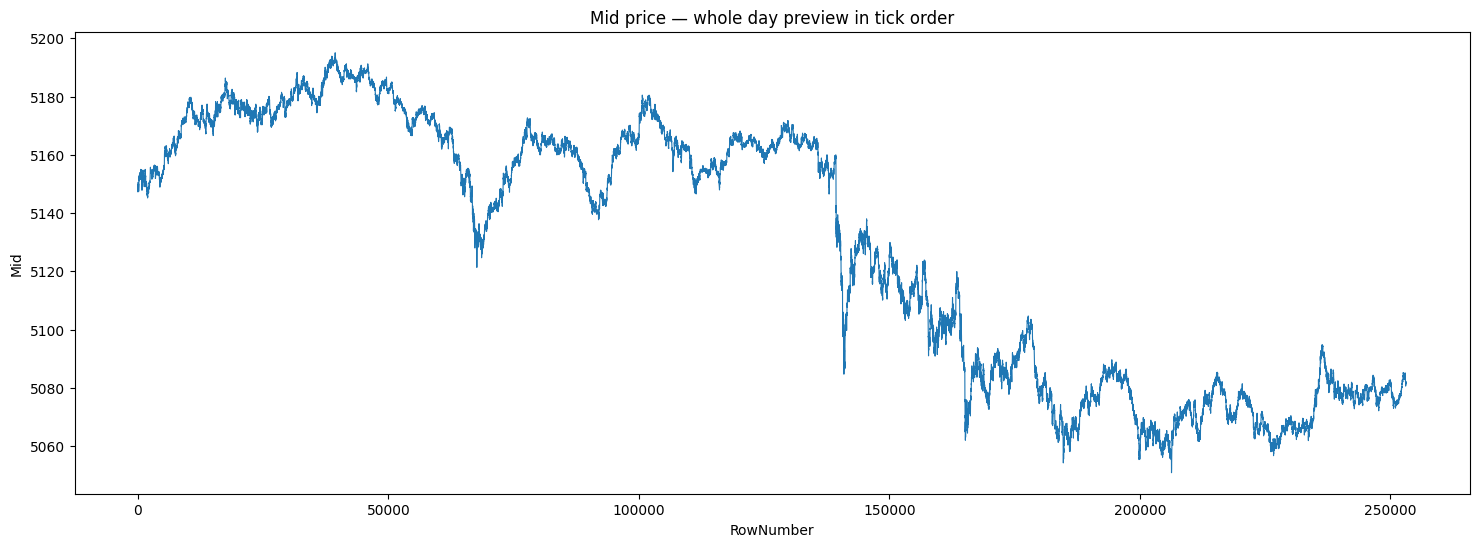

In [7]:
print("TickId increasing:", PaDf["TickId"].is_monotonic_increasing)
print("Time increasing:", PaDf["Time"].is_monotonic_increasing)

print("First Time:", PaDf["Time"].iloc[0])
print("Last Time:", PaDf["Time"].iloc[-1])
print("First TickId:", PaDf["TickId"].iloc[0])
print("Last TickId:", PaDf["TickId"].iloc[-1])

PlotStep = max(len(PaDf) // 50000, 1)
PlotDf = PaDf.iloc[::PlotStep].copy()

plt.figure(figsize=(18, 6))
plt.plot(PlotDf["RowNumber"], PlotDf["Mid"], linewidth=0.8)
plt.title("Mid price — whole day preview in tick order")
plt.xlabel("RowNumber")
plt.ylabel("Mid")
plt.show()

In [8]:
PivotScales = [3, 5, 8, 13, 21, 34, 55, 89, 144]

PaDf["HighStrength"] = 0
PaDf["LowStrength"] = 0

for Scale in PivotScales:
    WindowSize = 2 * Scale + 1

    RollingMax = PaDf["Mid"].rolling(
        WindowSize,
        center=True,
        min_periods=WindowSize
    ).max()

    RollingMin = PaDf["Mid"].rolling(
        WindowSize,
        center=True,
        min_periods=WindowSize
    ).min()

    HighCol = f"IsSwingHigh_{Scale}"
    LowCol = f"IsSwingLow_{Scale}"

    PaDf[HighCol] = (PaDf["Mid"] == RollingMax) & RollingMax.notna()
    PaDf[LowCol] = (PaDf["Mid"] == RollingMin) & RollingMin.notna()

    PaDf["HighStrength"] += PaDf[HighCol].astype(int) * Scale
    PaDf["LowStrength"] += PaDf[LowCol].astype(int) * Scale

PaDf["SwingStrength"] = PaDf[["HighStrength", "LowStrength"]].max(axis=1)

PaDf["SwingType"] = np.where(
    PaDf["HighStrength"] > PaDf["LowStrength"],
    "SwingHigh",
    np.where(
        PaDf["LowStrength"] > PaDf["HighStrength"],
        "SwingLow",
        "None"
    )
)

SwingDf = PaDf.loc[
    PaDf["SwingStrength"] > 0,
    ["TickId", "Time", "Mid", "HighStrength", "LowStrength", "SwingStrength", "SwingType"]
].copy()

print("Candidate swing rows:", len(SwingDf))
print("SwingHigh rows:", int((SwingDf["SwingType"] == "SwingHigh").sum()))
print("SwingLow rows:", int((SwingDf["SwingType"] == "SwingLow").sum()))

display(
    SwingDf.sort_values(
        ["SwingStrength", "TickId"],
        ascending=[False, True]
    ).head(30)
)

Candidate swing rows: 58556
SwingHigh rows: 29333
SwingLow rows: 29222


,TickId,Time,Mid,HighStrength,LowStrength,SwingStrength,SwingType
154,35884195,2026-03-05 10:01:52.804000+11:00,5147.22,0,372,372,SwingLow
335,35884376,2026-03-05 10:02:52.110000+11:00,5153.83,372,0,372,SwingHigh
425,35884466,2026-03-05 10:03:27.724000+11:00,5151.55,0,372,372,SwingLow
596,35884637,2026-03-05 10:04:45.969000+11:00,5155.13,372,0,372,SwingHigh
805,35884846,2026-03-05 10:06:05.817000+11:00,5147.82,0,372,372,SwingLow
1008,35885049,2026-03-05 10:07:09.621000+11:00,5154.91,372,0,372,SwingHigh
1255,35885296,2026-03-05 10:09:07.362000+11:00,5149.05,0,372,372,SwingLow
1257,35885298,2026-03-05 10:09:07.959000+11:00,5149.05,0,372,372,SwingLow
1448,35885489,2026-03-05 10:10:18.447000+11:00,5154.99,372,0,372,SwingHigh
1450,35885491,2026-03-05 10:10:21.117000+11:00,5154.99,372,0,372,SwingHigh


In [9]:
SwingDf = PaDf.loc[
    PaDf["SwingStrength"] > 0,
    ["RowNumber", "TickId", "Time", "Mid", "HighStrength", "LowStrength", "SwingStrength", "SwingType"]
].copy()

SwingDf["PrevSwingType"] = SwingDf["SwingType"].shift(1)
SwingDf["PrevMid"] = SwingDf["Mid"].shift(1)
SwingDf["PrevRowNumber"] = SwingDf["RowNumber"].shift(1)

SwingDf["IsNewCluster"] = (
    (SwingDf["SwingType"] != SwingDf["PrevSwingType"]) |
    (SwingDf["Mid"] != SwingDf["PrevMid"]) |
    ((SwingDf["RowNumber"] - SwingDf["PrevRowNumber"]) > 1)
)

SwingDf["ClusterId"] = SwingDf["IsNewCluster"].cumsum()

AnchorSwingDf = (
    SwingDf
    .sort_values(["ClusterId", "SwingStrength", "RowNumber"], ascending=[True, False, True])
    .groupby("ClusterId", as_index=False)
    .first()
    .copy()
)

print("Original swing rows:", len(SwingDf))
print("Anchor swing rows:", len(AnchorSwingDf))
print("Anchor SwingHigh rows:", int((AnchorSwingDf["SwingType"] == "SwingHigh").sum()))
print("Anchor SwingLow rows:", int((AnchorSwingDf["SwingType"] == "SwingLow").sum()))

display(
    AnchorSwingDf.sort_values(
        ["SwingStrength", "TickId"],
        ascending=[False, True]
    ).head(30)
)

Original swing rows: 58556
Anchor swing rows: 55182
Anchor SwingHigh rows: 27649
Anchor SwingLow rows: 27532


,ClusterId,RowNumber,TickId,Time,Mid,HighStrength,LowStrength,SwingStrength,SwingType,PrevSwingType,PrevMid,PrevRowNumber,IsNewCluster
38,39,154,35884195,2026-03-05 10:01:52.804000+11:00,5147.22,0,372,372,SwingLow,SwingHigh,5149.97,146.0,True
79,80,335,35884376,2026-03-05 10:02:52.110000+11:00,5153.83,372,0,372,SwingHigh,SwingLow,5153.57,334.0,True
100,101,425,35884466,2026-03-05 10:03:27.724000+11:00,5151.55,0,372,372,SwingLow,SwingHigh,5151.86,422.0,True
141,142,596,35884637,2026-03-05 10:04:45.969000+11:00,5155.13,372,0,372,SwingHigh,SwingLow,5154.35,591.0,True
184,185,805,35884846,2026-03-05 10:06:05.817000+11:00,5147.82,0,372,372,SwingLow,SwingLow,5148.97,800.0,True
234,235,1008,35885049,2026-03-05 10:07:09.621000+11:00,5154.91,372,0,372,SwingHigh,SwingLow,5154.50,1002.0,True
289,290,1255,35885296,2026-03-05 10:09:07.362000+11:00,5149.05,0,372,372,SwingLow,SwingHigh,5149.37,1251.0,True
290,291,1257,35885298,2026-03-05 10:09:07.959000+11:00,5149.05,0,372,372,SwingLow,SwingLow,5149.05,1255.0,True
327,328,1448,35885489,2026-03-05 10:10:18.447000+11:00,5154.99,372,0,372,SwingHigh,SwingLow,5154.33,1440.0,True
329,330,1450,35885491,2026-03-05 10:10:21.117000+11:00,5154.99,372,0,372,SwingHigh,SwingLow,5154.75,1449.0,True


In [10]:
SuppressionRadius = 144  # same as current largest pivot scale


def SelectDominantSwings(InputDf, SwingTypeValue, Radius):
    WorkDf = (
        InputDf.loc[InputDf["SwingType"] == SwingTypeValue].copy()
        .sort_values(["SwingStrength", "RowNumber"], ascending=[False, True])
        .reset_index(drop=True)
    )

    KeptRows = []
    KeptRowNumbers = []

    for _, Row in WorkDf.iterrows():
        CurrentRowNumber = int(Row["RowNumber"])

        TooClose = any(abs(CurrentRowNumber - KeptRowNumber) <= Radius for KeptRowNumber in KeptRowNumbers)

        if not TooClose:
            KeptRows.append(Row)
            KeptRowNumbers.append(CurrentRowNumber)

    if len(KeptRows) == 0:
        return WorkDf.iloc[0:0].copy()

    OutputDf = pd.DataFrame(KeptRows).sort_values("RowNumber").reset_index(drop=True)
    return OutputDf


DominantHighDf = SelectDominantSwings(AnchorSwingDf, "SwingHigh", SuppressionRadius)
DominantLowDf = SelectDominantSwings(AnchorSwingDf, "SwingLow", SuppressionRadius)

DominantSwingDf = (
    pd.concat([DominantHighDf, DominantLowDf], ignore_index=True)
    .sort_values("RowNumber")
    .reset_index(drop=True)
)

print("Suppression radius:", SuppressionRadius)
print("Anchor swing rows:", len(AnchorSwingDf))
print("Dominant swing rows:", len(DominantSwingDf))
print("Dominant SwingHigh rows:", int((DominantSwingDf["SwingType"] == "SwingHigh").sum()))
print("Dominant SwingLow rows:", int((DominantSwingDf["SwingType"] == "SwingLow").sum()))

display(
    DominantSwingDf[
        ["RowNumber", "TickId", "Time", "Mid", "SwingStrength", "SwingType"]
    ].head(40)
)

Suppression radius: 144
Anchor swing rows: 55182
Dominant swing rows: 2549
Dominant SwingHigh rows: 1263
Dominant SwingLow rows: 1286


,RowNumber,TickId,Time,Mid,SwingStrength,SwingType
0,5,35884046,2026-03-05 10:01:01.752000+11:00,5147.24,8,SwingLow
1,142,35884183,2026-03-05 10:01:49.166000+11:00,5150.24,139,SwingHigh
2,154,35884195,2026-03-05 10:01:52.804000+11:00,5147.22,372,SwingLow
3,335,35884376,2026-03-05 10:02:52.110000+11:00,5153.83,372,SwingHigh
4,425,35884466,2026-03-05 10:03:27.724000+11:00,5151.55,372,SwingLow
5,596,35884637,2026-03-05 10:04:45.969000+11:00,5155.13,372,SwingHigh
6,616,35884657,2026-03-05 10:04:54.596000+11:00,5152.74,139,SwingLow
7,805,35884846,2026-03-05 10:06:05.817000+11:00,5147.82,372,SwingLow
8,838,35884879,2026-03-05 10:06:15.065000+11:00,5152.55,228,SwingHigh
9,1008,35885049,2026-03-05 10:07:09.621000+11:00,5154.91,372,SwingHigh


In [11]:
AlternatingRows = []

for _, Row in DominantSwingDf.sort_values("RowNumber").iterrows():
    Current = Row.copy()

    if len(AlternatingRows) == 0:
        AlternatingRows.append(Current)
        continue

    Last = AlternatingRows[-1]

    if Current["SwingType"] != Last["SwingType"]:
        AlternatingRows.append(Current)
        continue

    # Same type as last kept pivot: keep the more extreme one
    if Current["SwingType"] == "SwingHigh":
        CurrentIsBetter = (
            (Current["Mid"] > Last["Mid"]) or
            (Current["Mid"] == Last["Mid"] and Current["SwingStrength"] > Last["SwingStrength"])
        )
    else:  # SwingLow
        CurrentIsBetter = (
            (Current["Mid"] < Last["Mid"]) or
            (Current["Mid"] == Last["Mid"] and Current["SwingStrength"] > Last["SwingStrength"])
        )

    if CurrentIsBetter:
        AlternatingRows[-1] = Current

AlternatingPivotDf = pd.DataFrame(AlternatingRows).reset_index(drop=True)

AlternatingPivotDf["PrevSwingType"] = AlternatingPivotDf["SwingType"].shift(1)
AlternatingPivotDf["AlternatesCorrectly"] = (
    AlternatingPivotDf["SwingType"] != AlternatingPivotDf["PrevSwingType"]
)

print("Dominant swing rows:", len(DominantSwingDf))
print("Alternating pivot rows:", len(AlternatingPivotDf))
print("Alternating SwingHigh rows:", int((AlternatingPivotDf["SwingType"] == "SwingHigh").sum()))
print("Alternating SwingLow rows:", int((AlternatingPivotDf["SwingType"] == "SwingLow").sum()))
print("All alternating after first row:", bool(AlternatingPivotDf["AlternatesCorrectly"].iloc[1:].all()))

display(
    AlternatingPivotDf[
        ["RowNumber", "TickId", "Time", "Mid", "SwingStrength", "SwingType"]
    ].head(40)
)

Dominant swing rows: 2549
Alternating pivot rows: 2304
Alternating SwingHigh rows: 1152
Alternating SwingLow rows: 1152
All alternating after first row: True


,RowNumber,TickId,Time,Mid,SwingStrength,SwingType
0,5,35884046,2026-03-05 10:01:01.752000+11:00,5147.24,8,SwingLow
1,142,35884183,2026-03-05 10:01:49.166000+11:00,5150.24,139,SwingHigh
2,154,35884195,2026-03-05 10:01:52.804000+11:00,5147.22,372,SwingLow
3,335,35884376,2026-03-05 10:02:52.110000+11:00,5153.83,372,SwingHigh
4,425,35884466,2026-03-05 10:03:27.724000+11:00,5151.55,372,SwingLow
5,596,35884637,2026-03-05 10:04:45.969000+11:00,5155.13,372,SwingHigh
6,805,35884846,2026-03-05 10:06:05.817000+11:00,5147.82,372,SwingLow
7,1008,35885049,2026-03-05 10:07:09.621000+11:00,5154.91,372,SwingHigh
8,1045,35885086,2026-03-05 10:07:24.437000+11:00,5151.67,84,SwingLow
9,1193,35885234,2026-03-05 10:08:42.150000+11:00,5152.22,139,SwingHigh


,SwingStrength,Count,Percent
0,3,19,0.824653
1,8,28,1.215278
2,16,35,1.519097
3,29,56,2.430556
4,50,114,4.947917
5,84,185,8.029514
6,139,298,12.934028
7,228,398,17.274306
8,372,1171,50.824653


Total alternating pivots: 2304

Top strengths by count:


,SwingStrength,Count,Percent
8,372,1171,50.824653
7,228,398,17.274306
6,139,298,12.934028
5,84,185,8.029514
4,50,114,4.947917
3,29,56,2.430556
2,16,35,1.519097
1,8,28,1.215278
0,3,19,0.824653


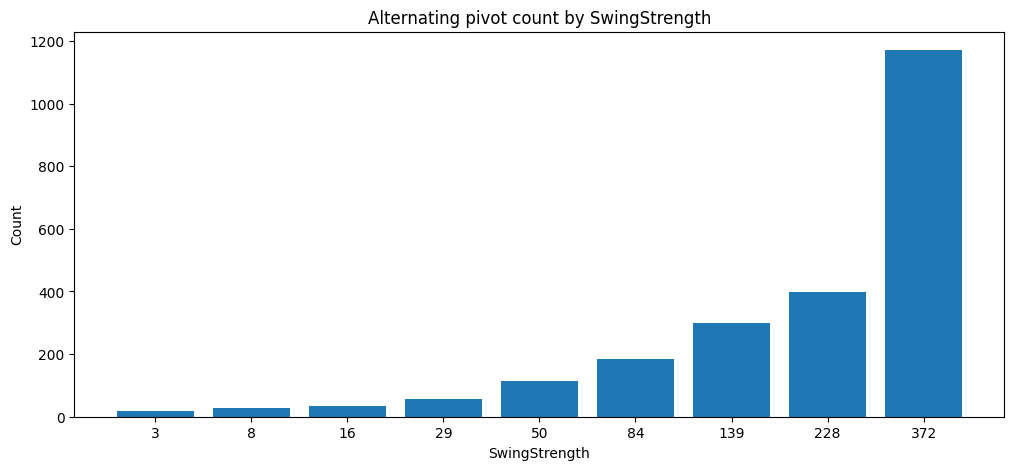

In [12]:
StrengthSummaryDf = (
    AlternatingPivotDf["SwingStrength"]
    .value_counts()
    .sort_index()
    .rename_axis("SwingStrength")
    .reset_index(name="Count")
)

StrengthSummaryDf["Percent"] = StrengthSummaryDf["Count"] / len(AlternatingPivotDf) * 100.0

display(StrengthSummaryDf)

print("Total alternating pivots:", len(AlternatingPivotDf))
print()
print("Top strengths by count:")
display(StrengthSummaryDf.sort_values("Count", ascending=False).head(10))

plt.figure(figsize=(12, 5))
plt.bar(StrengthSummaryDf["SwingStrength"].astype(str), StrengthSummaryDf["Count"])
plt.title("Alternating pivot count by SwingStrength")
plt.xlabel("SwingStrength")
plt.ylabel("Count")
plt.show()

In [13]:
MajorPivotThreshold = 228
UltraMajorThreshold = 372
SecondaryPivotThreshold = 139

AlternatingPivotDf["PivotTier"] = np.select(
    [
        AlternatingPivotDf["SwingStrength"] >= UltraMajorThreshold,
        AlternatingPivotDf["SwingStrength"] >= MajorPivotThreshold,
        AlternatingPivotDf["SwingStrength"] >= SecondaryPivotThreshold,
    ],
    [
        "UltraMajor",
        "Major",
        "Secondary",
    ],
    default="Minor"
)

TierSummaryDf = (
    AlternatingPivotDf["PivotTier"]
    .value_counts()
    .rename_axis("PivotTier")
    .reset_index(name="Count")
)

TierSummaryDf["Percent"] = TierSummaryDf["Count"] / len(AlternatingPivotDf) * 100.0

MajorPivotDf = AlternatingPivotDf.loc[
    AlternatingPivotDf["SwingStrength"] >= MajorPivotThreshold
].copy()

UltraMajorPivotDf = AlternatingPivotDf.loc[
    AlternatingPivotDf["SwingStrength"] >= UltraMajorThreshold
].copy()

print("MajorPivotThreshold:", MajorPivotThreshold)
print("UltraMajorThreshold:", UltraMajorThreshold)
print()

display(TierSummaryDf)

print("Major pivots:", len(MajorPivotDf))
print("Major SwingHigh:", int((MajorPivotDf["SwingType"] == "SwingHigh").sum()))
print("Major SwingLow:", int((MajorPivotDf["SwingType"] == "SwingLow").sum()))
print()

print("UltraMajor pivots:", len(UltraMajorPivotDf))
print("UltraMajor SwingHigh:", int((UltraMajorPivotDf["SwingType"] == "SwingHigh").sum()))
print("UltraMajor SwingLow:", int((UltraMajorPivotDf["SwingType"] == "SwingLow").sum()))

display(
    MajorPivotDf[
        ["RowNumber", "TickId", "Time", "Mid", "SwingStrength", "SwingType", "PivotTier"]
    ].head(40)
)

MajorPivotThreshold: 228
UltraMajorThreshold: 372



,PivotTier,Count,Percent
0,UltraMajor,1171,50.824653
1,Minor,437,18.967014
2,Major,398,17.274306
3,Secondary,298,12.934028


Major pivots: 1569
Major SwingHigh: 800
Major SwingLow: 769

UltraMajor pivots: 1171
UltraMajor SwingHigh: 590
UltraMajor SwingLow: 581


,RowNumber,TickId,Time,Mid,SwingStrength,SwingType,PivotTier
2,154,35884195,2026-03-05 10:01:52.804000+11:00,5147.22,372,SwingLow,UltraMajor
3,335,35884376,2026-03-05 10:02:52.110000+11:00,5153.83,372,SwingHigh,UltraMajor
4,425,35884466,2026-03-05 10:03:27.724000+11:00,5151.55,372,SwingLow,UltraMajor
5,596,35884637,2026-03-05 10:04:45.969000+11:00,5155.13,372,SwingHigh,UltraMajor
6,805,35884846,2026-03-05 10:06:05.817000+11:00,5147.82,372,SwingLow,UltraMajor
7,1008,35885049,2026-03-05 10:07:09.621000+11:00,5154.91,372,SwingHigh,UltraMajor
10,1255,35885296,2026-03-05 10:09:07.362000+11:00,5149.05,372,SwingLow,UltraMajor
11,1448,35885489,2026-03-05 10:10:18.447000+11:00,5154.99,372,SwingHigh,UltraMajor
13,1724,35885765,2026-03-05 10:12:44.727000+11:00,5150.28,228,SwingHigh,Major
14,1932,35885973,2026-03-05 10:14:41.199000+11:00,5144.90,372,SwingLow,UltraMajor


In [14]:
MacroScales = [233, 377, 610, 987, 1597, 2584]

PaDf["MacroHighStrength"] = 0
PaDf["MacroLowStrength"] = 0

for Scale in MacroScales:
    WindowSize = 2 * Scale + 1

    RollingMax = PaDf["Mid"].rolling(
        WindowSize,
        center=True,
        min_periods=WindowSize
    ).max()

    RollingMin = PaDf["Mid"].rolling(
        WindowSize,
        center=True,
        min_periods=WindowSize
    ).min()

    PaDf["MacroHighStrength"] += ((PaDf["Mid"] == RollingMax) & RollingMax.notna()).astype(int) * Scale
    PaDf["MacroLowStrength"] += ((PaDf["Mid"] == RollingMin) & RollingMin.notna()).astype(int) * Scale

PaDf["MacroSwingStrength"] = PaDf[["MacroHighStrength", "MacroLowStrength"]].max(axis=1)

PaDf["MacroSwingType"] = np.where(
    PaDf["MacroHighStrength"] > PaDf["MacroLowStrength"],
    "SwingHigh",
    np.where(
        PaDf["MacroLowStrength"] > PaDf["MacroHighStrength"],
        "SwingLow",
        "None"
    )
)

MacroSwingDf = PaDf.loc[
    PaDf["MacroSwingStrength"] > 0,
    ["RowNumber", "TickId", "Time", "Mid", "MacroHighStrength", "MacroLowStrength", "MacroSwingStrength", "MacroSwingType"]
].copy()

MacroStrengthSummaryDf = (
    MacroSwingDf["MacroSwingStrength"]
    .value_counts()
    .sort_index()
    .rename_axis("MacroSwingStrength")
    .reset_index(name="Count")
)

MacroStrengthSummaryDf["Percent"] = MacroStrengthSummaryDf["Count"] / len(MacroSwingDf) * 100.0

print("MacroScales:", MacroScales)
print("Macro swing rows:", len(MacroSwingDf))
print("Macro SwingHigh rows:", int((MacroSwingDf["MacroSwingType"] == "SwingHigh").sum()))
print("Macro SwingLow rows:", int((MacroSwingDf["MacroSwingType"] == "SwingLow").sum()))

display(MacroStrengthSummaryDf)

display(
    MacroSwingDf.sort_values(
        ["MacroSwingStrength", "TickId"],
        ascending=[False, True]
    ).head(30)
)

MacroScales: [233, 377, 610, 987, 1597, 2584]
Macro swing rows: 828
Macro SwingHigh rows: 404
Macro SwingLow rows: 424


,MacroSwingStrength,Count,Percent
0,233,337,40.700483
1,610,192,23.188406
2,1220,112,13.526570
3,2207,67,8.091787
4,3804,48,5.797101
5,6388,72,8.695652


,RowNumber,TickId,Time,Mid,MacroHighStrength,MacroLowStrength,MacroSwingStrength,MacroSwingType
10311,10311,35894352,2026-03-05 11:22:15.678000+11:00,5179.93,6388,0,6388,SwingHigh
13531,13531,35897572,2026-03-05 11:48:20.150000+11:00,5166.22,0,6388,6388,SwingLow
17451,17451,35901492,2026-03-05 12:10:36.802000+11:00,5186.45,6388,0,6388,SwingHigh
23856,23856,35907897,2026-03-05 12:42:13.087000+11:00,5167.36,0,6388,6388,SwingLow
26616,26616,35910657,2026-03-05 12:55:45.001000+11:00,5169.48,0,6388,6388,SwingLow
26618,26618,35910659,2026-03-05 12:55:45.460000+11:00,5169.48,0,6388,6388,SwingLow
31770,31770,35915811,2026-03-05 13:23:31.274000+11:00,5188.27,6388,0,6388,SwingHigh
35726,35726,35919767,2026-03-05 13:45:13.366000+11:00,5174.40,0,6388,6388,SwingLow
35731,35731,35919772,2026-03-05 13:45:14.570000+11:00,5174.40,0,6388,6388,SwingLow
39372,39372,35923413,2026-03-05 14:05:34.258000+11:00,5195.11,6388,0,6388,SwingHigh


In [15]:
MacroSwingDf = PaDf.loc[
    PaDf["MacroSwingStrength"] > 0,
    ["RowNumber", "TickId", "Time", "Mid", "MacroHighStrength", "MacroLowStrength", "MacroSwingStrength", "MacroSwingType"]
].copy()

MacroSwingDf["PrevType"] = MacroSwingDf["MacroSwingType"].shift(1)
MacroSwingDf["PrevMid"] = MacroSwingDf["Mid"].shift(1)
MacroSwingDf["PrevRowNumber"] = MacroSwingDf["RowNumber"].shift(1)

MacroSwingDf["IsNewCluster"] = (
    (MacroSwingDf["MacroSwingType"] != MacroSwingDf["PrevType"]) |
    (MacroSwingDf["Mid"] != MacroSwingDf["PrevMid"]) |
    ((MacroSwingDf["RowNumber"] - MacroSwingDf["PrevRowNumber"]) > 1)
)

MacroSwingDf["MacroClusterId"] = MacroSwingDf["IsNewCluster"].cumsum()

MacroAnchorDf = (
    MacroSwingDf
    .sort_values(
        ["MacroClusterId", "MacroSwingStrength", "RowNumber"],
        ascending=[True, False, True]
    )
    .groupby("MacroClusterId", as_index=False)
    .first()
    .copy()
)

print("Original macro swing rows:", len(MacroSwingDf))
print("Macro anchor rows:", len(MacroAnchorDf))
print("Macro anchor SwingHigh rows:", int((MacroAnchorDf["MacroSwingType"] == "SwingHigh").sum()))
print("Macro anchor SwingLow rows:", int((MacroAnchorDf["MacroSwingType"] == "SwingLow").sum()))

display(
    MacroAnchorDf.sort_values(
        ["MacroSwingStrength", "TickId"],
        ascending=[False, True]
    ).head(40)
)

Original macro swing rows: 828
Macro anchor rows: 799
Macro anchor SwingHigh rows: 384
Macro anchor SwingLow rows: 415


,MacroClusterId,RowNumber,TickId,Time,Mid,MacroHighStrength,MacroLowStrength,MacroSwingStrength,MacroSwingType,PrevType,PrevMid,PrevRowNumber,IsNewCluster
34,35,10311,35894352,2026-03-05 11:22:15.678000+11:00,5179.93,6388,0,6388,SwingHigh,SwingLow,5176.17,10205.0,True
44,45,13531,35897572,2026-03-05 11:48:20.150000+11:00,5166.22,0,6388,6388,SwingLow,SwingHigh,5177.05,12790.0,True
56,57,17451,35901492,2026-03-05 12:10:36.802000+11:00,5186.45,6388,0,6388,SwingHigh,SwingLow,5173.97,16326.0,True
81,82,23856,35907897,2026-03-05 12:42:13.087000+11:00,5167.36,0,6388,6388,SwingLow,SwingHigh,5177.40,23526.0,True
88,89,26616,35910657,2026-03-05 12:55:45.001000+11:00,5169.48,0,6388,6388,SwingLow,SwingHigh,5180.07,26160.0,True
89,90,26618,35910659,2026-03-05 12:55:45.460000+11:00,5169.48,0,6388,6388,SwingLow,SwingLow,5169.48,26616.0,True
104,105,31770,35915811,2026-03-05 13:23:31.274000+11:00,5188.27,6388,0,6388,SwingHigh,SwingLow,5178.42,30866.0,True
119,120,35726,35919767,2026-03-05 13:45:13.366000+11:00,5174.40,0,6388,6388,SwingLow,SwingHigh,5182.91,34961.0,True
120,121,35731,35919772,2026-03-05 13:45:14.570000+11:00,5174.40,0,6388,6388,SwingLow,SwingLow,5174.40,35726.0,True
132,133,39372,35923413,2026-03-05 14:05:34.258000+11:00,5195.11,6388,0,6388,SwingHigh,SwingLow,5190.45,38969.0,True


In [16]:
MacroPlateauGap = 8

MacroSwingDf2 = PaDf.loc[
    PaDf["MacroSwingStrength"] > 0,
    ["RowNumber", "TickId", "Time", "Mid", "MacroHighStrength", "MacroLowStrength", "MacroSwingStrength", "MacroSwingType"]
].copy()

MacroSwingDf2 = MacroSwingDf2.sort_values("RowNumber").reset_index(drop=True)

MacroSwingDf2["PrevType"] = MacroSwingDf2["MacroSwingType"].shift(1)
MacroSwingDf2["PrevMid"] = MacroSwingDf2["Mid"].shift(1)
MacroSwingDf2["PrevRowNumber"] = MacroSwingDf2["RowNumber"].shift(1)

MacroSwingDf2["IsNewCluster"] = (
    (MacroSwingDf2["MacroSwingType"] != MacroSwingDf2["PrevType"]) |
    (MacroSwingDf2["Mid"] != MacroSwingDf2["PrevMid"]) |
    ((MacroSwingDf2["RowNumber"] - MacroSwingDf2["PrevRowNumber"]) > MacroPlateauGap)
)

MacroSwingDf2["MacroClusterId"] = MacroSwingDf2["IsNewCluster"].cumsum()

MacroPlateauAnchorDf = (
    MacroSwingDf2
    .sort_values(
        ["MacroClusterId", "MacroSwingStrength", "RowNumber"],
        ascending=[True, False, True]
    )
    .groupby("MacroClusterId", as_index=False)
    .first()
    .copy()
)

print("MacroPlateauGap:", MacroPlateauGap)
print("Original macro swing rows:", len(MacroSwingDf2))
print("Macro plateau anchor rows:", len(MacroPlateauAnchorDf))
print("Macro plateau SwingHigh rows:", int((MacroPlateauAnchorDf["MacroSwingType"] == "SwingHigh").sum()))
print("Macro plateau SwingLow rows:", int((MacroPlateauAnchorDf["MacroSwingType"] == "SwingLow").sum()))

display(
    MacroPlateauAnchorDf.sort_values(
        ["MacroSwingStrength", "TickId"],
        ascending=[False, True]
    ).head(40)
)

MacroPlateauGap: 8
Original macro swing rows: 828
Macro plateau anchor rows: 734
Macro plateau SwingHigh rows: 358
Macro plateau SwingLow rows: 376


,MacroClusterId,RowNumber,TickId,Time,Mid,MacroHighStrength,MacroLowStrength,MacroSwingStrength,MacroSwingType,PrevType,PrevMid,PrevRowNumber,IsNewCluster
26,27,10311,35894352,2026-03-05 11:22:15.678000+11:00,5179.93,6388,0,6388,SwingHigh,SwingLow,5176.17,10205.0,True
33,34,13531,35897572,2026-03-05 11:48:20.150000+11:00,5166.22,0,6388,6388,SwingLow,SwingHigh,5177.05,12790.0,True
45,46,17451,35901492,2026-03-05 12:10:36.802000+11:00,5186.45,6388,0,6388,SwingHigh,SwingLow,5173.97,16326.0,True
69,70,23856,35907897,2026-03-05 12:42:13.087000+11:00,5167.36,0,6388,6388,SwingLow,SwingHigh,5177.40,23526.0,True
76,77,26616,35910657,2026-03-05 12:55:45.001000+11:00,5169.48,0,6388,6388,SwingLow,SwingHigh,5180.07,26160.0,True
91,92,31770,35915811,2026-03-05 13:23:31.274000+11:00,5188.27,6388,0,6388,SwingHigh,SwingLow,5178.42,30866.0,True
104,105,35726,35919767,2026-03-05 13:45:13.366000+11:00,5174.40,0,6388,6388,SwingLow,SwingHigh,5182.91,34961.0,True
116,117,39372,35923413,2026-03-05 14:05:34.258000+11:00,5195.11,6388,0,6388,SwingHigh,SwingLow,5190.45,38969.0,True
117,118,40796,35924837,2026-03-05 14:13:46.470000+11:00,5183.97,0,6388,6388,SwingLow,SwingHigh,5195.11,39372.0,True
124,125,43598,35927639,2026-03-05 14:30:18.875000+11:00,5181.23,0,6388,6388,SwingLow,SwingHigh,5187.62,42933.0,True


In [17]:
MacroAlternatingRows = []

for _, Row in MacroPlateauAnchorDf.sort_values("RowNumber").iterrows():
    Current = Row.copy()

    if len(MacroAlternatingRows) == 0:
        MacroAlternatingRows.append(Current)
        continue

    Last = MacroAlternatingRows[-1]

    if Current["MacroSwingType"] != Last["MacroSwingType"]:
        MacroAlternatingRows.append(Current)
        continue

    # Same type as last kept macro pivot: keep the more extreme one
    if Current["MacroSwingType"] == "SwingHigh":
        CurrentIsBetter = (
            (Current["Mid"] > Last["Mid"]) or
            (Current["Mid"] == Last["Mid"] and Current["MacroSwingStrength"] > Last["MacroSwingStrength"])
        )
    else:  # SwingLow
        CurrentIsBetter = (
            (Current["Mid"] < Last["Mid"]) or
            (Current["Mid"] == Last["Mid"] and Current["MacroSwingStrength"] > Last["MacroSwingStrength"])
        )

    if CurrentIsBetter:
        MacroAlternatingRows[-1] = Current

MacroAlternatingPivotDf = pd.DataFrame(MacroAlternatingRows).reset_index(drop=True)

MacroAlternatingPivotDf["PrevMacroSwingType"] = MacroAlternatingPivotDf["MacroSwingType"].shift(1)
MacroAlternatingPivotDf["AlternatesCorrectly"] = (
    MacroAlternatingPivotDf["MacroSwingType"] != MacroAlternatingPivotDf["PrevMacroSwingType"]
)

print("Macro plateau anchor rows:", len(MacroPlateauAnchorDf))
print("Macro alternating pivot rows:", len(MacroAlternatingPivotDf))
print("Macro alternating SwingHigh rows:", int((MacroAlternatingPivotDf["MacroSwingType"] == "SwingHigh").sum()))
print("Macro alternating SwingLow rows:", int((MacroAlternatingPivotDf["MacroSwingType"] == "SwingLow").sum()))
print("All alternating after first row:", bool(MacroAlternatingPivotDf["AlternatesCorrectly"].iloc[1:].all()))

display(
    MacroAlternatingPivotDf[
        ["RowNumber", "TickId", "Time", "Mid", "MacroSwingStrength", "MacroSwingType"]
    ].head(40)
)

Macro plateau anchor rows: 734
Macro alternating pivot rows: 615
Macro alternating SwingHigh rows: 308
Macro alternating SwingLow rows: 307
All alternating after first row: True


,RowNumber,TickId,Time,Mid,MacroSwingStrength,MacroSwingType
0,596,35884637,2026-03-05 10:04:45.969000+11:00,5155.13,610,SwingHigh
1,805,35884846,2026-03-05 10:06:05.817000+11:00,5147.82,1220,SwingLow
2,1008,35885049,2026-03-05 10:07:09.621000+11:00,5154.91,610,SwingHigh
3,1255,35885296,2026-03-05 10:09:07.362000+11:00,5149.05,610,SwingLow
4,1448,35885489,2026-03-05 10:10:18.447000+11:00,5154.99,1220,SwingHigh
5,1932,35885973,2026-03-05 10:14:41.199000+11:00,5144.90,3804,SwingLow
6,2492,35886533,2026-03-05 10:19:09.752000+11:00,5155.74,1220,SwingHigh
7,2779,35886820,2026-03-05 10:21:45.404000+11:00,5151.64,233,SwingLow
8,3305,35887346,2026-03-05 10:26:22.499000+11:00,5156.50,3804,SwingHigh
9,3491,35887532,2026-03-05 10:27:59.827000+11:00,5151.77,1220,SwingLow


In [18]:
TopMacroThreshold = 3804

TopMacroPivotDf = MacroAlternatingPivotDf.loc[
    MacroAlternatingPivotDf["MacroSwingStrength"] >= TopMacroThreshold
].copy()

print("TopMacroThreshold:", TopMacroThreshold)
print("Top macro pivots:", len(TopMacroPivotDf))
print("Top macro SwingHigh:", int((TopMacroPivotDf["MacroSwingType"] == "SwingHigh").sum()))
print("Top macro SwingLow:", int((TopMacroPivotDf["MacroSwingType"] == "SwingLow").sum()))

display(
    TopMacroPivotDf[
        ["RowNumber", "TickId", "Time", "Mid", "MacroSwingStrength", "MacroSwingType"]
    ].head(60)
)

TopMacroThreshold: 3804
Top macro pivots: 106
Top macro SwingHigh: 53
Top macro SwingLow: 53


,RowNumber,TickId,Time,Mid,MacroSwingStrength,MacroSwingType
5,1932,35885973,2026-03-05 10:14:41.199000+11:00,5144.90,3804,SwingLow
8,3305,35887346,2026-03-05 10:26:22.499000+11:00,5156.50,3804,SwingHigh
11,4381,35888422,2026-03-05 10:36:39.719000+11:00,5148.83,3804,SwingLow
24,10311,35894352,2026-03-05 11:22:15.678000+11:00,5179.93,6388,SwingHigh
29,13531,35897572,2026-03-05 11:48:20.150000+11:00,5166.22,6388,SwingLow
30,13797,35897838,2026-03-05 11:50:01.541000+11:00,5177.50,3804,SwingHigh
40,17451,35901492,2026-03-05 12:10:36.802000+11:00,5186.45,6388,SwingHigh
49,20478,35904519,2026-03-05 12:25:50.967000+11:00,5172.62,3804,SwingLow
54,21678,35905719,2026-03-05 12:31:50.462000+11:00,5178.99,3804,SwingHigh
60,23526,35907567,2026-03-05 12:40:42.425000+11:00,5177.40,3804,SwingHigh


In [19]:
UltraMacroThreshold = 6388

UltraMacroPivotDf = MacroAlternatingPivotDf.loc[
    MacroAlternatingPivotDf["MacroSwingStrength"] >= UltraMacroThreshold
].copy()

print("UltraMacroThreshold:", UltraMacroThreshold)
print("Ultra macro pivots:", len(UltraMacroPivotDf))
print("Ultra macro SwingHigh:", int((UltraMacroPivotDf["MacroSwingType"] == "SwingHigh").sum()))
print("Ultra macro SwingLow:", int((UltraMacroPivotDf["MacroSwingType"] == "SwingLow").sum()))

display(
    UltraMacroPivotDf[
        ["RowNumber", "TickId", "Time", "Mid", "MacroSwingStrength", "MacroSwingType"]
    ].head(80)
)

UltraMacroThreshold: 6388
Ultra macro pivots: 61
Ultra macro SwingHigh: 27
Ultra macro SwingLow: 34


,RowNumber,TickId,Time,Mid,MacroSwingStrength,MacroSwingType
24,10311,35894352,2026-03-05 11:22:15.678000+11:00,5179.93,6388,SwingHigh
29,13531,35897572,2026-03-05 11:48:20.150000+11:00,5166.22,6388,SwingLow
40,17451,35901492,2026-03-05 12:10:36.802000+11:00,5186.45,6388,SwingHigh
61,23856,35907897,2026-03-05 12:42:13.087000+11:00,5167.36,6388,SwingLow
67,26616,35910657,2026-03-05 12:55:45.001000+11:00,5169.48,6388,SwingLow
80,31770,35915811,2026-03-05 13:23:31.274000+11:00,5188.27,6388,SwingHigh
91,35726,35919767,2026-03-05 13:45:13.366000+11:00,5174.40,6388,SwingLow
102,39372,35923413,2026-03-05 14:05:34.258000+11:00,5195.11,6388,SwingHigh
103,40796,35924837,2026-03-05 14:13:46.470000+11:00,5183.97,6388,SwingLow
107,43598,35927639,2026-03-05 14:30:18.875000+11:00,5181.23,6388,SwingLow


In [21]:
UltraAlternatingRows = []

for _, Row in UltraMacroPivotDf.sort_values("RowNumber").iterrows():
    Current = Row.copy()

    if len(UltraAlternatingRows) == 0:
        UltraAlternatingRows.append(Current)
        continue

    Last = UltraAlternatingRows[-1]

    if Current["MacroSwingType"] != Last["MacroSwingType"]:
        UltraAlternatingRows.append(Current)
        continue

    # Same type again after filtering: keep the more extreme one
    if Current["MacroSwingType"] == "SwingHigh":
        CurrentIsBetter = Current["Mid"] > Last["Mid"]
    else:  # SwingLow
        CurrentIsBetter = Current["Mid"] < Last["Mid"]

    if CurrentIsBetter:
        UltraAlternatingRows[-1] = Current

UltraAlternatingPivotDf = pd.DataFrame(UltraAlternatingRows).reset_index(drop=True)

UltraAlternatingPivotDf["PrevType"] = UltraAlternatingPivotDf["MacroSwingType"].shift(1)
UltraAlternatingPivotDf["AlternatesCorrectly"] = (
    UltraAlternatingPivotDf["MacroSwingType"] != UltraAlternatingPivotDf["PrevType"]
)

print("Ultra macro pivots:", len(UltraMacroPivotDf))
print("Ultra alternating pivots:", len(UltraAlternatingPivotDf))
print("Ultra alternating SwingHigh:", int((UltraAlternatingPivotDf["MacroSwingType"] == "SwingHigh").sum()))
print("Ultra alternating SwingLow:", int((UltraAlternatingPivotDf["MacroSwingType"] == "SwingLow").sum()))
print("All alternating after first row:", bool(UltraAlternatingPivotDf["AlternatesCorrectly"].iloc[1:].all()))

display(
    UltraAlternatingPivotDf[
        ["RowNumber", "TickId", "Time", "Mid", "MacroSwingStrength", "MacroSwingType"]
    ].head(80)
)

Ultra macro pivots: 61
Ultra alternating pivots: 52
Ultra alternating SwingHigh: 26
Ultra alternating SwingLow: 26
All alternating after first row: True


,RowNumber,TickId,Time,Mid,MacroSwingStrength,MacroSwingType
0,10311,35894352,2026-03-05 11:22:15.678000+11:00,5179.93,6388,SwingHigh
1,13531,35897572,2026-03-05 11:48:20.150000+11:00,5166.22,6388,SwingLow
2,17451,35901492,2026-03-05 12:10:36.802000+11:00,5186.45,6388,SwingHigh
3,23856,35907897,2026-03-05 12:42:13.087000+11:00,5167.36,6388,SwingLow
4,31770,35915811,2026-03-05 13:23:31.274000+11:00,5188.27,6388,SwingHigh
5,35726,35919767,2026-03-05 13:45:13.366000+11:00,5174.40,6388,SwingLow
6,39372,35923413,2026-03-05 14:05:34.258000+11:00,5195.11,6388,SwingHigh
7,43598,35927639,2026-03-05 14:30:18.875000+11:00,5181.23,6388,SwingLow
8,45881,35929922,2026-03-05 14:46:10.461000+11:00,5191.27,6388,SwingHigh
9,47874,35931915,2026-03-05 15:00:55.454000+11:00,5177.09,6388,SwingLow


Ultra alternating pivots: 52
Structural legs: 51


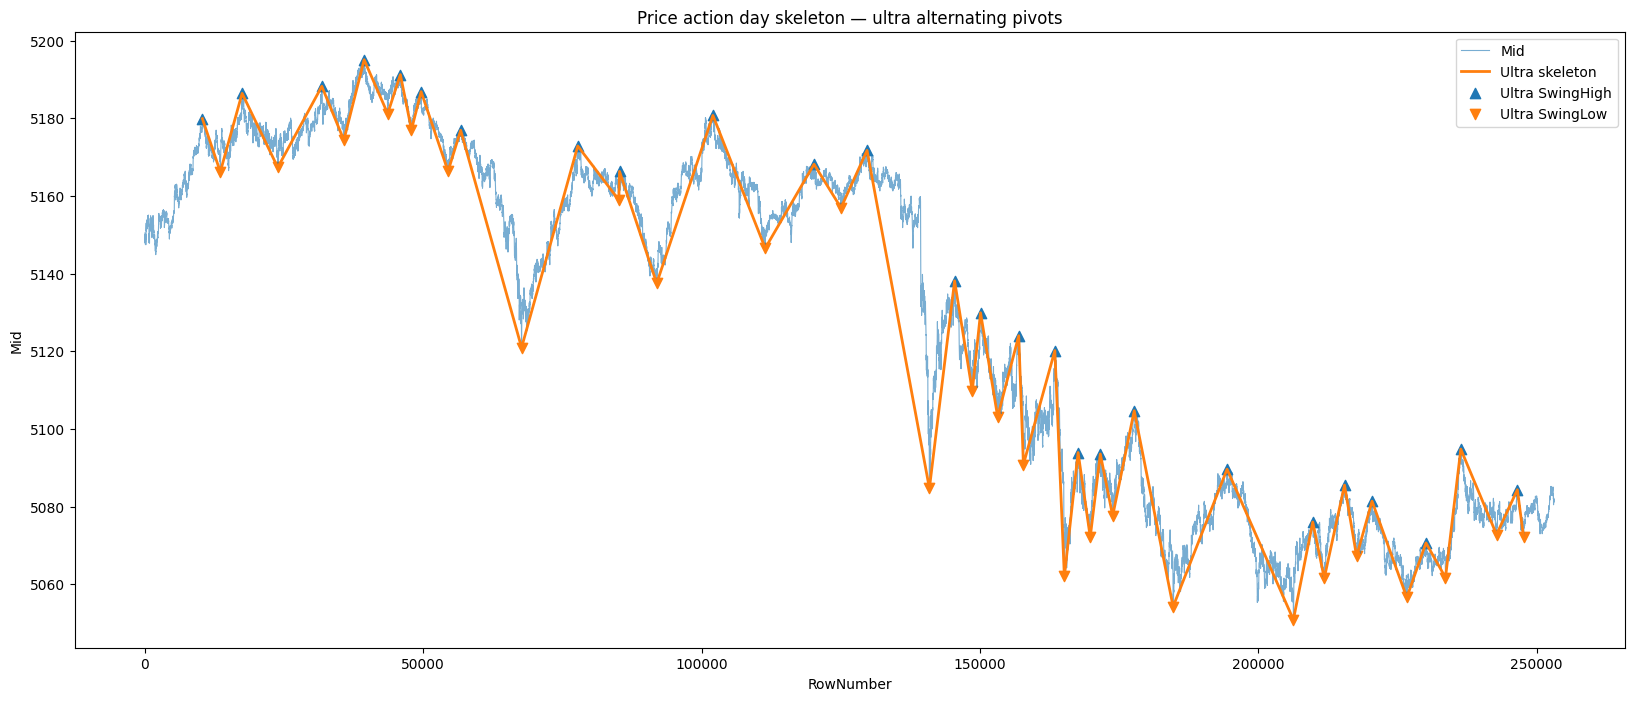

In [22]:
PlotStep = max(len(PaDf) // 40000, 1)
PlotDf = PaDf.iloc[::PlotStep].copy()

HighMask = UltraAlternatingPivotDf["MacroSwingType"] == "SwingHigh"
LowMask = UltraAlternatingPivotDf["MacroSwingType"] == "SwingLow"

print("Ultra alternating pivots:", len(UltraAlternatingPivotDf))
print("Structural legs:", max(len(UltraAlternatingPivotDf) - 1, 0))

plt.figure(figsize=(20, 8))

# Background price path
plt.plot(
    PlotDf["RowNumber"],
    PlotDf["Mid"],
    linewidth=0.8,
    alpha=0.6,
    label="Mid"
)

# Skeleton line connecting major pivots
plt.plot(
    UltraAlternatingPivotDf["RowNumber"],
    UltraAlternatingPivotDf["Mid"],
    linewidth=2.0,
    label="Ultra skeleton"
)

# High / low markers
plt.scatter(
    UltraAlternatingPivotDf.loc[HighMask, "RowNumber"],
    UltraAlternatingPivotDf.loc[HighMask, "Mid"],
    s=55,
    marker="^",
    label="Ultra SwingHigh"
)

plt.scatter(
    UltraAlternatingPivotDf.loc[LowMask, "RowNumber"],
    UltraAlternatingPivotDf.loc[LowMask, "Mid"],
    s=55,
    marker="v",
    label="Ultra SwingLow"
)

plt.title("Price action day skeleton — ultra alternating pivots")
plt.xlabel("RowNumber")
plt.ylabel("Mid")
plt.legend()
plt.show()

In [23]:
LegRows = []

for Index in range(len(UltraAlternatingPivotDf) - 1):
    StartRow = UltraAlternatingPivotDf.iloc[Index]
    EndRow = UltraAlternatingPivotDf.iloc[Index + 1]

    StartMid = float(StartRow["Mid"])
    EndMid = float(EndRow["Mid"])
    PriceMove = EndMid - StartMid

    TickLength = int(EndRow["RowNumber"] - StartRow["RowNumber"])
    TimeLengthSec = (
        (EndRow["Time"] - StartRow["Time"]).total_seconds()
        if pd.notna(StartRow["Time"]) and pd.notna(EndRow["Time"])
        else np.nan
    )

    LegDirection = "Up" if PriceMove > 0 else "Down" if PriceMove < 0 else "Flat"

    LegRows.append({
        "LegId": Index + 1,
        "StartRowNumber": int(StartRow["RowNumber"]),
        "EndRowNumber": int(EndRow["RowNumber"]),
        "StartTickId": int(StartRow["TickId"]),
        "EndTickId": int(EndRow["TickId"]),
        "StartTime": StartRow["Time"],
        "EndTime": EndRow["Time"],
        "StartMid": StartMid,
        "EndMid": EndMid,
        "PriceMove": PriceMove,
        "AbsPriceMove": abs(PriceMove),
        "TickLength": TickLength,
        "TimeLengthSec": TimeLengthSec,
        "PricePerTick": PriceMove / TickLength if TickLength > 0 else np.nan,
        "PricePerSecond": PriceMove / TimeLengthSec if TimeLengthSec and TimeLengthSec > 0 else np.nan,
        "StartPivotType": StartRow["MacroSwingType"],
        "EndPivotType": EndRow["MacroSwingType"],
        "StartStrength": int(StartRow["MacroSwingStrength"]),
        "EndStrength": int(EndRow["MacroSwingStrength"]),
        "LegDirection": LegDirection
    })

LegDf = pd.DataFrame(LegRows)

print("Structural legs:", len(LegDf))
print()
print("Leg direction counts:")
display(LegDf["LegDirection"].value_counts().to_frame("Count"))

print()
print("Largest legs by absolute price move:")
display(
    LegDf.sort_values("AbsPriceMove", ascending=False).head(20)
)

print()
print("Leg size summary:")
display(
    LegDf[["AbsPriceMove", "TickLength", "TimeLengthSec", "PricePerTick", "PricePerSecond"]].describe()
)

Structural legs: 51

Leg direction counts:


,Count
LegDirection,
Down,26
Up,25



Largest legs by absolute price move:


,LegId,StartRowNumber,EndRowNumber,StartTickId,EndTickId,StartTime,EndTime,StartMid,EndMid,PriceMove,AbsPriceMove,TickLength,TimeLengthSec,PricePerTick,PricePerSecond,StartPivotType,EndPivotType,StartStrength,EndStrength,LegDirection
22,23,129719,140920,36013760,36024961,2026-03-05 23:13:55.147000+11:00,2026-03-06 00:23:16.854000+11:00,5171.76,5084.70,-87.06,87.06,11201,4161.707,-0.007773,-0.020919,SwingHigh,SwingLow,6388,6388,Down
30,31,163456,165165,36047497,36049206,2026-03-06 02:02:07.948000+11:00,2026-03-06 02:09:06.328000+11:00,5120.19,5062.02,-58.17,58.17,1709,418.380,-0.034037,-0.139036,SwingHigh,SwingLow,6388,6388,Down
12,13,56717,67653,35940758,35951694,2026-03-05 16:10:46.581000+11:00,2026-03-05 17:12:26.443000+11:00,5176.93,5120.97,-55.96,55.96,10936,3699.862,-0.005117,-0.015125,SwingHigh,SwingLow,6388,6388,Down
23,24,140920,145446,36024961,36029487,2026-03-06 00:23:16.854000+11:00,2026-03-06 00:43:25.749000+11:00,5084.70,5138.16,53.46,53.46,4526,1208.895,0.011812,0.044222,SwingLow,SwingHigh,6388,6388,Up
13,14,67653,77748,35951694,35961789,2026-03-05 17:12:26.443000+11:00,2026-03-05 18:02:33.958000+11:00,5120.97,5172.89,51.92,51.92,10095,3007.515,0.005143,0.017263,SwingLow,SwingHigh,6388,6388,Up
36,37,177713,184702,36061754,36068743,2026-03-06 03:00:36.387000+11:00,2026-03-06 03:30:42.450000+11:00,5104.70,5054.24,-50.46,50.46,6989,1806.063,-0.007220,-0.027939,SwingHigh,SwingLow,6388,6388,Down
17,18,91932,102027,35975973,35986068,2026-03-05 19:22:07.261000+11:00,2026-03-05 20:15:30.946000+11:00,5137.53,5180.77,43.24,43.24,10095,3203.685,0.004283,0.013497,SwingLow,SwingHigh,6388,6388,Up
38,39,194395,206310,36078436,36090351,2026-03-06 04:12:32.344000+11:00,2026-03-06 05:03:28.371000+11:00,5089.64,5050.87,-38.77,38.77,11915,3056.027,-0.003254,-0.012686,SwingHigh,SwingLow,6388,6388,Down
37,38,184702,194395,36068743,36078436,2026-03-06 03:30:42.450000+11:00,2026-03-06 04:12:32.344000+11:00,5054.24,5089.64,35.40,35.40,9693,2509.894,0.003652,0.014104,SwingLow,SwingHigh,6388,6388,Up
18,19,102027,111425,35986068,35995466,2026-03-05 20:15:30.946000+11:00,2026-03-05 21:07:47.706000+11:00,5180.77,5146.55,-34.22,34.22,9398,3136.760,-0.003641,-0.010909,SwingHigh,SwingLow,6388,6388,Down



Leg size summary:


,AbsPriceMove,TickLength,TimeLengthSec,PricePerTick,PricePerSecond
count,51.000000,51.000000,51.000000,51.000000,51.000000
mean,25.364314,4654.058824,1472.225000,0.000136,0.000644
std,15.614931,3003.184426,991.888626,0.012953,0.049596
min,7.380000,124.000000,33.196000,-0.039441,-0.163740
25%,14.115000,2276.000000,819.413000,-0.004715,-0.014786
50%,20.910000,3740.000000,1106.603000,-0.001887,-0.005163
75%,30.625000,6412.500000,2102.322000,0.005178,0.017113
max,87.060000,11915.000000,4161.707000,0.059516,0.222316


In [24]:
LegDf = LegDf.copy()

LegDf["AbsPricePerSecond"] = LegDf["PricePerSecond"].abs()

LegDf["PrevLegId"] = LegDf["LegId"].shift(1)
LegDf["PrevLegDirection"] = LegDf["LegDirection"].shift(1)
LegDf["PrevAbsPriceMove"] = LegDf["AbsPriceMove"].shift(1)
LegDf["PrevTickLength"] = LegDf["TickLength"].shift(1)
LegDf["PrevTimeLengthSec"] = LegDf["TimeLengthSec"].shift(1)
LegDf["PrevAbsPricePerSecond"] = LegDf["AbsPricePerSecond"].shift(1)

LegDf["MoveRatioVsPrev"] = LegDf["AbsPriceMove"] / LegDf["PrevAbsPriceMove"]
LegDf["TimeRatioVsPrev"] = LegDf["TimeLengthSec"] / LegDf["PrevTimeLengthSec"]
LegDf["SpeedRatioVsPrev"] = LegDf["AbsPricePerSecond"] / LegDf["PrevAbsPricePerSecond"]

LegDf["RetraceClass"] = np.select(
    [
        LegDf["PrevLegId"].isna(),
        LegDf["MoveRatioVsPrev"] <= 0.38,
        LegDf["MoveRatioVsPrev"] <= 0.62,
        LegDf["MoveRatioVsPrev"] <= 1.00,
        LegDf["MoveRatioVsPrev"] > 1.00,
    ],
    [
        "FirstLeg",
        "ShallowPullback",
        "NormalPullback",
        "DeepPullback",
        "ReversalSized",
    ],
    default="Unknown"
)

print("Retrace class counts:")
display(LegDf["RetraceClass"].value_counts().to_frame("Count"))

print()
print("Legs with previous-leg comparison:")
display(
    LegDf[
        [
            "LegId",
            "LegDirection",
            "AbsPriceMove",
            "TimeLengthSec",
            "AbsPricePerSecond",
            "PrevLegId",
            "PrevLegDirection",
            "PrevAbsPriceMove",
            "MoveRatioVsPrev",
            "SpeedRatioVsPrev",
            "RetraceClass",
        ]
    ].head(20)
)

print()
print("Most reversal-sized legs:")
display(
    LegDf.loc[LegDf["RetraceClass"] == "ReversalSized"]
    .sort_values("MoveRatioVsPrev", ascending=False)
    .head(20)
)

print()
print("Most shallow pullbacks:")
display(
    LegDf.loc[LegDf["RetraceClass"] == "ShallowPullback"]
    .sort_values("MoveRatioVsPrev", ascending=True)
    .head(20)
)


Retrace class counts:


,Count
RetraceClass,
ReversalSized,20
DeepPullback,20
NormalPullback,9
FirstLeg,1
ShallowPullback,1



Legs with previous-leg comparison:


,LegId,LegDirection,AbsPriceMove,TimeLengthSec,AbsPricePerSecond,PrevLegId,PrevLegDirection,PrevAbsPriceMove,MoveRatioVsPrev,SpeedRatioVsPrev,RetraceClass
0,1,Down,13.71,1564.472,0.008763,NaN,NaN,NaN,NaN,NaN,FirstLeg
1,2,Up,20.23,1336.652,0.015135,1.0,Down,13.71,1.475565,1.727062,ReversalSized
2,3,Down,19.09,1896.285,0.010067,2.0,Up,20.23,0.943648,0.665158,DeepPullback
3,4,Up,20.91,2478.187,0.008438,3.0,Down,19.09,1.095338,0.838142,ReversalSized
4,5,Down,13.87,1302.092,0.010652,4.0,Up,20.91,0.663319,1.262452,DeepPullback
5,6,Up,20.71,1220.892,0.016963,5.0,Down,13.87,1.493151,1.592458,ReversalSized
6,7,Down,13.88,1484.617,0.009349,6.0,Up,20.71,0.670208,0.551153,DeepPullback
7,8,Up,10.04,951.586,0.010551,7.0,Down,13.88,0.723343,1.128524,DeepPullback
8,9,Down,14.18,884.993,0.016023,8.0,Up,10.04,1.412351,1.518626,ReversalSized
9,10,Up,9.79,862.202,0.011355,9.0,Down,14.18,0.690409,0.708659,DeepPullback



Most reversal-sized legs:


,LegId,StartRowNumber,EndRowNumber,StartTickId,EndTickId,StartTime,EndTime,StartMid,EndMid,PriceMove,AbsPriceMove,TickLength,TimeLengthSec,PricePerTick,PricePerSecond,StartPivotType,EndPivotType,StartStrength,EndStrength,LegDirection,AbsPricePerSecond,PrevLegId,PrevLegDirection,PrevAbsPriceMove,PrevTickLength,PrevTimeLengthSec,PrevAbsPricePerSecond,MoveRatioVsPrev,TimeRatioVsPrev,SpeedRatioVsPrev,RetraceClass
22,23,129719,140920,36013760,36024961,2026-03-05 23:13:55.147000+11:00,2026-03-06 00:23:16.854000+11:00,5171.76,5084.70,-87.06,87.06,11201,4161.707,-0.007773,-0.020919,SwingHigh,SwingLow,6388,6388,Down,0.020919,22.0,Up,14.80,4682.0,2029.557,0.007292,5.882432,2.050549,2.868710,ReversalSized
12,13,56717,67653,35940758,35951694,2026-03-05 16:10:46.581000+11:00,2026-03-05 17:12:26.443000+11:00,5176.93,5120.97,-55.96,55.96,10936,3699.862,-0.005117,-0.015125,SwingHigh,SwingLow,6388,6388,Down,0.015125,12.0,Up,10.52,2269.0,1022.909,0.010284,5.319392,3.617000,1.470664,ReversalSized
16,17,85250,91932,35969291,35975973,2026-03-05 18:45:42.435000+11:00,2026-03-05 19:22:07.261000+11:00,5166.35,5137.53,-28.82,28.82,6682,2184.826,-0.004313,-0.013191,SwingHigh,SwingLow,6388,6388,Down,0.013191,16.0,Up,7.38,124.0,33.196,0.222316,3.905149,65.815942,0.059334,ReversalSized
47,48,233633,236385,36117674,36120426,2026-03-06 07:06:23.802000+11:00,2026-03-06 07:18:29.558000+11:00,5061.72,5094.81,33.09,33.09,2752,725.756,0.012024,0.045594,SwingLow,SwingHigh,6388,6388,Up,0.045594,47.0,Down,8.93,3505.0,950.170,0.009398,3.705487,0.763817,4.851276,ReversalSized
10,11,49607,54448,35933648,35938489,2026-03-05 15:15:17.656000+11:00,2026-03-05 15:53:43.672000+11:00,5186.88,5166.41,-20.47,20.47,4841,2306.016,-0.004228,-0.008877,SwingHigh,SwingLow,6388,6388,Down,0.008877,10.0,Up,9.79,1733.0,862.202,0.011355,2.090909,2.674566,0.781775,ReversalSized
30,31,163456,165165,36047497,36049206,2026-03-06 02:02:07.948000+11:00,2026-03-06 02:09:06.328000+11:00,5120.19,5062.02,-58.17,58.17,1709,418.380,-0.034037,-0.139036,SwingHigh,SwingLow,6388,6388,Down,0.139036,30.0,Up,29.34,5648.0,1361.102,0.021556,1.982618,0.307383,6.449985,ReversalSized
36,37,177713,184702,36061754,36068743,2026-03-06 03:00:36.387000+11:00,2026-03-06 03:30:42.450000+11:00,5104.70,5054.24,-50.46,50.46,6989,1806.063,-0.007220,-0.027939,SwingHigh,SwingLow,6388,6388,Down,0.027939,36.0,Up,27.08,3870.0,981.860,0.027580,1.863368,1.839430,1.013014,ReversalSized
44,45,220435,226684,36104476,36110725,2026-03-06 06:06:27.746000+11:00,2026-03-06 06:35:05+11:00,5081.41,5056.60,-24.81,24.81,6249,1717.254,-0.003970,-0.014447,SwingHigh,SwingLow,6388,6388,Down,0.014447,44.0,Up,14.21,2768.0,782.318,0.018164,1.745954,2.195084,0.795392,ReversalSized
35,36,173843,177713,36057884,36061754,2026-03-06 02:44:14.527000+11:00,2026-03-06 03:00:36.387000+11:00,5077.62,5104.70,27.08,27.08,3870,981.860,0.006997,0.027580,SwingLow,SwingHigh,6388,6388,Up,0.027580,35.0,Down,15.94,2220.0,545.809,0.029204,1.698871,1.798908,0.944390,ReversalSized
41,42,211852,215493,36095893,36099534,2026-03-06 05:27:05.640000+11:00,2026-03-06 05:43:16.109000+11:00,5061.57,5085.54,23.97,23.97,3641,970.469,0.006583,0.024699,SwingLow,SwingHigh,6388,6388,Up,0.024699,41.0,Down,14.47,2068.0,526.057,0.027507,1.656531,1.844798,0.897947,ReversalSized



Most shallow pullbacks:


,LegId,StartRowNumber,EndRowNumber,StartTickId,EndTickId,StartTime,EndTime,StartMid,EndMid,PriceMove,AbsPriceMove,TickLength,TimeLengthSec,PricePerTick,PricePerSecond,StartPivotType,EndPivotType,StartStrength,EndStrength,LegDirection,AbsPricePerSecond,PrevLegId,PrevLegDirection,PrevAbsPriceMove,PrevTickLength,PrevTimeLengthSec,PrevAbsPricePerSecond,MoveRatioVsPrev,TimeRatioVsPrev,SpeedRatioVsPrev,RetraceClass
14,15,77748,85126,35961789,35969167,2026-03-05 18:02:33.958000+11:00,2026-03-05 18:45:09.239000+11:00,5172.89,5158.97,-13.92,13.92,7378,2555.281,-0.001887,-0.005448,SwingHigh,SwingLow,6388,6388,Down,0.005448,14.0,Up,51.92,10095.0,3007.515,0.017263,0.268105,0.849632,0.315554,ShallowPullback


In [25]:
InnerThreshold = 3804

InnerPivotDf = MacroAlternatingPivotDf.loc[
    MacroAlternatingPivotDf["MacroSwingStrength"] >= InnerThreshold
].copy()

# Re-alternate after filtering, same idea as ultra layer
InnerRows = []

for _, Row in InnerPivotDf.sort_values("RowNumber").iterrows():
    Current = Row.copy()

    if len(InnerRows) == 0:
        InnerRows.append(Current)
        continue

    Last = InnerRows[-1]

    if Current["MacroSwingType"] != Last["MacroSwingType"]:
        InnerRows.append(Current)
        continue

    if Current["MacroSwingType"] == "SwingHigh":
        CurrentIsBetter = Current["Mid"] > Last["Mid"]
    else:
        CurrentIsBetter = Current["Mid"] < Last["Mid"]

    if CurrentIsBetter:
        InnerRows[-1] = Current

InnerAlternatingPivotDf = pd.DataFrame(InnerRows).reset_index(drop=True)

LegDf = LegDf.copy()
LegDf["InnerPivotCount"] = 0
LegDf["InnerHighCount"] = 0
LegDf["InnerLowCount"] = 0

for Index, LegRow in LegDf.iterrows():
    InsideMask = (
        (InnerAlternatingPivotDf["RowNumber"] > LegRow["StartRowNumber"]) &
        (InnerAlternatingPivotDf["RowNumber"] < LegRow["EndRowNumber"])
    )

    InsideDf = InnerAlternatingPivotDf.loc[InsideMask]

    LegDf.loc[Index, "InnerPivotCount"] = len(InsideDf)
    LegDf.loc[Index, "InnerHighCount"] = int((InsideDf["MacroSwingType"] == "SwingHigh").sum())
    LegDf.loc[Index, "InnerLowCount"] = int((InsideDf["MacroSwingType"] == "SwingLow").sum())

LegDf["InternalStructureClass"] = np.select(
    [
        LegDf["InnerPivotCount"] == 0,
        LegDf["InnerPivotCount"] == 1,
        LegDf["InnerPivotCount"] <= 3,
        LegDf["InnerPivotCount"] > 3,
    ],
    [
        "CleanDrive",
        "SinglePause",
        "StructuredLeg",
        "ChoppyLeg",
    ],
    default="Unknown"
)

print("Inner threshold:", InnerThreshold)
print("Inner alternating pivots:", len(InnerAlternatingPivotDf))
print()

print("Internal structure class counts:")
display(LegDf["InternalStructureClass"].value_counts().to_frame("Count"))

print()
print("Legs with internal structure:")
display(
    LegDf[
        [
            "LegId",
            "LegDirection",
            "AbsPriceMove",
            "TickLength",
            "TimeLengthSec",
            "InnerPivotCount",
            "InnerHighCount",
            "InnerLowCount",
            "InternalStructureClass",
        ]
    ].sort_values(["InnerPivotCount", "AbsPriceMove"], ascending=[False, False]).head(25)
)

print()
print("Cleanest drives:")
display(
    LegDf.loc[LegDf["InternalStructureClass"] == "CleanDrive"]
    .sort_values("AbsPriceMove", ascending=False)
    .head(20)
)

Inner threshold: 3804
Inner alternating pivots: 87

Internal structure class counts:


,Count
InternalStructureClass,
CleanDrive,38
StructuredLeg,11
ChoppyLeg,2



Legs with internal structure:


,LegId,LegDirection,AbsPriceMove,TickLength,TimeLengthSec,InnerPivotCount,InnerHighCount,InnerLowCount,InternalStructureClass
22,23,Down,87.06,11201,4161.707,4,2,2,ChoppyLeg
3,4,Up,20.91,7914,2478.187,4,2,2,ChoppyLeg
12,13,Down,55.96,10936,3699.862,2,1,1,StructuredLeg
36,37,Down,50.46,6989,1806.063,2,1,1,StructuredLeg
17,18,Up,43.24,10095,3203.685,2,1,1,StructuredLeg
44,45,Down,24.81,6249,1717.254,2,1,1,StructuredLeg
48,49,Down,22.00,6420,1744.839,2,1,1,StructuredLeg
19,20,Up,21.64,8767,3362.797,2,1,1,StructuredLeg
2,3,Down,19.09,6405,1896.285,2,1,1,StructuredLeg
14,15,Down,13.92,7378,2555.281,2,1,1,StructuredLeg



Cleanest drives:


,LegId,StartRowNumber,EndRowNumber,StartTickId,EndTickId,StartTime,EndTime,StartMid,EndMid,PriceMove,AbsPriceMove,TickLength,TimeLengthSec,PricePerTick,PricePerSecond,StartPivotType,EndPivotType,StartStrength,EndStrength,LegDirection,AbsPricePerSecond,PrevLegId,PrevLegDirection,PrevAbsPriceMove,PrevTickLength,PrevTimeLengthSec,PrevAbsPricePerSecond,MoveRatioVsPrev,TimeRatioVsPrev,SpeedRatioVsPrev,RetraceClass,InnerPivotCount,InnerHighCount,InnerLowCount,InternalStructureClass
30,31,163456,165165,36047497,36049206,2026-03-06 02:02:07.948000+11:00,2026-03-06 02:09:06.328000+11:00,5120.19,5062.02,-58.17,58.17,1709,418.380,-0.034037,-0.139036,SwingHigh,SwingLow,6388,6388,Down,0.139036,30.0,Up,29.34,5648.0,1361.102,0.021556,1.982618,0.307383,6.449985,ReversalSized,0,0,0,CleanDrive
23,24,140920,145446,36024961,36029487,2026-03-06 00:23:16.854000+11:00,2026-03-06 00:43:25.749000+11:00,5084.70,5138.16,53.46,53.46,4526,1208.895,0.011812,0.044222,SwingLow,SwingHigh,6388,6388,Up,0.044222,23.0,Down,87.06,11201.0,4161.707,0.020919,0.614059,0.290481,2.113943,NormalPullback,0,0,0,CleanDrive
13,14,67653,77748,35951694,35961789,2026-03-05 17:12:26.443000+11:00,2026-03-05 18:02:33.958000+11:00,5120.97,5172.89,51.92,51.92,10095,3007.515,0.005143,0.017263,SwingLow,SwingHigh,6388,6388,Up,0.017263,13.0,Down,55.96,10936.0,3699.862,0.015125,0.927806,0.812872,1.141392,DeepPullback,0,0,0,CleanDrive
38,39,194395,206310,36078436,36090351,2026-03-06 04:12:32.344000+11:00,2026-03-06 05:03:28.371000+11:00,5089.64,5050.87,-38.77,38.77,11915,3056.027,-0.003254,-0.012686,SwingHigh,SwingLow,6388,6388,Down,0.012686,38.0,Up,35.40,9693.0,2509.894,0.014104,1.095198,1.217592,0.899478,ReversalSized,0,0,0,CleanDrive
37,38,184702,194395,36068743,36078436,2026-03-06 03:30:42.450000+11:00,2026-03-06 04:12:32.344000+11:00,5054.24,5089.64,35.40,35.40,9693,2509.894,0.003652,0.014104,SwingLow,SwingHigh,6388,6388,Up,0.014104,37.0,Down,50.46,6989.0,1806.063,0.027939,0.701546,1.389705,0.504816,DeepPullback,0,0,0,CleanDrive
18,19,102027,111425,35986068,35995466,2026-03-05 20:15:30.946000+11:00,2026-03-05 21:07:47.706000+11:00,5180.77,5146.55,-34.22,34.22,9398,3136.760,-0.003641,-0.010909,SwingHigh,SwingLow,6388,6388,Down,0.010909,18.0,Up,43.24,10095.0,3203.685,0.013497,0.791397,0.979110,0.808282,DeepPullback,0,0,0,CleanDrive
28,29,156967,157808,36041008,36041849,2026-03-06 01:36:04.269000+11:00,2026-03-06 01:39:26.846000+11:00,5124.02,5090.85,-33.17,33.17,841,202.577,-0.039441,-0.163740,SwingHigh,SwingLow,6388,6388,Down,0.163740,28.0,Up,20.88,3786.0,1001.647,0.020846,1.588602,0.202244,7.854880,ReversalSized,0,0,0,CleanDrive
47,48,233633,236385,36117674,36120426,2026-03-06 07:06:23.802000+11:00,2026-03-06 07:18:29.558000+11:00,5061.72,5094.81,33.09,33.09,2752,725.756,0.012024,0.045594,SwingLow,SwingHigh,6388,6388,Up,0.045594,47.0,Down,8.93,3505.0,950.170,0.009398,3.705487,0.763817,4.851276,ReversalSized,0,0,0,CleanDrive
31,32,165165,167631,36049206,36051672,2026-03-06 02:09:06.328000+11:00,2026-03-06 02:19:01.571000+11:00,5062.02,5093.93,31.91,31.91,2466,595.243,0.012940,0.053608,SwingLow,SwingHigh,6388,6388,Up,0.053608,31.0,Down,58.17,1709.0,418.380,0.139036,0.548565,1.422733,0.385571,NormalPullback,0,0,0,CleanDrive
29,30,157808,163456,36041849,36047497,2026-03-06 01:39:26.846000+11:00,2026-03-06 02:02:07.948000+11:00,5090.85,5120.19,29.34,29.34,5648,1361.102,0.005195,0.021556,SwingLow,SwingHigh,6388,6388,Up,0.021556,29.0,Down,33.17,841.0,202.577,0.163740,0.884534,6.718937,0.131648,DeepPullback,0,0,0,CleanDrive


In [26]:
LegDf = LegDf.copy()

LegDf["PrevSameSidePivotMid"] = np.nan
LegDf["BreakDistance"] = np.nan
LegDf["StructureLabel"] = "FirstComparable"

for Index in range(len(LegDf)):
    if Index == 0:
        continue

    CurrentLeg = LegDf.iloc[Index]
    PrevSameSidePivot = UltraAlternatingPivotDf.iloc[Index - 1]

    PrevSameSideMid = float(PrevSameSidePivot["Mid"])
    LegDf.loc[Index, "PrevSameSidePivotMid"] = PrevSameSideMid

    if CurrentLeg["LegDirection"] == "Up":
        BreakDistance = float(CurrentLeg["EndMid"] - PrevSameSideMid)
        LegDf.loc[Index, "BreakDistance"] = BreakDistance

        if BreakDistance > 0:
            LegDf.loc[Index, "StructureLabel"] = "HigherHighBreak"
        elif BreakDistance < 0:
            LegDf.loc[Index, "StructureLabel"] = "LowerHighPullback"
        else:
            LegDf.loc[Index, "StructureLabel"] = "EqualHighTest"

    elif CurrentLeg["LegDirection"] == "Down":
        BreakDistance = float(CurrentLeg["EndMid"] - PrevSameSideMid)
        LegDf.loc[Index, "BreakDistance"] = BreakDistance

        if BreakDistance < 0:
            LegDf.loc[Index, "StructureLabel"] = "LowerLowBreak"
        elif BreakDistance > 0:
            LegDf.loc[Index, "StructureLabel"] = "HigherLowPullback"
        else:
            LegDf.loc[Index, "StructureLabel"] = "EqualLowTest"

print("Structure label counts:")
display(LegDf["StructureLabel"].value_counts().to_frame("Count"))

print()
print("Strong clean breakout legs:")
display(
    LegDf.loc[
        (LegDf["InternalStructureClass"] == "CleanDrive") &
        (LegDf["StructureLabel"].isin(["HigherHighBreak", "LowerLowBreak"]))
    ]
    .sort_values("AbsPriceMove", ascending=False)
    .head(25)
)

print()
print("Structured but still breakout legs:")
display(
    LegDf.loc[
        (LegDf["InternalStructureClass"] == "StructuredLeg") &
        (LegDf["StructureLabel"].isin(["HigherHighBreak", "LowerLowBreak"]))
    ]
    .sort_values("AbsPriceMove", ascending=False)
    .head(25)
)

print()
print("Pullback legs:")
display(
    LegDf.loc[
        LegDf["StructureLabel"].isin(["LowerHighPullback", "HigherLowPullback"])
    ]
    .sort_values("AbsPriceMove", ascending=False)
    .head(25)
)

Structure label counts:


,Count
StructureLabel,
LowerHighPullback,17
HigherLowPullback,13
LowerLowBreak,12
HigherHighBreak,8
FirstComparable,1



Strong clean breakout legs:


,LegId,StartRowNumber,EndRowNumber,StartTickId,EndTickId,StartTime,EndTime,StartMid,EndMid,PriceMove,AbsPriceMove,TickLength,TimeLengthSec,PricePerTick,PricePerSecond,StartPivotType,EndPivotType,StartStrength,EndStrength,LegDirection,AbsPricePerSecond,PrevLegId,PrevLegDirection,PrevAbsPriceMove,PrevTickLength,PrevTimeLengthSec,PrevAbsPricePerSecond,MoveRatioVsPrev,TimeRatioVsPrev,SpeedRatioVsPrev,RetraceClass,InnerPivotCount,InnerHighCount,InnerLowCount,InternalStructureClass,PrevSameSidePivotMid,BreakDistance,StructureLabel
30,31,163456,165165,36047497,36049206,2026-03-06 02:02:07.948000+11:00,2026-03-06 02:09:06.328000+11:00,5120.19,5062.02,-58.17,58.17,1709,418.380,-0.034037,-0.139036,SwingHigh,SwingLow,6388,6388,Down,0.139036,30.0,Up,29.34,5648.0,1361.102,0.021556,1.982618,0.307383,6.449985,ReversalSized,0,0,0,CleanDrive,5090.85,-28.83,LowerLowBreak
38,39,194395,206310,36078436,36090351,2026-03-06 04:12:32.344000+11:00,2026-03-06 05:03:28.371000+11:00,5089.64,5050.87,-38.77,38.77,11915,3056.027,-0.003254,-0.012686,SwingHigh,SwingLow,6388,6388,Down,0.012686,38.0,Up,35.40,9693.0,2509.894,0.014104,1.095198,1.217592,0.899478,ReversalSized,0,0,0,CleanDrive,5054.24,-3.37,LowerLowBreak
28,29,156967,157808,36041008,36041849,2026-03-06 01:36:04.269000+11:00,2026-03-06 01:39:26.846000+11:00,5124.02,5090.85,-33.17,33.17,841,202.577,-0.039441,-0.163740,SwingHigh,SwingLow,6388,6388,Down,0.163740,28.0,Up,20.88,3786.0,1001.647,0.020846,1.588602,0.202244,7.854880,ReversalSized,0,0,0,CleanDrive,5103.14,-12.29,LowerLowBreak
47,48,233633,236385,36117674,36120426,2026-03-06 07:06:23.802000+11:00,2026-03-06 07:18:29.558000+11:00,5061.72,5094.81,33.09,33.09,2752,725.756,0.012024,0.045594,SwingLow,SwingHigh,6388,6388,Up,0.045594,47.0,Down,8.93,3505.0,950.170,0.009398,3.705487,0.763817,4.851276,ReversalSized,0,0,0,CleanDrive,5070.65,24.16,HigherHighBreak
16,17,85250,91932,35969291,35975973,2026-03-05 18:45:42.435000+11:00,2026-03-05 19:22:07.261000+11:00,5166.35,5137.53,-28.82,28.82,6682,2184.826,-0.004313,-0.013191,SwingHigh,SwingLow,6388,6388,Down,0.013191,16.0,Up,7.38,124.0,33.196,0.222316,3.905149,65.815942,0.059334,ReversalSized,0,0,0,CleanDrive,5158.97,-21.44,LowerLowBreak
35,36,173843,177713,36057884,36061754,2026-03-06 02:44:14.527000+11:00,2026-03-06 03:00:36.387000+11:00,5077.62,5104.70,27.08,27.08,3870,981.860,0.006997,0.027580,SwingLow,SwingHigh,6388,6388,Up,0.027580,35.0,Down,15.94,2220.0,545.809,0.029204,1.698871,1.798908,0.944390,ReversalSized,0,0,0,CleanDrive,5093.56,11.14,HigherHighBreak
26,27,150107,153181,36034148,36037222,2026-03-06 01:05:06.114000+11:00,2026-03-06 01:19:22.622000+11:00,5129.93,5103.14,-26.79,26.79,3074,856.508,-0.008715,-0.031278,SwingHigh,SwingLow,6388,6388,Down,0.031278,26.0,Up,20.18,1483.0,387.663,0.052056,1.327552,2.209414,0.600862,ReversalSized,0,0,0,CleanDrive,5109.75,-6.61,LowerLowBreak
41,42,211852,215493,36095893,36099534,2026-03-06 05:27:05.640000+11:00,2026-03-06 05:43:16.109000+11:00,5061.57,5085.54,23.97,23.97,3641,970.469,0.006583,0.024699,SwingLow,SwingHigh,6388,6388,Up,0.024699,41.0,Down,14.47,2068.0,526.057,0.027507,1.656531,1.844798,0.897947,ReversalSized,0,0,0,CleanDrive,5076.04,9.50,HigherHighBreak
5,6,35726,39372,35919767,35923413,2026-03-05 13:45:13.366000+11:00,2026-03-05 14:05:34.258000+11:00,5174.40,5195.11,20.71,20.71,3646,1220.892,0.005680,0.016963,SwingLow,SwingHigh,6388,6388,Up,0.016963,5.0,Down,13.87,3956.0,1302.092,0.010652,1.493151,0.937639,1.592458,ReversalSized,0,0,0,CleanDrive,5188.27,6.84,HigherHighBreak
10,11,49607,54448,35933648,35938489,2026-03-05 15:15:17.656000+11:00,2026-03-05 15:53:43.672000+11:00,5186.88,5166.41,-20.47,20.47,4841,2306.016,-0.004228,-0.008877,SwingHigh,SwingLow,6388,6388,Down,0.008877,10.0,Up,9.79,1733.0,862.202,0.011355,2.090909,2.674566,0.781775,ReversalSized,0,0,0,CleanDrive,5177.09,-10.68,LowerLowBreak



Structured but still breakout legs:


,LegId,StartRowNumber,EndRowNumber,StartTickId,EndTickId,StartTime,EndTime,StartMid,EndMid,PriceMove,AbsPriceMove,TickLength,TimeLengthSec,PricePerTick,PricePerSecond,StartPivotType,EndPivotType,StartStrength,EndStrength,LegDirection,AbsPricePerSecond,PrevLegId,PrevLegDirection,PrevAbsPriceMove,PrevTickLength,PrevTimeLengthSec,PrevAbsPricePerSecond,MoveRatioVsPrev,TimeRatioVsPrev,SpeedRatioVsPrev,RetraceClass,InnerPivotCount,InnerHighCount,InnerLowCount,InternalStructureClass,PrevSameSidePivotMid,BreakDistance,StructureLabel
12,13,56717,67653,35940758,35951694,2026-03-05 16:10:46.581000+11:00,2026-03-05 17:12:26.443000+11:00,5176.93,5120.97,-55.96,55.96,10936,3699.862,-0.005117,-0.015125,SwingHigh,SwingLow,6388,6388,Down,0.015125,12.0,Up,10.52,2269.0,1022.909,0.010284,5.319392,3.617000,1.470664,ReversalSized,2,1,1,StructuredLeg,5166.41,-45.44,LowerLowBreak
36,37,177713,184702,36061754,36068743,2026-03-06 03:00:36.387000+11:00,2026-03-06 03:30:42.450000+11:00,5104.70,5054.24,-50.46,50.46,6989,1806.063,-0.007220,-0.027939,SwingHigh,SwingLow,6388,6388,Down,0.027939,36.0,Up,27.08,3870.0,981.860,0.027580,1.863368,1.839430,1.013014,ReversalSized,2,1,1,StructuredLeg,5077.62,-23.38,LowerLowBreak
17,18,91932,102027,35975973,35986068,2026-03-05 19:22:07.261000+11:00,2026-03-05 20:15:30.946000+11:00,5137.53,5180.77,43.24,43.24,10095,3203.685,0.004283,0.013497,SwingLow,SwingHigh,6388,6388,Up,0.013497,17.0,Down,28.82,6682.0,2184.826,0.013191,1.500347,1.466334,1.023196,ReversalSized,2,1,1,StructuredLeg,5166.35,14.42,HigherHighBreak
44,45,220435,226684,36104476,36110725,2026-03-06 06:06:27.746000+11:00,2026-03-06 06:35:05+11:00,5081.41,5056.60,-24.81,24.81,6249,1717.254,-0.003970,-0.014447,SwingHigh,SwingLow,6388,6388,Down,0.014447,44.0,Up,14.21,2768.0,782.318,0.018164,1.745954,2.195084,0.795392,ReversalSized,2,1,1,StructuredLeg,5067.20,-10.60,LowerLowBreak



Pullback legs:


,LegId,StartRowNumber,EndRowNumber,StartTickId,EndTickId,StartTime,EndTime,StartMid,EndMid,PriceMove,AbsPriceMove,TickLength,TimeLengthSec,PricePerTick,PricePerSecond,StartPivotType,EndPivotType,StartStrength,EndStrength,LegDirection,AbsPricePerSecond,PrevLegId,PrevLegDirection,PrevAbsPriceMove,PrevTickLength,PrevTimeLengthSec,PrevAbsPricePerSecond,MoveRatioVsPrev,TimeRatioVsPrev,SpeedRatioVsPrev,RetraceClass,InnerPivotCount,InnerHighCount,InnerLowCount,InternalStructureClass,PrevSameSidePivotMid,BreakDistance,StructureLabel
23,24,140920,145446,36024961,36029487,2026-03-06 00:23:16.854000+11:00,2026-03-06 00:43:25.749000+11:00,5084.70,5138.16,53.46,53.46,4526,1208.895,0.011812,0.044222,SwingLow,SwingHigh,6388,6388,Up,0.044222,23.0,Down,87.06,11201.0,4161.707,0.020919,0.614059,0.290481,2.113943,NormalPullback,0,0,0,CleanDrive,5171.76,-33.60,LowerHighPullback
13,14,67653,77748,35951694,35961789,2026-03-05 17:12:26.443000+11:00,2026-03-05 18:02:33.958000+11:00,5120.97,5172.89,51.92,51.92,10095,3007.515,0.005143,0.017263,SwingLow,SwingHigh,6388,6388,Up,0.017263,13.0,Down,55.96,10936.0,3699.862,0.015125,0.927806,0.812872,1.141392,DeepPullback,0,0,0,CleanDrive,5176.93,-4.04,LowerHighPullback
37,38,184702,194395,36068743,36078436,2026-03-06 03:30:42.450000+11:00,2026-03-06 04:12:32.344000+11:00,5054.24,5089.64,35.40,35.40,9693,2509.894,0.003652,0.014104,SwingLow,SwingHigh,6388,6388,Up,0.014104,37.0,Down,50.46,6989.0,1806.063,0.027939,0.701546,1.389705,0.504816,DeepPullback,0,0,0,CleanDrive,5104.70,-15.06,LowerHighPullback
18,19,102027,111425,35986068,35995466,2026-03-05 20:15:30.946000+11:00,2026-03-05 21:07:47.706000+11:00,5180.77,5146.55,-34.22,34.22,9398,3136.760,-0.003641,-0.010909,SwingHigh,SwingLow,6388,6388,Down,0.010909,18.0,Up,43.24,10095.0,3203.685,0.013497,0.791397,0.979110,0.808282,DeepPullback,0,0,0,CleanDrive,5137.53,9.02,HigherLowPullback
31,32,165165,167631,36049206,36051672,2026-03-06 02:09:06.328000+11:00,2026-03-06 02:19:01.571000+11:00,5062.02,5093.93,31.91,31.91,2466,595.243,0.012940,0.053608,SwingLow,SwingHigh,6388,6388,Up,0.053608,31.0,Down,58.17,1709.0,418.380,0.139036,0.548565,1.422733,0.385571,NormalPullback,0,0,0,CleanDrive,5120.19,-26.26,LowerHighPullback
29,30,157808,163456,36041849,36047497,2026-03-06 01:39:26.846000+11:00,2026-03-06 02:02:07.948000+11:00,5090.85,5120.19,29.34,29.34,5648,1361.102,0.005195,0.021556,SwingLow,SwingHigh,6388,6388,Up,0.021556,29.0,Down,33.17,841.0,202.577,0.163740,0.884534,6.718937,0.131648,DeepPullback,0,0,0,CleanDrive,5124.02,-3.83,LowerHighPullback
24,25,145446,148624,36029487,36032665,2026-03-06 00:43:25.749000+11:00,2026-03-06 00:58:38.451000+11:00,5138.16,5109.75,-28.41,28.41,3178,912.702,-0.008940,-0.031127,SwingHigh,SwingLow,6388,6388,Down,0.031127,24.0,Up,53.46,4526.0,1208.895,0.044222,0.531425,0.754989,0.703885,NormalPullback,0,0,0,CleanDrive,5084.70,25.05,HigherLowPullback
39,40,206310,209784,36090351,36093825,2026-03-06 05:03:28.371000+11:00,2026-03-06 05:18:19.583000+11:00,5050.87,5076.04,25.17,25.17,3474,891.212,0.007245,0.028242,SwingLow,SwingHigh,6388,6388,Up,0.028242,39.0,Down,38.77,11915.0,3056.027,0.012686,0.649213,0.291624,2.226197,DeepPullback,0,0,0,CleanDrive,5089.64,-13.60,LowerHighPullback
48,49,236385,242805,36120426,36126846,2026-03-06 07:18:29.558000+11:00,2026-03-06 07:47:34.397000+11:00,5094.81,5072.81,-22.00,22.00,6420,1744.839,-0.003427,-0.012609,SwingHigh,SwingLow,6388,6388,Down,0.012609,48.0,Up,33.09,2752.0,725.756,0.045594,0.664853,2.404168,0.276542,DeepPullback,2,1,1,StructuredLeg,5061.72,11.09,HigherLowPullback
32,33,167631,169814,36051672,36053855,2026-03-06 02:19:01.571000+11:00,2026-03-06 02:27:49.251000+11:00,5093.93,5072.16,-21.77,21.77,2183,527.680,-0.009973,-0.041256,SwingHigh,SwingLow,6388,6388,Down,0.041256,32.0,Up,31.91,2466.0,595.243,0.053608,0.682231,0.886495,0.769583,DeepPullback,0,0,0,CleanDrive,5062.02,10.14,HigherLowPullback


In [27]:
SetupRows = []

for i in range(len(LegDf) - 2):
    A = LegDf.iloc[i].copy()     # breakout candidate
    B = LegDf.iloc[i + 1].copy() # pullback candidate
    C = LegDf.iloc[i + 2].copy() # continuation candidate

    # Bullish sequence:
    # A = Up HigherHighBreak
    # B = Down HigherLowPullback
    # C = Up
    if (
        A["LegDirection"] == "Up" and
        A["StructureLabel"] == "HigherHighBreak" and
        B["LegDirection"] == "Down" and
        B["StructureLabel"] == "HigherLowPullback" and
        C["LegDirection"] == "Up"
    ):
        ContinuationBreaksA = C["EndMid"] > A["EndMid"]
        MoveFromPullbackEnd = C["EndMid"] - B["EndMid"]

        SetupRows.append({
            "SetupId": len(SetupRows) + 1,
            "SetupDirection": "Bullish",
            "BreakLegId": int(A["LegId"]),
            "PullbackLegId": int(B["LegId"]),
            "ResumeLegId": int(C["LegId"]),
            "BreakInternalClass": A["InternalStructureClass"],
            "PullbackInternalClass": B["InternalStructureClass"],
            "ResumeInternalClass": C["InternalStructureClass"],
            "BreakMove": float(A["AbsPriceMove"]),
            "PullbackMove": float(B["AbsPriceMove"]),
            "ResumeMove": float(C["AbsPriceMove"]),
            "PullbackDepthRatio": float(B["AbsPriceMove"] / A["AbsPriceMove"]) if A["AbsPriceMove"] > 0 else np.nan,
            "ResumeVsBreakRatio": float(C["AbsPriceMove"] / A["AbsPriceMove"]) if A["AbsPriceMove"] > 0 else np.nan,
            "A_EndMid": float(A["EndMid"]),
            "B_EndMid": float(B["EndMid"]),
            "C_EndMid": float(C["EndMid"]),
            "ContinuationBreaksA": bool(ContinuationBreaksA),
            "ContinuationFromPullbackEnd": float(MoveFromPullbackEnd),
            "Gives_0_5": bool(MoveFromPullbackEnd >= 0.5),
            "Gives_1_0": bool(MoveFromPullbackEnd >= 1.0),
            "Gives_2_0": bool(MoveFromPullbackEnd >= 2.0),
        })

    # Bearish sequence:
    # A = Down LowerLowBreak
    # B = Up LowerHighPullback
    # C = Down
    if (
        A["LegDirection"] == "Down" and
        A["StructureLabel"] == "LowerLowBreak" and
        B["LegDirection"] == "Up" and
        B["StructureLabel"] == "LowerHighPullback" and
        C["LegDirection"] == "Down"
    ):
        ContinuationBreaksA = C["EndMid"] < A["EndMid"]
        MoveFromPullbackEnd = B["EndMid"] - C["EndMid"]

        SetupRows.append({
            "SetupId": len(SetupRows) + 1,
            "SetupDirection": "Bearish",
            "BreakLegId": int(A["LegId"]),
            "PullbackLegId": int(B["LegId"]),
            "ResumeLegId": int(C["LegId"]),
            "BreakInternalClass": A["InternalStructureClass"],
            "PullbackInternalClass": B["InternalStructureClass"],
            "ResumeInternalClass": C["InternalStructureClass"],
            "BreakMove": float(A["AbsPriceMove"]),
            "PullbackMove": float(B["AbsPriceMove"]),
            "ResumeMove": float(C["AbsPriceMove"]),
            "PullbackDepthRatio": float(B["AbsPriceMove"] / A["AbsPriceMove"]) if A["AbsPriceMove"] > 0 else np.nan,
            "ResumeVsBreakRatio": float(C["AbsPriceMove"] / A["AbsPriceMove"]) if A["AbsPriceMove"] > 0 else np.nan,
            "A_EndMid": float(A["EndMid"]),
            "B_EndMid": float(B["EndMid"]),
            "C_EndMid": float(C["EndMid"]),
            "ContinuationBreaksA": bool(ContinuationBreaksA),
            "ContinuationFromPullbackEnd": float(MoveFromPullbackEnd),
            "Gives_0_5": bool(MoveFromPullbackEnd >= 0.5),
            "Gives_1_0": bool(MoveFromPullbackEnd >= 1.0),
            "Gives_2_0": bool(MoveFromPullbackEnd >= 2.0),
        })

SetupDf = pd.DataFrame(SetupRows)

print("Continuation setups found:", len(SetupDf))

if len(SetupDf) > 0:
    print()
    print("Setup direction counts:")
    display(SetupDf["SetupDirection"].value_counts().to_frame("Count"))

    print()
    print("Continuation success counts:")
    display(SetupDf["ContinuationBreaksA"].value_counts().to_frame("Count"))

    print()
    print("0.5 / 1.0 / 2.0 move availability:")
    display(pd.DataFrame({
        "Metric": ["Gives_0_5", "Gives_1_0", "Gives_2_0"],
        "Count": [
            int(SetupDf["Gives_0_5"].sum()),
            int(SetupDf["Gives_1_0"].sum()),
            int(SetupDf["Gives_2_0"].sum()),
        ]
    }))

    print()
    print("Best continuation setups:")
    display(
        SetupDf.sort_values(
            ["ContinuationFromPullbackEnd", "ResumeVsBreakRatio"],
            ascending=[False, False]
        ).head(20)
    )

    print()
    print("Shallowest pullback continuation setups:")
    display(
        SetupDf.sort_values(
            ["PullbackDepthRatio", "ContinuationFromPullbackEnd"],
            ascending=[True, False]
        ).head(20)
    )
else:
    print("No continuation setups found with the current rules.")

Continuation setups found: 16

Setup direction counts:


,Count
SetupDirection,
Bearish,10
Bullish,6



Continuation success counts:


,Count
ContinuationBreaksA,
False,9
True,7



0.5 / 1.0 / 2.0 move availability:


,Metric,Count
0,Gives_0_5,16
1,Gives_1_0,16
2,Gives_2_0,16



Best continuation setups:


,SetupId,SetupDirection,BreakLegId,PullbackLegId,ResumeLegId,BreakInternalClass,PullbackInternalClass,ResumeInternalClass,BreakMove,PullbackMove,ResumeMove,PullbackDepthRatio,ResumeVsBreakRatio,A_EndMid,B_EndMid,C_EndMid,ContinuationBreaksA,ContinuationFromPullbackEnd,Gives_0_5,Gives_1_0,Gives_2_0
9,10,Bearish,29,30,31,CleanDrive,CleanDrive,CleanDrive,33.17,29.34,58.17,0.884534,1.753693,5090.85,5120.19,5062.02,True,58.17,True,True,True
4,5,Bearish,11,12,13,CleanDrive,CleanDrive,StructuredLeg,20.47,10.52,55.96,0.513923,2.733757,5166.41,5176.93,5120.97,True,55.96,True,True,True
11,12,Bearish,37,38,39,StructuredLeg,CleanDrive,CleanDrive,50.46,35.40,38.77,0.701546,0.768331,5054.24,5089.64,5050.87,True,38.77,True,True,True
8,9,Bearish,27,28,29,CleanDrive,CleanDrive,CleanDrive,26.79,20.88,33.17,0.779395,1.238149,5103.14,5124.02,5090.85,True,33.17,True,True,True
7,8,Bearish,23,24,25,ChoppyLeg,CleanDrive,CleanDrive,87.06,53.46,28.41,0.614059,0.326327,5084.70,5138.16,5109.75,False,28.41,True,True,True
10,11,Bearish,31,32,33,CleanDrive,CleanDrive,CleanDrive,58.17,31.91,21.77,0.548565,0.374248,5062.02,5093.93,5072.16,False,21.77,True,True,True
6,7,Bullish,18,19,20,StructuredLeg,CleanDrive,StructuredLeg,43.24,34.22,21.64,0.791397,0.500463,5180.77,5146.55,5168.19,False,21.64,True,True,True
0,1,Bullish,2,3,4,CleanDrive,StructuredLeg,ChoppyLeg,20.23,19.09,20.91,0.943648,1.033613,5186.45,5167.36,5188.27,True,20.91,True,True,True
1,2,Bullish,4,5,6,ChoppyLeg,CleanDrive,CleanDrive,20.91,13.87,20.71,0.663319,0.990435,5188.27,5174.40,5195.11,True,20.71,True,True,True
3,4,Bearish,9,10,11,CleanDrive,CleanDrive,CleanDrive,14.18,9.79,20.47,0.690409,1.443583,5177.09,5186.88,5166.41,True,20.47,True,True,True



Shallowest pullback continuation setups:


,SetupId,SetupDirection,BreakLegId,PullbackLegId,ResumeLegId,BreakInternalClass,PullbackInternalClass,ResumeInternalClass,BreakMove,PullbackMove,ResumeMove,PullbackDepthRatio,ResumeVsBreakRatio,A_EndMid,B_EndMid,C_EndMid,ContinuationBreaksA,ContinuationFromPullbackEnd,Gives_0_5,Gives_1_0,Gives_2_0
4,5,Bearish,11,12,13,CleanDrive,CleanDrive,StructuredLeg,20.47,10.52,55.96,0.513923,2.733757,5166.41,5176.93,5120.97,True,55.96,True,True,True
10,11,Bearish,31,32,33,CleanDrive,CleanDrive,CleanDrive,58.17,31.91,21.77,0.548565,0.374248,5062.02,5093.93,5072.16,False,21.77,True,True,True
14,15,Bearish,45,46,47,StructuredLeg,CleanDrive,StructuredLeg,24.81,14.05,8.93,0.566304,0.359936,5056.60,5070.65,5061.72,False,8.93,True,True,True
7,8,Bearish,23,24,25,ChoppyLeg,CleanDrive,CleanDrive,87.06,53.46,28.41,0.614059,0.326327,5084.70,5138.16,5109.75,False,28.41,True,True,True
12,13,Bearish,39,40,41,CleanDrive,CleanDrive,CleanDrive,38.77,25.17,14.47,0.649213,0.373227,5050.87,5076.04,5061.57,False,14.47,True,True,True
1,2,Bullish,4,5,6,ChoppyLeg,CleanDrive,CleanDrive,20.91,13.87,20.71,0.663319,0.990435,5188.27,5174.40,5195.11,True,20.71,True,True,True
15,16,Bullish,48,49,50,CleanDrive,StructuredLeg,CleanDrive,33.09,22.00,11.54,0.664853,0.348746,5094.81,5072.81,5084.35,False,11.54,True,True,True
2,3,Bullish,6,7,8,CleanDrive,StructuredLeg,CleanDrive,20.71,13.88,10.04,0.670208,0.484790,5195.11,5181.23,5191.27,False,10.04,True,True,True
3,4,Bearish,9,10,11,CleanDrive,CleanDrive,CleanDrive,14.18,9.79,20.47,0.690409,1.443583,5177.09,5186.88,5166.41,True,20.47,True,True,True
11,12,Bearish,37,38,39,StructuredLeg,CleanDrive,CleanDrive,50.46,35.40,38.77,0.701546,0.768331,5054.24,5089.64,5050.87,True,38.77,True,True,True


In [28]:
TradeRows = []

TargetStopPairs = [
    (0.5, 4.0),
    (1.0, 4.0),
    (0.5, 8.0),
    (1.0, 8.0),
]

for _, SetupRow in SetupDf.iterrows():
    ResumeLegId = int(SetupRow["ResumeLegId"])
    ResumeLeg = LegDf.loc[LegDf["LegId"] == ResumeLegId].iloc[0]

    EntryRowNumber = int(ResumeLeg["StartRowNumber"])
    ExitRowNumber = int(ResumeLeg["EndRowNumber"])
    EntryMid = float(ResumeLeg["StartMid"])
    Direction = SetupRow["SetupDirection"]

    PathDf = PaDf.loc[
        (PaDf["RowNumber"] >= EntryRowNumber) &
        (PaDf["RowNumber"] <= ExitRowNumber),
        ["RowNumber", "Time", "Mid"]
    ].copy()

    for Target, Stop in TargetStopPairs:
        Result = "NoHit"
        HitRowNumber = np.nan
        HitTime = pd.NaT
        HitMid = np.nan

        if Direction == "Bullish":
            TargetPrice = EntryMid + Target
            StopPrice = EntryMid - Stop

            for _, TickRow in PathDf.iterrows():
                Mid = float(TickRow["Mid"])

                if Mid >= TargetPrice:
                    Result = "TP"
                    HitRowNumber = int(TickRow["RowNumber"])
                    HitTime = TickRow["Time"]
                    HitMid = Mid
                    break

                if Mid <= StopPrice:
                    Result = "SL"
                    HitRowNumber = int(TickRow["RowNumber"])
                    HitTime = TickRow["Time"]
                    HitMid = Mid
                    break

        else:  # Bearish
            TargetPrice = EntryMid - Target
            StopPrice = EntryMid + Stop

            for _, TickRow in PathDf.iterrows():
                Mid = float(TickRow["Mid"])

                if Mid <= TargetPrice:
                    Result = "TP"
                    HitRowNumber = int(TickRow["RowNumber"])
                    HitTime = TickRow["Time"]
                    HitMid = Mid
                    break

                if Mid >= StopPrice:
                    Result = "SL"
                    HitRowNumber = int(TickRow["RowNumber"])
                    HitTime = TickRow["Time"]
                    HitMid = Mid
                    break

        TradeRows.append({
            "SetupId": int(SetupRow["SetupId"]),
            "SetupDirection": Direction,
            "BreakLegId": int(SetupRow["BreakLegId"]),
            "PullbackLegId": int(SetupRow["PullbackLegId"]),
            "ResumeLegId": ResumeLegId,
            "Target": Target,
            "Stop": Stop,
            "EntryRowNumber": EntryRowNumber,
            "ExitRowNumber": ExitRowNumber,
            "EntryMid": EntryMid,
            "Result": Result,
            "HitRowNumber": HitRowNumber,
            "HitTime": HitTime,
            "HitMid": HitMid,
            "TicksToHit": (HitRowNumber - EntryRowNumber) if pd.notna(HitRowNumber) else np.nan,
            "SecondsToHit": (
                (HitTime - ResumeLeg["StartTime"]).total_seconds()
                if pd.notna(HitTime) else np.nan
            ),
            "BreakInternalClass": SetupRow["BreakInternalClass"],
            "PullbackInternalClass": SetupRow["PullbackInternalClass"],
            "ResumeInternalClass": SetupRow["ResumeInternalClass"],
        })

TradeDf = pd.DataFrame(TradeRows)

SummaryDf = (
    TradeDf.groupby(["Target", "Stop", "Result"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Target", "Stop", "Result"])
)

print("Trade result summary:")
display(SummaryDf)

print()
print("Fast TP cases:")
display(
    TradeDf.loc[TradeDf["Result"] == "TP"]
    .sort_values(["Target", "Stop", "SecondsToHit"], ascending=[True, True, True])
    .head(20)
)

print()
print("SL cases:")
display(
    TradeDf.loc[TradeDf["Result"] == "SL"]
    .sort_values(["Target", "Stop", "SecondsToHit"], ascending=[True, True, True])
    .head(20)
)

Trade result summary:


,Target,Stop,Result,Count
0,0.5,4.0,TP,16
1,0.5,8.0,TP,16
2,1.0,4.0,TP,16
3,1.0,8.0,TP,16



Fast TP cases:


,SetupId,SetupDirection,BreakLegId,PullbackLegId,ResumeLegId,Target,Stop,EntryRowNumber,ExitRowNumber,EntryMid,Result,HitRowNumber,HitTime,HitMid,TicksToHit,SecondsToHit,BreakInternalClass,PullbackInternalClass,ResumeInternalClass
36,10,Bearish,29,30,31,0.5,4.0,163456,165165,5120.19,TP,163457,2026-03-06 02:02:08.152000+11:00,5119.46,1,0.204,CleanDrive,CleanDrive,CleanDrive
0,1,Bullish,2,3,4,0.5,4.0,23856,31770,5167.36,TP,23857,2026-03-05 12:42:13.307000+11:00,5169.35,1,0.220,CleanDrive,StructuredLeg,ChoppyLeg
52,14,Bullish,42,43,44,0.5,4.0,217667,220435,5067.20,TP,217668,2026-03-06 05:53:25.661000+11:00,5067.95,1,0.233,CleanDrive,CleanDrive,CleanDrive
40,11,Bearish,31,32,33,0.5,4.0,167631,169814,5093.93,TP,167632,2026-03-06 02:19:01.842000+11:00,5093.41,1,0.271,CleanDrive,CleanDrive,CleanDrive
8,3,Bullish,6,7,8,0.5,4.0,43598,45881,5181.23,TP,43600,2026-03-05 14:30:19.311000+11:00,5181.75,2,0.436,CleanDrive,StructuredLeg,CleanDrive
44,12,Bearish,37,38,39,0.5,4.0,194395,206310,5089.64,TP,194400,2026-03-06 04:12:33.475000+11:00,5089.10,5,1.131,StructuredLeg,CleanDrive,CleanDrive
28,8,Bearish,23,24,25,0.5,4.0,145446,148624,5138.16,TP,145452,2026-03-06 00:43:27.124000+11:00,5137.32,6,1.375,ChoppyLeg,CleanDrive,CleanDrive
32,9,Bearish,27,28,29,0.5,4.0,156967,157808,5124.02,TP,156973,2026-03-06 01:36:05.645000+11:00,5123.30,6,1.376,CleanDrive,CleanDrive,CleanDrive
20,6,Bearish,13,14,15,0.5,4.0,77748,85126,5172.89,TP,77754,2026-03-05 18:02:35.638000+11:00,5172.33,6,1.680,StructuredLeg,CleanDrive,StructuredLeg
60,16,Bullish,48,49,50,0.5,4.0,242805,246545,5072.81,TP,242813,2026-03-06 07:47:36.194000+11:00,5073.33,8,1.797,CleanDrive,StructuredLeg,CleanDrive



SL cases:


,SetupId,SetupDirection,BreakLegId,PullbackLegId,ResumeLegId,Target,Stop,EntryRowNumber,ExitRowNumber,EntryMid,Result,HitRowNumber,HitTime,HitMid,TicksToHit,SecondsToHit,BreakInternalClass,PullbackInternalClass,ResumeInternalClass


In [29]:
BreakoutTradeRows = []

TargetStopPairs = [
    (0.5, 4.0),
    (1.0, 4.0),
    (0.5, 8.0),
    (1.0, 8.0),
]

for _, SetupRow in SetupDf.iterrows():
    ResumeLegId = int(SetupRow["ResumeLegId"])
    ResumeLeg = LegDf.loc[LegDf["LegId"] == ResumeLegId].iloc[0]

    StartRowNumber = int(ResumeLeg["StartRowNumber"])
    EndRowNumber = int(ResumeLeg["EndRowNumber"])
    Direction = SetupRow["SetupDirection"]
    BreakLevel = float(SetupRow["A_EndMid"])

    PathDf = PaDf.loc[
        (PaDf["RowNumber"] >= StartRowNumber) &
        (PaDf["RowNumber"] <= EndRowNumber),
        ["RowNumber", "Time", "Mid"]
    ].copy()

    EntryFound = False
    EntryRowNumber = np.nan
    EntryTime = pd.NaT
    EntryMid = np.nan

    if Direction == "Bullish":
        TriggerDf = PathDf.loc[PathDf["Mid"] >= BreakLevel]
    else:
        TriggerDf = PathDf.loc[PathDf["Mid"] <= BreakLevel]

    if len(TriggerDf) > 0:
        FirstTrigger = TriggerDf.iloc[0]
        EntryFound = True
        EntryRowNumber = int(FirstTrigger["RowNumber"])
        EntryTime = FirstTrigger["Time"]
        EntryMid = float(FirstTrigger["Mid"])

    for Target, Stop in TargetStopPairs:
        Result = "NoEntry"
        HitRowNumber = np.nan
        HitTime = pd.NaT
        HitMid = np.nan

        if EntryFound:
            Result = "NoHit"

            ForwardDf = PathDf.loc[PathDf["RowNumber"] >= EntryRowNumber].copy()

            if Direction == "Bullish":
                TargetPrice = EntryMid + Target
                StopPrice = EntryMid - Stop

                for _, TickRow in ForwardDf.iterrows():
                    Mid = float(TickRow["Mid"])

                    if Mid >= TargetPrice:
                        Result = "TP"
                        HitRowNumber = int(TickRow["RowNumber"])
                        HitTime = TickRow["Time"]
                        HitMid = Mid
                        break

                    if Mid <= StopPrice:
                        Result = "SL"
                        HitRowNumber = int(TickRow["RowNumber"])
                        HitTime = TickRow["Time"]
                        HitMid = Mid
                        break

            else:  # Bearish
                TargetPrice = EntryMid - Target
                StopPrice = EntryMid + Stop

                for _, TickRow in ForwardDf.iterrows():
                    Mid = float(TickRow["Mid"])

                    if Mid <= TargetPrice:
                        Result = "TP"
                        HitRowNumber = int(TickRow["RowNumber"])
                        HitTime = TickRow["Time"]
                        HitMid = Mid
                        break

                    if Mid >= StopPrice:
                        Result = "SL"
                        HitRowNumber = int(TickRow["RowNumber"])
                        HitTime = TickRow["Time"]
                        HitMid = Mid
                        break

        BreakoutTradeRows.append({
            "SetupId": int(SetupRow["SetupId"]),
            "SetupDirection": Direction,
            "BreakLegId": int(SetupRow["BreakLegId"]),
            "PullbackLegId": int(SetupRow["PullbackLegId"]),
            "ResumeLegId": ResumeLegId,
            "Target": Target,
            "Stop": Stop,
            "BreakLevel": BreakLevel,
            "EntryFound": EntryFound,
            "EntryRowNumber": EntryRowNumber,
            "EntryTime": EntryTime,
            "EntryMid": EntryMid,
            "Result": Result,
            "HitRowNumber": HitRowNumber,
            "HitTime": HitTime,
            "HitMid": HitMid,
            "TicksToHit": (HitRowNumber - EntryRowNumber) if pd.notna(HitRowNumber) else np.nan,
            "SecondsToHit": (
                (HitTime - EntryTime).total_seconds()
                if pd.notna(HitTime) and pd.notna(EntryTime) else np.nan
            ),
            "BreakInternalClass": SetupRow["BreakInternalClass"],
            "PullbackInternalClass": SetupRow["PullbackInternalClass"],
            "ResumeInternalClass": SetupRow["ResumeInternalClass"],
        })

BreakoutTradeDf = pd.DataFrame(BreakoutTradeRows)

print("Breakout-trigger trade summary:")
display(
    BreakoutTradeDf.groupby(["Target", "Stop", "Result"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Target", "Stop", "Result"])
)

print()
print("Entry found counts:")
display(BreakoutTradeDf["EntryFound"].value_counts().to_frame("Count"))

print()
print("Fast TP after real breakout trigger:")
display(
    BreakoutTradeDf.loc[BreakoutTradeDf["Result"] == "TP"]
    .sort_values(["Target", "Stop", "SecondsToHit"], ascending=[True, True, True])
    .head(20)
)

Breakout-trigger trade summary:


,Target,Stop,Result,Count
0,0.5,4.0,NoEntry,9
1,0.5,4.0,TP,7
2,0.5,8.0,NoEntry,9
3,0.5,8.0,TP,7
4,1.0,4.0,NoEntry,9
5,1.0,4.0,TP,7
6,1.0,8.0,NoEntry,9
7,1.0,8.0,TP,7



Entry found counts:


,Count
EntryFound,
False,36
True,28



Fast TP after real breakout trigger:


,SetupId,SetupDirection,BreakLegId,PullbackLegId,ResumeLegId,Target,Stop,BreakLevel,EntryFound,EntryRowNumber,EntryTime,EntryMid,Result,HitRowNumber,HitTime,HitMid,TicksToHit,SecondsToHit,BreakInternalClass,PullbackInternalClass,ResumeInternalClass
32,9,Bearish,27,28,29,0.5,4.0,5103.14,True,157740.0,2026-03-06 01:39:10.557000+11:00,5103.03,TP,157744.0,2026-03-06 01:39:11.507000+11:00,5100.57,4.0,0.950,CleanDrive,CleanDrive,CleanDrive
44,12,Bearish,37,38,39,0.5,4.0,5054.24,True,206302.0,2026-03-06 05:03:26.523000+11:00,5052.25,TP,206310.0,2026-03-06 05:03:28.371000+11:00,5050.87,8.0,1.848,StructuredLeg,CleanDrive,CleanDrive
0,1,Bullish,2,3,4,0.5,4.0,5186.45,True,31748.0,2026-03-05 13:23:25.281000+11:00,5186.56,TP,31760.0,2026-03-05 13:23:28.903000+11:00,5187.19,12.0,3.622,CleanDrive,StructuredLeg,ChoppyLeg
12,4,Bearish,9,10,11,0.5,4.0,5177.09,True,51343.0,2026-03-05 15:29:05.815000+11:00,5176.72,TP,51356.0,2026-03-05 15:29:10.395000+11:00,5176.19,13.0,4.580,CleanDrive,CleanDrive,CleanDrive
4,2,Bullish,4,5,6,0.5,4.0,5188.27,True,37285.0,2026-03-05 13:53:49.963000+11:00,5188.66,TP,37367.0,2026-03-05 13:54:11.910000+11:00,5189.68,82.0,21.947,ChoppyLeg,CleanDrive,CleanDrive
36,10,Bearish,29,30,31,0.5,4.0,5090.85,True,164413.0,2026-03-06 02:06:03.702000+11:00,5090.32,TP,164576.0,2026-03-06 02:06:42.646000+11:00,5089.01,163.0,38.944,CleanDrive,CleanDrive,CleanDrive
16,5,Bearish,11,12,13,0.5,4.0,5166.41,True,59819.0,2026-03-05 16:33:32.097000+11:00,5165.97,TP,59973.0,2026-03-05 16:34:16.041000+11:00,5165.00,154.0,43.944,CleanDrive,CleanDrive,StructuredLeg
34,9,Bearish,27,28,29,0.5,8.0,5103.14,True,157740.0,2026-03-06 01:39:10.557000+11:00,5103.03,TP,157744.0,2026-03-06 01:39:11.507000+11:00,5100.57,4.0,0.950,CleanDrive,CleanDrive,CleanDrive
46,12,Bearish,37,38,39,0.5,8.0,5054.24,True,206302.0,2026-03-06 05:03:26.523000+11:00,5052.25,TP,206310.0,2026-03-06 05:03:28.371000+11:00,5050.87,8.0,1.848,StructuredLeg,CleanDrive,CleanDrive
2,1,Bullish,2,3,4,0.5,8.0,5186.45,True,31748.0,2026-03-05 13:23:25.281000+11:00,5186.56,TP,31760.0,2026-03-05 13:23:28.903000+11:00,5187.19,12.0,3.622,CleanDrive,StructuredLeg,ChoppyLeg


In [30]:
SetupTriggerSummaryDf = (
    BreakoutTradeDf
    .sort_values(["SetupId", "Target", "Stop"])
    .groupby("SetupId", as_index=False)
    .first()
    .copy()
)

SetupCoreDf = SetupDf.copy()

SetupCoreDf = SetupCoreDf.merge(
    SetupTriggerSummaryDf[
        [
            "SetupId",
            "SetupDirection",
            "EntryFound",
            "EntryRowNumber",
            "EntryTime",
            "EntryMid",
            "BreakLevel",
        ]
    ],
    on=["SetupId", "SetupDirection"],
    how="left"
)

SetupCoreDf["TriggerDelayTicks"] = SetupCoreDf["EntryRowNumber"] - SetupCoreDf["ResumeLegId"].map(
    LegDf.set_index("LegId")["StartRowNumber"]
)

ResumeStartTimeMap = LegDf.set_index("LegId")["StartTime"].to_dict()
SetupCoreDf["ResumeStartTime"] = SetupCoreDf["ResumeLegId"].map(ResumeStartTimeMap)

SetupCoreDf["TriggerDelaySec"] = (
    SetupCoreDf["EntryTime"] - SetupCoreDf["ResumeStartTime"]
).dt.total_seconds()

print("Setup-level trigger counts:")
display(SetupCoreDf["EntryFound"].value_counts(dropna=False).to_frame("Count"))

print()
print("Setups that DID trigger:")
display(
    SetupCoreDf.loc[SetupCoreDf["EntryFound"] == True]
    .sort_values(
        ["PullbackDepthRatio", "ResumeVsBreakRatio", "ContinuationFromPullbackEnd"],
        ascending=[True, False, False]
    )
    .head(20)
)

print()
print("Setups that did NOT trigger:")
display(
    SetupCoreDf.loc[SetupCoreDf["EntryFound"] == False]
    .sort_values(
        ["PullbackDepthRatio", "ResumeVsBreakRatio", "ContinuationFromPullbackEnd"],
        ascending=[True, False, False]
    )
    .head(20)
)

print()
print("Median comparison by entry-found:")
display(
    SetupCoreDf.groupby("EntryFound")[
        [
            "BreakMove",
            "PullbackMove",
            "ResumeMove",
            "PullbackDepthRatio",
            "ResumeVsBreakRatio",
            "ContinuationFromPullbackEnd",
            "TriggerDelayTicks",
            "TriggerDelaySec",
        ]
    ].median()
)

Setup-level trigger counts:


,Count
EntryFound,
False,9
True,7



Setups that DID trigger:


,SetupId,SetupDirection,BreakLegId,PullbackLegId,ResumeLegId,BreakInternalClass,PullbackInternalClass,ResumeInternalClass,BreakMove,PullbackMove,ResumeMove,PullbackDepthRatio,ResumeVsBreakRatio,A_EndMid,B_EndMid,C_EndMid,ContinuationBreaksA,ContinuationFromPullbackEnd,Gives_0_5,Gives_1_0,Gives_2_0,EntryFound,EntryRowNumber,EntryTime,EntryMid,BreakLevel,TriggerDelayTicks,ResumeStartTime,TriggerDelaySec
4,5,Bearish,11,12,13,CleanDrive,CleanDrive,StructuredLeg,20.47,10.52,55.96,0.513923,2.733757,5166.41,5176.93,5120.97,True,55.96,True,True,True,True,59819.0,2026-03-05 16:33:32.097000+11:00,5165.97,5166.41,3102.0,2026-03-05 16:10:46.581000+11:00,1365.516
1,2,Bullish,4,5,6,ChoppyLeg,CleanDrive,CleanDrive,20.91,13.87,20.71,0.663319,0.990435,5188.27,5174.40,5195.11,True,20.71,True,True,True,True,37285.0,2026-03-05 13:53:49.963000+11:00,5188.66,5188.27,1559.0,2026-03-05 13:45:13.366000+11:00,516.597
3,4,Bearish,9,10,11,CleanDrive,CleanDrive,CleanDrive,14.18,9.79,20.47,0.690409,1.443583,5177.09,5186.88,5166.41,True,20.47,True,True,True,True,51343.0,2026-03-05 15:29:05.815000+11:00,5176.72,5177.09,1736.0,2026-03-05 15:15:17.656000+11:00,828.159
11,12,Bearish,37,38,39,StructuredLeg,CleanDrive,CleanDrive,50.46,35.40,38.77,0.701546,0.768331,5054.24,5089.64,5050.87,True,38.77,True,True,True,True,206302.0,2026-03-06 05:03:26.523000+11:00,5052.25,5054.24,11907.0,2026-03-06 04:12:32.344000+11:00,3054.179
8,9,Bearish,27,28,29,CleanDrive,CleanDrive,CleanDrive,26.79,20.88,33.17,0.779395,1.238149,5103.14,5124.02,5090.85,True,33.17,True,True,True,True,157740.0,2026-03-06 01:39:10.557000+11:00,5103.03,5103.14,773.0,2026-03-06 01:36:04.269000+11:00,186.288
9,10,Bearish,29,30,31,CleanDrive,CleanDrive,CleanDrive,33.17,29.34,58.17,0.884534,1.753693,5090.85,5120.19,5062.02,True,58.17,True,True,True,True,164413.0,2026-03-06 02:06:03.702000+11:00,5090.32,5090.85,957.0,2026-03-06 02:02:07.948000+11:00,235.754
0,1,Bullish,2,3,4,CleanDrive,StructuredLeg,ChoppyLeg,20.23,19.09,20.91,0.943648,1.033613,5186.45,5167.36,5188.27,True,20.91,True,True,True,True,31748.0,2026-03-05 13:23:25.281000+11:00,5186.56,5186.45,7892.0,2026-03-05 12:42:13.087000+11:00,2472.194



Setups that did NOT trigger:


,SetupId,SetupDirection,BreakLegId,PullbackLegId,ResumeLegId,BreakInternalClass,PullbackInternalClass,ResumeInternalClass,BreakMove,PullbackMove,ResumeMove,PullbackDepthRatio,ResumeVsBreakRatio,A_EndMid,B_EndMid,C_EndMid,ContinuationBreaksA,ContinuationFromPullbackEnd,Gives_0_5,Gives_1_0,Gives_2_0,EntryFound,EntryRowNumber,EntryTime,EntryMid,BreakLevel,TriggerDelayTicks,ResumeStartTime,TriggerDelaySec
10,11,Bearish,31,32,33,CleanDrive,CleanDrive,CleanDrive,58.17,31.91,21.77,0.548565,0.374248,5062.02,5093.93,5072.16,False,21.77,True,True,True,False,NaN,NaT,NaN,5062.02,NaN,2026-03-06 02:19:01.571000+11:00,NaN
14,15,Bearish,45,46,47,StructuredLeg,CleanDrive,StructuredLeg,24.81,14.05,8.93,0.566304,0.359936,5056.60,5070.65,5061.72,False,8.93,True,True,True,False,NaN,NaT,NaN,5056.60,NaN,2026-03-06 06:50:33.632000+11:00,NaN
7,8,Bearish,23,24,25,ChoppyLeg,CleanDrive,CleanDrive,87.06,53.46,28.41,0.614059,0.326327,5084.70,5138.16,5109.75,False,28.41,True,True,True,False,NaN,NaT,NaN,5084.70,NaN,2026-03-06 00:43:25.749000+11:00,NaN
12,13,Bearish,39,40,41,CleanDrive,CleanDrive,CleanDrive,38.77,25.17,14.47,0.649213,0.373227,5050.87,5076.04,5061.57,False,14.47,True,True,True,False,NaN,NaT,NaN,5050.87,NaN,2026-03-06 05:18:19.583000+11:00,NaN
15,16,Bullish,48,49,50,CleanDrive,StructuredLeg,CleanDrive,33.09,22.00,11.54,0.664853,0.348746,5094.81,5072.81,5084.35,False,11.54,True,True,True,False,NaN,NaT,NaN,5094.81,NaN,2026-03-06 07:47:34.397000+11:00,NaN
2,3,Bullish,6,7,8,CleanDrive,StructuredLeg,CleanDrive,20.71,13.88,10.04,0.670208,0.484790,5195.11,5181.23,5191.27,False,10.04,True,True,True,False,NaN,NaT,NaN,5195.11,NaN,2026-03-05 14:30:18.875000+11:00,NaN
13,14,Bullish,42,43,44,CleanDrive,CleanDrive,CleanDrive,23.97,18.34,14.21,0.765123,0.592824,5085.54,5067.20,5081.41,False,14.21,True,True,True,False,NaN,NaT,NaN,5085.54,NaN,2026-03-06 05:53:25.428000+11:00,NaN
6,7,Bullish,18,19,20,StructuredLeg,CleanDrive,StructuredLeg,43.24,34.22,21.64,0.791397,0.500463,5180.77,5146.55,5168.19,False,21.64,True,True,True,False,NaN,NaT,NaN,5180.77,NaN,2026-03-05 21:07:47.706000+11:00,NaN
5,6,Bearish,13,14,15,StructuredLeg,CleanDrive,StructuredLeg,55.96,51.92,13.92,0.927806,0.248749,5120.97,5172.89,5158.97,False,13.92,True,True,True,False,NaN,NaT,NaN,5120.97,NaN,2026-03-05 18:02:33.958000+11:00,NaN



Median comparison by entry-found:


,BreakMove,PullbackMove,ResumeMove,PullbackDepthRatio,ResumeVsBreakRatio,ContinuationFromPullbackEnd,TriggerDelayTicks,TriggerDelaySec
EntryFound,,,,,,,,
False,38.77,25.17,14.21,0.664853,0.373227,14.21,NaN,NaN
True,20.91,19.09,33.17,0.701546,1.238149,33.17,1736.0,828.159


In [31]:
NoLeakSetupDf = SetupDf.copy()

BreakLegMap = LegDf.set_index("LegId")
PullbackLegMap = LegDf.set_index("LegId")

NoLeakSetupDf["BreakTicks"] = NoLeakSetupDf["BreakLegId"].map(BreakLegMap["TickLength"])
NoLeakSetupDf["BreakSeconds"] = NoLeakSetupDf["BreakLegId"].map(BreakLegMap["TimeLengthSec"])
NoLeakSetupDf["BreakPricePerSecond"] = NoLeakSetupDf["BreakLegId"].map(BreakLegMap["PricePerSecond"]).abs()

NoLeakSetupDf["PullbackTicks"] = NoLeakSetupDf["PullbackLegId"].map(PullbackLegMap["TickLength"])
NoLeakSetupDf["PullbackSeconds"] = NoLeakSetupDf["PullbackLegId"].map(PullbackLegMap["TimeLengthSec"])
NoLeakSetupDf["PullbackPricePerSecond"] = NoLeakSetupDf["PullbackLegId"].map(PullbackLegMap["PricePerSecond"]).abs()

NoLeakSetupDf["PullbackTicksVsBreak"] = NoLeakSetupDf["PullbackTicks"] / NoLeakSetupDf["BreakTicks"]
NoLeakSetupDf["PullbackSecondsVsBreak"] = NoLeakSetupDf["PullbackSeconds"] / NoLeakSetupDf["BreakSeconds"]
NoLeakSetupDf["PullbackSpeedVsBreak"] = NoLeakSetupDf["PullbackPricePerSecond"] / NoLeakSetupDf["BreakPricePerSecond"]

SetupTriggerFlagDf = (
    BreakoutTradeDf
    .groupby("SetupId", as_index=False)["EntryFound"]
    .max()
)

NoLeakSetupDf = NoLeakSetupDf.merge(
    SetupTriggerFlagDf,
    on="SetupId",
    how="left"
)

print("No-leakage trigger counts:")
display(NoLeakSetupDf["EntryFound"].value_counts().to_frame("Count"))

print()
print("Median pre-trigger comparison:")
display(
    NoLeakSetupDf.groupby("EntryFound")[
        [
            "BreakMove",
            "PullbackMove",
            "PullbackDepthRatio",
            "BreakTicks",
            "PullbackTicks",
            "PullbackTicksVsBreak",
            "BreakSeconds",
            "PullbackSeconds",
            "PullbackSecondsVsBreak",
            "BreakPricePerSecond",
            "PullbackPricePerSecond",
            "PullbackSpeedVsBreak",
        ]
    ].median()
)

print()
print("Triggered setups only:")
display(
    NoLeakSetupDf.loc[NoLeakSetupDf["EntryFound"] == True]
    .sort_values(
        ["PullbackDepthRatio", "PullbackSpeedVsBreak", "BreakMove"],
        ascending=[True, True, False]
    )
)

print()
print("Non-triggered setups only:")
display(
    NoLeakSetupDf.loc[NoLeakSetupDf["EntryFound"] == False]
    .sort_values(
        ["PullbackDepthRatio", "PullbackSpeedVsBreak", "BreakMove"],
        ascending=[True, True, False]
    )
)

No-leakage trigger counts:


,Count
EntryFound,
False,9
True,7



Median pre-trigger comparison:


,BreakMove,PullbackMove,PullbackDepthRatio,BreakTicks,PullbackTicks,PullbackTicksVsBreak,BreakSeconds,PullbackSeconds,PullbackSecondsVsBreak,BreakPricePerSecond,PullbackPricePerSecond,PullbackSpeedVsBreak
EntryFound,,,,,,,,,,,,
False,38.77,25.17,0.664853,6249.0,4226.0,0.923098,1717.254,1208.895,0.812872,0.016963,0.017263,1.047226
True,20.91,19.09,0.701546,3920.0,3956.0,1.231620,1336.652,1302.092,1.169454,0.016023,0.011355,0.666461



Triggered setups only:


,SetupId,SetupDirection,BreakLegId,PullbackLegId,ResumeLegId,BreakInternalClass,PullbackInternalClass,ResumeInternalClass,BreakMove,PullbackMove,ResumeMove,PullbackDepthRatio,ResumeVsBreakRatio,A_EndMid,B_EndMid,C_EndMid,ContinuationBreaksA,ContinuationFromPullbackEnd,Gives_0_5,Gives_1_0,Gives_2_0,BreakTicks,BreakSeconds,BreakPricePerSecond,PullbackTicks,PullbackSeconds,PullbackPricePerSecond,PullbackTicksVsBreak,PullbackSecondsVsBreak,PullbackSpeedVsBreak,EntryFound
4,5,Bearish,11,12,13,CleanDrive,CleanDrive,StructuredLeg,20.47,10.52,55.96,0.513923,2.733757,5166.41,5176.93,5120.97,True,55.96,True,True,True,4841,2306.016,0.008877,2269,1022.909,0.010284,0.468705,0.443583,1.158572,True
1,2,Bullish,4,5,6,ChoppyLeg,CleanDrive,CleanDrive,20.91,13.87,20.71,0.663319,0.990435,5188.27,5174.40,5195.11,True,20.71,True,True,True,7914,2478.187,0.008438,3956,1302.092,0.010652,0.499874,0.525421,1.262452,True
3,4,Bearish,9,10,11,CleanDrive,CleanDrive,CleanDrive,14.18,9.79,20.47,0.690409,1.443583,5177.09,5186.88,5166.41,True,20.47,True,True,True,1993,884.993,0.016023,1733,862.202,0.011355,0.869543,0.974247,0.708659,True
11,12,Bearish,37,38,39,StructuredLeg,CleanDrive,CleanDrive,50.46,35.40,38.77,0.701546,0.768331,5054.24,5089.64,5050.87,True,38.77,True,True,True,6989,1806.063,0.027939,9693,2509.894,0.014104,1.386894,1.389705,0.504816,True
8,9,Bearish,27,28,29,CleanDrive,CleanDrive,CleanDrive,26.79,20.88,33.17,0.779395,1.238149,5103.14,5124.02,5090.85,True,33.17,True,True,True,3074,856.508,0.031278,3786,1001.647,0.020846,1.231620,1.169454,0.666461,True
9,10,Bearish,29,30,31,CleanDrive,CleanDrive,CleanDrive,33.17,29.34,58.17,0.884534,1.753693,5090.85,5120.19,5062.02,True,58.17,True,True,True,841,202.577,0.163740,5648,1361.102,0.021556,6.715815,6.718937,0.131648,True
0,1,Bullish,2,3,4,CleanDrive,StructuredLeg,ChoppyLeg,20.23,19.09,20.91,0.943648,1.033613,5186.45,5167.36,5188.27,True,20.91,True,True,True,3920,1336.652,0.015135,6405,1896.285,0.010067,1.633929,1.418683,0.665158,True



Non-triggered setups only:


,SetupId,SetupDirection,BreakLegId,PullbackLegId,ResumeLegId,BreakInternalClass,PullbackInternalClass,ResumeInternalClass,BreakMove,PullbackMove,ResumeMove,PullbackDepthRatio,ResumeVsBreakRatio,A_EndMid,B_EndMid,C_EndMid,ContinuationBreaksA,ContinuationFromPullbackEnd,Gives_0_5,Gives_1_0,Gives_2_0,BreakTicks,BreakSeconds,BreakPricePerSecond,PullbackTicks,PullbackSeconds,PullbackPricePerSecond,PullbackTicksVsBreak,PullbackSecondsVsBreak,PullbackSpeedVsBreak,EntryFound
10,11,Bearish,31,32,33,CleanDrive,CleanDrive,CleanDrive,58.17,31.91,21.77,0.548565,0.374248,5062.02,5093.93,5072.16,False,21.77,True,True,True,1709,418.380,0.139036,2466,595.243,0.053608,1.442949,1.422733,0.385571,False
14,15,Bearish,45,46,47,StructuredLeg,CleanDrive,StructuredLeg,24.81,14.05,8.93,0.566304,0.359936,5056.60,5070.65,5061.72,False,8.93,True,True,True,6249,1717.254,0.014447,3444,928.632,0.015130,0.551128,0.540766,1.047226,False
7,8,Bearish,23,24,25,ChoppyLeg,CleanDrive,CleanDrive,87.06,53.46,28.41,0.614059,0.326327,5084.70,5138.16,5109.75,False,28.41,True,True,True,11201,4161.707,0.020919,4526,1208.895,0.044222,0.404071,0.290481,2.113943,False
12,13,Bearish,39,40,41,CleanDrive,CleanDrive,CleanDrive,38.77,25.17,14.47,0.649213,0.373227,5050.87,5076.04,5061.57,False,14.47,True,True,True,11915,3056.027,0.012686,3474,891.212,0.028242,0.291565,0.291624,2.226197,False
15,16,Bullish,48,49,50,CleanDrive,StructuredLeg,CleanDrive,33.09,22.00,11.54,0.664853,0.348746,5094.81,5072.81,5084.35,False,11.54,True,True,True,2752,725.756,0.045594,6420,1744.839,0.012609,2.332849,2.404168,0.276542,False
2,3,Bullish,6,7,8,CleanDrive,StructuredLeg,CleanDrive,20.71,13.88,10.04,0.670208,0.484790,5195.11,5181.23,5191.27,False,10.04,True,True,True,3646,1220.892,0.016963,4226,1484.617,0.009349,1.159078,1.216010,0.551153,False
13,14,Bullish,42,43,44,CleanDrive,CleanDrive,CleanDrive,23.97,18.34,14.21,0.765123,0.592824,5085.54,5067.20,5081.41,False,14.21,True,True,True,3641,970.469,0.024699,2174,609.319,0.030099,0.597089,0.627860,1.218620,False
6,7,Bullish,18,19,20,StructuredLeg,CleanDrive,StructuredLeg,43.24,34.22,21.64,0.791397,0.500463,5180.77,5146.55,5168.19,False,21.64,True,True,True,10095,3203.685,0.013497,9398,3136.760,0.010909,0.930956,0.979110,0.808282,False
5,6,Bearish,13,14,15,StructuredLeg,CleanDrive,StructuredLeg,55.96,51.92,13.92,0.927806,0.248749,5120.97,5172.89,5158.97,False,13.92,True,True,True,10936,3699.862,0.015125,10095,3007.515,0.017263,0.923098,0.812872,1.141392,False


In [32]:
ResumeApproachRows = []

SetupTriggerFlagDf = (
    BreakoutTradeDf
    .groupby("SetupId", as_index=False)["EntryFound"]
    .max()
)

SetupForApproachDf = SetupDf.merge(
    SetupTriggerFlagDf,
    on="SetupId",
    how="left"
)

for _, SetupRow in SetupForApproachDf.iterrows():
    ResumeLegId = int(SetupRow["ResumeLegId"])
    ResumeLeg = LegDf.loc[LegDf["LegId"] == ResumeLegId].iloc[0]

    StartRowNumber = int(ResumeLeg["StartRowNumber"])
    EndRowNumber = int(ResumeLeg["EndRowNumber"])
    ResumeStartMid = float(ResumeLeg["StartMid"])
    BreakLevel = float(SetupRow["A_EndMid"])
    Direction = SetupRow["SetupDirection"]

    PathDf = PaDf.loc[
        (PaDf["RowNumber"] >= StartRowNumber) &
        (PaDf["RowNumber"] <= EndRowNumber),
        ["RowNumber", "Time", "Mid"]
    ].copy()

    if Direction == "Bullish":
        NeededToBreak = BreakLevel - ResumeStartMid
        MaxTowardBreak = float(PathDf["Mid"].max() - ResumeStartMid)
        MaxAdverse = float(ResumeStartMid - PathDf["Mid"].min())

        HalfwayLevel = ResumeStartMid + 0.5 * NeededToBreak
        HalfwayDf = PathDf.loc[PathDf["Mid"] >= HalfwayLevel]

    else:  # Bearish
        NeededToBreak = ResumeStartMid - BreakLevel
        MaxTowardBreak = float(ResumeStartMid - PathDf["Mid"].min())
        MaxAdverse = float(PathDf["Mid"].max() - ResumeStartMid)

        HalfwayLevel = ResumeStartMid - 0.5 * NeededToBreak
        HalfwayDf = PathDf.loc[PathDf["Mid"] <= HalfwayLevel]

    ReachedHalfway = len(HalfwayDf) > 0

    if ReachedHalfway:
        HalfwayRow = HalfwayDf.iloc[0]
        TicksToHalfway = int(HalfwayRow["RowNumber"] - StartRowNumber)
        SecondsToHalfway = float((HalfwayRow["Time"] - ResumeLeg["StartTime"]).total_seconds())
    else:
        TicksToHalfway = np.nan
        SecondsToHalfway = np.nan

    ResumeApproachRows.append({
        "SetupId": int(SetupRow["SetupId"]),
        "SetupDirection": Direction,
        "EntryFound": bool(SetupRow["EntryFound"]),
        "ResumeLegId": ResumeLegId,
        "ResumeStartMid": ResumeStartMid,
        "BreakLevel": BreakLevel,
        "NeededToBreak": float(NeededToBreak),
        "MaxTowardBreak": float(MaxTowardBreak),
        "ProgressRatio": float(MaxTowardBreak / NeededToBreak) if NeededToBreak > 0 else np.nan,
        "MaxAdverse": float(MaxAdverse),
        "AdverseVsNeeded": float(MaxAdverse / NeededToBreak) if NeededToBreak > 0 else np.nan,
        "ReachedHalfway": bool(ReachedHalfway),
        "TicksToHalfway": TicksToHalfway,
        "SecondsToHalfway": SecondsToHalfway,
        "BreakInternalClass": SetupRow["BreakInternalClass"],
        "PullbackInternalClass": SetupRow["PullbackInternalClass"],
        "ResumeInternalClass": SetupRow["ResumeInternalClass"],
        "BreakMove": float(SetupRow["BreakMove"]),
        "PullbackMove": float(SetupRow["PullbackMove"]),
        "PullbackDepthRatio": float(SetupRow["PullbackDepthRatio"]),
    })

ResumeApproachDf = pd.DataFrame(ResumeApproachRows)

print("Median resume-approach comparison:")
display(
    ResumeApproachDf.groupby("EntryFound")[
        [
            "NeededToBreak",
            "MaxTowardBreak",
            "ProgressRatio",
            "MaxAdverse",
            "AdverseVsNeeded",
            "TicksToHalfway",
            "SecondsToHalfway",
        ]
    ].median()
)

print()
print("Reached halfway counts:")
display(
    ResumeApproachDf.groupby("EntryFound")["ReachedHalfway"]
    .value_counts()
    .to_frame("Count")
)

print()
print("Triggered setups:")
display(
    ResumeApproachDf.loc[ResumeApproachDf["EntryFound"] == True]
    .sort_values(["ProgressRatio", "AdverseVsNeeded"], ascending=[False, True])
)

print()
print("Non-triggered setups:")
display(
    ResumeApproachDf.loc[ResumeApproachDf["EntryFound"] == False]
    .sort_values(["ProgressRatio", "AdverseVsNeeded"], ascending=[False, True])
)

Median resume-approach comparison:


,NeededToBreak,MaxTowardBreak,ProgressRatio,MaxAdverse,AdverseVsNeeded,TicksToHalfway,SecondsToHalfway
EntryFound,,,,,,,
False,25.17,14.21,0.632379,0.0,0.0,1881.5,504.6985
True,19.09,33.17,1.588602,0.0,0.0,799.0,273.8610



Reached halfway counts:


Count
EntryFound ReachedHalfway       
False      True                8
           False               1
True       True                7


Triggered setups:


,SetupId,SetupDirection,EntryFound,ResumeLegId,ResumeStartMid,BreakLevel,NeededToBreak,MaxTowardBreak,ProgressRatio,MaxAdverse,AdverseVsNeeded,ReachedHalfway,TicksToHalfway,SecondsToHalfway,BreakInternalClass,PullbackInternalClass,ResumeInternalClass,BreakMove,PullbackMove,PullbackDepthRatio
4,5,Bearish,True,13,5176.93,5166.41,10.52,55.96,5.319392,0.0,0.0,True,1080.0,507.344,CleanDrive,CleanDrive,StructuredLeg,20.47,10.52,0.513923
3,4,Bearish,True,11,5186.88,5177.09,9.79,20.47,2.090909,0.0,0.0,True,150.0,55.657,CleanDrive,CleanDrive,CleanDrive,14.18,9.79,0.690409
9,10,Bearish,True,31,5120.19,5090.85,29.34,58.17,1.982618,0.0,0.0,True,580.0,145.238,CleanDrive,CleanDrive,CleanDrive,33.17,29.34,0.884534
8,9,Bearish,True,29,5124.02,5103.14,20.88,33.17,1.588602,0.0,0.0,True,297.0,71.428,CleanDrive,CleanDrive,CleanDrive,26.79,20.88,0.779395
1,2,Bullish,True,6,5174.40,5188.27,13.87,20.71,1.493151,0.0,0.0,True,799.0,273.861,ChoppyLeg,CleanDrive,CleanDrive,20.91,13.87,0.663319
0,1,Bullish,True,4,5167.36,5186.45,19.09,20.91,1.095338,0.0,0.0,True,1780.0,532.433,CleanDrive,StructuredLeg,ChoppyLeg,20.23,19.09,0.943648
11,12,Bearish,True,39,5089.64,5054.24,35.40,38.77,1.095198,0.0,0.0,True,4316.0,1161.316,StructuredLeg,CleanDrive,CleanDrive,50.46,35.40,0.701546



Non-triggered setups:


,SetupId,SetupDirection,EntryFound,ResumeLegId,ResumeStartMid,BreakLevel,NeededToBreak,MaxTowardBreak,ProgressRatio,MaxAdverse,AdverseVsNeeded,ReachedHalfway,TicksToHalfway,SecondsToHalfway,BreakInternalClass,PullbackInternalClass,ResumeInternalClass,BreakMove,PullbackMove,PullbackDepthRatio
13,14,Bullish,False,44,5067.20,5085.54,18.34,14.21,0.774809,0.0,0.0,True,1952.0,548.242,CleanDrive,CleanDrive,CleanDrive,23.97,18.34,0.765123
2,3,Bullish,False,8,5181.23,5195.11,13.88,10.04,0.723343,0.0,0.0,True,566.0,216.564,CleanDrive,StructuredLeg,CleanDrive,20.71,13.88,0.670208
10,11,Bearish,False,33,5093.93,5062.02,31.91,21.77,0.682231,0.0,0.0,True,1536.0,371.645,CleanDrive,CleanDrive,CleanDrive,58.17,31.91,0.548565
14,15,Bearish,False,47,5070.65,5056.60,14.05,8.93,0.635587,0.0,0.0,True,1046.0,286.468,StructuredLeg,CleanDrive,StructuredLeg,24.81,14.05,0.566304
6,7,Bullish,False,20,5146.55,5180.77,34.22,21.64,0.632379,0.0,0.0,True,6670.0,2549.294,StructuredLeg,CleanDrive,StructuredLeg,43.24,34.22,0.791397
12,13,Bearish,False,41,5076.04,5050.87,25.17,14.47,0.574891,0.0,0.0,True,1811.0,461.155,CleanDrive,CleanDrive,CleanDrive,38.77,25.17,0.649213
7,8,Bearish,False,25,5138.16,5084.70,53.46,28.41,0.531425,0.0,0.0,True,3113.0,896.640,ChoppyLeg,CleanDrive,CleanDrive,87.06,53.46,0.614059
15,16,Bullish,False,50,5072.81,5094.81,22.00,11.54,0.524545,0.0,0.0,True,3734.0,1105.232,CleanDrive,StructuredLeg,CleanDrive,33.09,22.00,0.664853
5,6,Bearish,False,15,5172.89,5120.97,51.92,13.92,0.268105,0.0,0.0,False,NaN,NaN,StructuredLeg,CleanDrive,StructuredLeg,55.96,51.92,0.927806


In [33]:
HalfwayDf = ResumeApproachDf.loc[ResumeApproachDf["ReachedHalfway"] == True].copy()

TickThresholds = [400, 600, 800, 1000, 1200, 1500, 2000]
SecondThresholds = [120, 180, 240, 300, 360, 450, 600]

TickSweepRows = []
for Threshold in TickThresholds:
    SubDf = HalfwayDf.loc[HalfwayDf["TicksToHalfway"] <= Threshold].copy()
    Count = len(SubDf)
    TriggerCount = int(SubDf["EntryFound"].sum()) if Count > 0 else 0
    Precision = TriggerCount / Count if Count > 0 else np.nan

    TickSweepRows.append({
        "TicksThreshold": Threshold,
        "Count": Count,
        "Triggered": TriggerCount,
        "Precision": Precision
    })

TickSweepDf = pd.DataFrame(TickSweepRows)

SecondSweepRows = []
for Threshold in SecondThresholds:
    SubDf = HalfwayDf.loc[HalfwayDf["SecondsToHalfway"] <= Threshold].copy()
    Count = len(SubDf)
    TriggerCount = int(SubDf["EntryFound"].sum()) if Count > 0 else 0
    Precision = TriggerCount / Count if Count > 0 else np.nan

    SecondSweepRows.append({
        "SecondsThreshold": Threshold,
        "Count": Count,
        "Triggered": TriggerCount,
        "Precision": Precision
    })

SecondSweepDf = pd.DataFrame(SecondSweepRows)

CombinedRows = []
for TickThreshold in [800, 1000, 1200, 1500]:
    for SecondThreshold in [240, 300, 360, 450]:
        SubDf = HalfwayDf.loc[
            (HalfwayDf["TicksToHalfway"] <= TickThreshold) &
            (HalfwayDf["SecondsToHalfway"] <= SecondThreshold)
        ].copy()

        Count = len(SubDf)
        TriggerCount = int(SubDf["EntryFound"].sum()) if Count > 0 else 0
        Precision = TriggerCount / Count if Count > 0 else np.nan

        CombinedRows.append({
            "TicksThreshold": TickThreshold,
            "SecondsThreshold": SecondThreshold,
            "Count": Count,
            "Triggered": TriggerCount,
            "Precision": Precision
        })

CombinedSweepDf = pd.DataFrame(CombinedRows).sort_values(
    ["Precision", "Triggered", "Count"],
    ascending=[False, False, False]
)

print("Tick sweep:")
display(TickSweepDf)

print()
print("Second sweep:")
display(SecondSweepDf)

print()
print("Best combined halfway-speed filters:")
display(CombinedSweepDf.head(20))

print()
print("Halfway setups sorted by speed:")
display(
    HalfwayDf[
        [
            "SetupId",
            "SetupDirection",
            "EntryFound",
            "NeededToBreak",
            "MaxTowardBreak",
            "ProgressRatio",
            "TicksToHalfway",
            "SecondsToHalfway",
            "BreakInternalClass",
            "PullbackInternalClass",
            "ResumeInternalClass",
        ]
    ].sort_values(["TicksToHalfway", "SecondsToHalfway"], ascending=[True, True])
)

Tick sweep:


,TicksThreshold,Count,Triggered,Precision
0,400,2,2,1.000000
1,600,4,3,0.750000
2,800,5,4,0.800000
3,1000,5,4,0.800000
4,1200,7,5,0.714286
5,1500,7,5,0.714286
6,2000,11,6,0.545455



Second sweep:


,SecondsThreshold,Count,Triggered,Precision
0,120,2,2,1.000000
1,180,3,3,1.000000
2,240,4,3,0.750000
3,300,6,4,0.666667
4,360,6,4,0.666667
5,450,7,4,0.571429
6,600,11,6,0.545455



Best combined halfway-speed filters:


,TicksThreshold,SecondsThreshold,Count,Triggered,Precision
1,800,300,5,4,0.800000
2,800,360,5,4,0.800000
3,800,450,5,4,0.800000
5,1000,300,5,4,0.800000
6,1000,360,5,4,0.800000
7,1000,450,5,4,0.800000
0,800,240,4,3,0.750000
4,1000,240,4,3,0.750000
8,1200,240,4,3,0.750000
12,1500,240,4,3,0.750000



Halfway setups sorted by speed:


,SetupId,SetupDirection,EntryFound,NeededToBreak,MaxTowardBreak,ProgressRatio,TicksToHalfway,SecondsToHalfway,BreakInternalClass,PullbackInternalClass,ResumeInternalClass
3,4,Bearish,True,9.79,20.47,2.090909,150.0,55.657,CleanDrive,CleanDrive,CleanDrive
8,9,Bearish,True,20.88,33.17,1.588602,297.0,71.428,CleanDrive,CleanDrive,CleanDrive
2,3,Bullish,False,13.88,10.04,0.723343,566.0,216.564,CleanDrive,StructuredLeg,CleanDrive
9,10,Bearish,True,29.34,58.17,1.982618,580.0,145.238,CleanDrive,CleanDrive,CleanDrive
1,2,Bullish,True,13.87,20.71,1.493151,799.0,273.861,ChoppyLeg,CleanDrive,CleanDrive
14,15,Bearish,False,14.05,8.93,0.635587,1046.0,286.468,StructuredLeg,CleanDrive,StructuredLeg
4,5,Bearish,True,10.52,55.96,5.319392,1080.0,507.344,CleanDrive,CleanDrive,StructuredLeg
10,11,Bearish,False,31.91,21.77,0.682231,1536.0,371.645,CleanDrive,CleanDrive,CleanDrive
0,1,Bullish,True,19.09,20.91,1.095338,1780.0,532.433,CleanDrive,StructuredLeg,ChoppyLeg
12,13,Bearish,False,25.17,14.47,0.574891,1811.0,461.155,CleanDrive,CleanDrive,CleanDrive


In [3]:
print("HalfwayDf exists:", "HalfwayDf" in globals())
print("PaDf exists:", "PaDf" in globals())

if "HalfwayDf" in globals():
    print("HalfwayDf shape:", HalfwayDf.shape)
    print("HalfwayDf columns:")
    print(list(HalfwayDf.columns))

if "PaDf" in globals():
    print("PaDf shape:", PaDf.shape)

HalfwayDf exists: False
PaDf exists: False


In [4]:
CheckNames = [
    "RawDf",
    "PaDf",
    "ResumeApproachDf",
    "HalfwayDf",
]

for Name in CheckNames:
    Exists = Name in globals()
    print(f"{Name}: {Exists}")
    if Exists:
        Obj = globals()[Name]
        if hasattr(Obj, "shape"):
            print("   shape:", Obj.shape)

RawDf: False
PaDf: False
ResumeApproachDf: False
HalfwayDf: False


we lost kernel due to night sleep. re attempt to PA the fuck out of our session:

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

plt.rcParams["figure.figsize"] = (32, 12)
plt.rcParams["axes.grid"] = True

In [6]:
CsvPath = Path("../logs/260305.csv")

RawDf = pd.read_csv(CsvPath)
RawDf.columns = [Column.strip() for Column in RawDf.columns]

print(f"File: {CsvPath}")
print(f"Shape: {RawDf.shape}")
print("Columns:")
print(list(RawDf.columns))

display(RawDf.head(5))

File: ..\logs\260305.csv
Shape: (253144, 9)
Columns:
['id', 'symbol', 'timestamp', 'bid', 'ask', 'kal', 'mid', 'spread', 'k2']


,id,symbol,timestamp,bid,ask,kal,mid,spread,k2
0,35884041,XAUUSD,2026-03-05 10:01:00.512+11,5150.07,5150.93,5142.12,5150.50,0.86,5141.15
1,35884042,XAUUSD,2026-03-05 10:01:00.741+11,5148.82,5149.66,5142.80,5149.24,0.84,5141.22
2,35884043,XAUUSD,2026-03-05 10:01:00.985+11,5149.51,5150.26,5143.48,5149.89,0.75,5141.32
3,35884044,XAUUSD,2026-03-05 10:01:01.224+11,5150.24,5150.98,5144.15,5150.61,0.74,5141.44
4,35884045,XAUUSD,2026-03-05 10:01:01.454+11,5149.73,5150.46,5144.72,5150.09,0.73,5141.58


In [7]:
PaDf = RawDf.copy()

PaDf = PaDf.rename(columns={
    "id": "TickId",
    "symbol": "Symbol",
    "timestamp": "TimeRaw",
    "bid": "Bid",
    "ask": "Ask",
    "kal": "Kal",
    "mid": "Mid",
    "spread": "Spread",
    "k2": "K2",
})

ExpectedColumns = ["TickId", "Symbol", "TimeRaw", "Bid", "Ask", "Kal", "Mid", "Spread", "K2"]
MissingColumns = [Column for Column in ExpectedColumns if Column not in PaDf.columns]
if MissingColumns:
    raise ValueError(f"Missing expected columns: {MissingColumns}")

PaDf = PaDf[ExpectedColumns].copy()

PaDf["TimeRaw"] = PaDf["TimeRaw"].astype(str).str.strip()

# Normalize timezone suffix like +11 or -05 into +11:00 / -05:00
PaDf["TimeFixed"] = PaDf["TimeRaw"].str.replace(
    r"([+-]\d{2})$",
    r"\1:00",
    regex=True
)

PaDf["Time"] = pd.to_datetime(PaDf["TimeFixed"], errors="coerce")

PaDf = PaDf.sort_values(["Time", "TickId"], ascending=[True, True]).reset_index(drop=True)
PaDf["RowNumber"] = np.arange(len(PaDf), dtype=np.int64)

ValidTimeCount = int(PaDf["Time"].notna().sum())
InvalidTimeCount = int(PaDf["Time"].isna().sum())

print("PaDf shape:", PaDf.shape)
print("Valid times:", ValidTimeCount)
print("Invalid times:", InvalidTimeCount)

if ValidTimeCount > 0:
    print("Start time:", PaDf["Time"].min())
    print("End time:  ", PaDf["Time"].max())

print()
print("First 5 repaired timestamps:")
display(PaDf[["TickId", "TimeRaw", "TimeFixed", "Time"]].head(5))

print()
print("Last 5 repaired timestamps:")
display(PaDf[["TickId", "TimeRaw", "TimeFixed", "Time"]].tail(5))

if InvalidTimeCount > 0:
    print()
    print("Sample invalid timestamps:")
    display(
        PaDf.loc[PaDf["Time"].isna(), ["TickId", "TimeRaw", "TimeFixed"]]
        .head(20)
    )

PaDf shape: (253144, 12)
Valid times: 246109
Invalid times: 7035
Start time: 2026-03-05 10:01:00.512000+11:00
End time:   2026-03-06 08:58:59.895000+11:00

First 5 repaired timestamps:


,TickId,TimeRaw,TimeFixed,Time
0,35884041,2026-03-05 10:01:00.512+11,2026-03-05 10:01:00.512+11:00,2026-03-05 10:01:00.512000+11:00
1,35884042,2026-03-05 10:01:00.741+11,2026-03-05 10:01:00.741+11:00,2026-03-05 10:01:00.741000+11:00
2,35884043,2026-03-05 10:01:00.985+11,2026-03-05 10:01:00.985+11:00,2026-03-05 10:01:00.985000+11:00
3,35884044,2026-03-05 10:01:01.224+11,2026-03-05 10:01:01.224+11:00,2026-03-05 10:01:01.224000+11:00
4,35884045,2026-03-05 10:01:01.454+11,2026-03-05 10:01:01.454+11:00,2026-03-05 10:01:01.454000+11:00



Last 5 repaired timestamps:


,TickId,TimeRaw,TimeFixed,Time
253139,36137069,2026-03-06 08:58:16+11,2026-03-06 08:58:16+11:00,NaT
253140,36137130,2026-03-06 08:58:44+11,2026-03-06 08:58:44+11:00,NaT
253141,36137137,2026-03-06 08:58:47+11,2026-03-06 08:58:47+11:00,NaT
253142,36137174,2026-03-06 08:58:57+11,2026-03-06 08:58:57+11:00,NaT
253143,36137176,2026-03-06 08:58:58+11,2026-03-06 08:58:58+11:00,NaT



Sample invalid timestamps:


,TickId,TimeRaw,TimeFixed
246109,35884059,2026-03-05 10:01:05+11,2026-03-05 10:01:05+11:00
246110,35884067,2026-03-05 10:01:07+11,2026-03-05 10:01:07+11:00
246111,35884079,2026-03-05 10:01:11+11,2026-03-05 10:01:11+11:00
246112,35884107,2026-03-05 10:01:19+11,2026-03-05 10:01:19+11:00
246113,35884170,2026-03-05 10:01:40+11,2026-03-05 10:01:40+11:00
246114,35884233,2026-03-05 10:02:07+11,2026-03-05 10:02:07+11:00
246115,35884241,2026-03-05 10:02:10+11,2026-03-05 10:02:10+11:00
246116,35884262,2026-03-05 10:02:16+11,2026-03-05 10:02:16+11:00
246117,35884303,2026-03-05 10:02:26+11,2026-03-05 10:02:26+11:00
246118,35884358,2026-03-05 10:02:47+11,2026-03-05 10:02:47+11:00


Step 3 — repair timestamps with a two-format parser


In [9]:
TimeWithFraction = pd.to_datetime(
    PaDf["TimeFixed"],
    format="%Y-%m-%d %H:%M:%S.%f%z",
    errors="coerce"
)

TimeWithoutFraction = pd.to_datetime(
    PaDf["TimeFixed"],
    format="%Y-%m-%d %H:%M:%S%z",
    errors="coerce"
)

PaDf["Time"] = TimeWithFraction.fillna(TimeWithoutFraction)

PaDf = PaDf.sort_values(["Time", "TickId"], ascending=[True, True]).reset_index(drop=True)
PaDf["RowNumber"] = np.arange(len(PaDf), dtype=np.int64)

ValidTimeCount = int(PaDf["Time"].notna().sum())
InvalidTimeCount = int(PaDf["Time"].isna().sum())

print("PaDf shape:", PaDf.shape)
print("Valid times:", ValidTimeCount)
print("Invalid times:", InvalidTimeCount)
print("Start time:", PaDf["Time"].min())
print("End time:  ", PaDf["Time"].max())

print()
print("First 5 rows:")
display(PaDf[["TickId", "TimeRaw", "TimeFixed", "Time"]].head(5))

print()
print("Last 5 rows:")
display(PaDf[["TickId", "TimeRaw", "TimeFixed", "Time"]].tail(5))

if InvalidTimeCount > 0:
    print()
    print("Still invalid:")
    display(PaDf.loc[PaDf["Time"].isna(), ["TickId", "TimeRaw", "TimeFixed"]].head(20))

PaDf shape: (253144, 12)
Valid times: 253144
Invalid times: 0
Start time: 2026-03-05 10:01:00.512000+11:00
End time:   2026-03-06 08:58:59.895000+11:00

First 5 rows:


,TickId,TimeRaw,TimeFixed,Time
0,35884041,2026-03-05 10:01:00.512+11,2026-03-05 10:01:00.512+11:00,2026-03-05 10:01:00.512000+11:00
1,35884042,2026-03-05 10:01:00.741+11,2026-03-05 10:01:00.741+11:00,2026-03-05 10:01:00.741000+11:00
2,35884043,2026-03-05 10:01:00.985+11,2026-03-05 10:01:00.985+11:00,2026-03-05 10:01:00.985000+11:00
3,35884044,2026-03-05 10:01:01.224+11,2026-03-05 10:01:01.224+11:00,2026-03-05 10:01:01.224000+11:00
4,35884045,2026-03-05 10:01:01.454+11,2026-03-05 10:01:01.454+11:00,2026-03-05 10:01:01.454000+11:00



Last 5 rows:


,TickId,TimeRaw,TimeFixed,Time
253139,36137180,2026-03-06 08:58:58.92+11,2026-03-06 08:58:58.92+11:00,2026-03-06 08:58:58.920000+11:00
253140,36137181,2026-03-06 08:58:59.213+11,2026-03-06 08:58:59.213+11:00,2026-03-06 08:58:59.213000+11:00
253141,36137182,2026-03-06 08:58:59.442+11,2026-03-06 08:58:59.442+11:00,2026-03-06 08:58:59.442000+11:00
253142,36137183,2026-03-06 08:58:59.665+11,2026-03-06 08:58:59.665+11:00,2026-03-06 08:58:59.665000+11:00
253143,36137184,2026-03-06 08:58:59.895+11,2026-03-06 08:58:59.895+11:00,2026-03-06 08:58:59.895000+11:00


Step 4: first market-behavior layer

In [10]:
# ============================================================
# Step 4: first market-behavior layer
# ============================================================

PaDf["PrevTime"] = PaDf["Time"].shift(1)
PaDf["PrevMid"] = PaDf["Mid"].shift(1)
PaDf["PrevBid"] = PaDf["Bid"].shift(1)
PaDf["PrevAsk"] = PaDf["Ask"].shift(1)

PaDf["DeltaSeconds"] = (PaDf["Time"] - PaDf["PrevTime"]).dt.total_seconds()
PaDf["DeltaMs"] = PaDf["DeltaSeconds"] * 1000.0

PaDf["MidDelta"] = PaDf["Mid"] - PaDf["PrevMid"]
PaDf["AbsMidDelta"] = PaDf["MidDelta"].abs()

PaDf["BidDelta"] = PaDf["Bid"] - PaDf["PrevBid"]
PaDf["AskDelta"] = PaDf["Ask"] - PaDf["PrevAsk"]

PaDf["Direction"] = np.select(
    [
        PaDf["MidDelta"] > 0,
        PaDf["MidDelta"] < 0,
    ],
    [
        "Up",
        "Down",
    ],
    default="Flat"
)

PaDf["MovePerSecond"] = np.where(
    PaDf["DeltaSeconds"] > 0,
    PaDf["MidDelta"] / PaDf["DeltaSeconds"],
    np.nan
)

PaDf["AbsMovePerSecond"] = np.where(
    PaDf["DeltaSeconds"] > 0,
    PaDf["AbsMidDelta"] / PaDf["DeltaSeconds"],
    np.nan
)

PaDf["SpreadChange"] = PaDf["Spread"].diff()

SessionSeconds = (PaDf["Time"].iloc[-1] - PaDf["Time"].iloc[0]).total_seconds()

DirectionCounts = PaDf["Direction"].value_counts(dropna=False)

print("Rows:", len(PaDf))
print("Session hours:", round(SessionSeconds / 3600, 3))
print()
print("Direction counts:")
print(DirectionCounts)

print()
print("Key descriptive stats:")
display(
    pd.DataFrame({
        "Metric": [
            "StartMid",
            "EndMid",
            "NetMove",
            "MedianSpread",
            "MeanSpread",
            "MedianDeltaMs",
            "P95DeltaMs",
            "P99DeltaMs",
            "MedianAbsMidDelta",
            "P95AbsMidDelta",
            "P99AbsMidDelta",
            "MedianAbsMovePerSecond",
            "P95AbsMovePerSecond",
            "P99AbsMovePerSecond",
        ],
        "Value": [
            PaDf["Mid"].iloc[0],
            PaDf["Mid"].iloc[-1],
            PaDf["Mid"].iloc[-1] - PaDf["Mid"].iloc[0],
            PaDf["Spread"].median(),
            PaDf["Spread"].mean(),
            PaDf["DeltaMs"].median(),
            PaDf["DeltaMs"].quantile(0.95),
            PaDf["DeltaMs"].quantile(0.99),
            PaDf["AbsMidDelta"].median(),
            PaDf["AbsMidDelta"].quantile(0.95),
            PaDf["AbsMidDelta"].quantile(0.99),
            pd.Series(PaDf["AbsMovePerSecond"]).dropna().median(),
            pd.Series(PaDf["AbsMovePerSecond"]).dropna().quantile(0.95),
            pd.Series(PaDf["AbsMovePerSecond"]).dropna().quantile(0.99),
        ]
    })
)

print()
print("Largest single-tick moves:")
display(
    PaDf[
        ["RowNumber", "TickId", "Time", "Bid", "Ask", "Mid", "Spread", "MidDelta", "AbsMidDelta", "DeltaMs", "Direction"]
    ]
    .sort_values(["AbsMidDelta", "DeltaMs"], ascending=[False, True])
    .head(15)
)

print()
print("Largest time gaps between ticks:")
display(
    PaDf[
        ["RowNumber", "TickId", "Time", "Bid", "Ask", "Mid", "Spread", "DeltaMs", "MidDelta", "AbsMidDelta", "Direction"]
    ]
    .sort_values(["DeltaMs", "AbsMidDelta"], ascending=[False, False])
    .head(15)
)

Rows: 253144
Session hours: 22.966

Direction counts:
Direction
Down    122167
Up      118780
Flat     12197
Name: count, dtype: int64

Key descriptive stats:


,Metric,Value
0,StartMid,5150.500000
1,EndMid,5081.090000
2,NetMove,-69.410000
3,MedianSpread,0.290000
4,MeanSpread,0.294586
5,MedianDeltaMs,228.000000
6,P95DeltaMs,755.000000
7,P99DeltaMs,1465.000000
8,MedianAbsMidDelta,0.060000
9,P95AbsMidDelta,0.420000



Largest single-tick moves:


,RowNumber,TickId,Time,Bid,Ask,Mid,Spread,MidDelta,AbsMidDelta,DeltaMs,Direction
139353,139353,36023394,2026-03-06 00:16:57.738000+11:00,5139.04,5140.20,5139.62,1.16,-13.08,13.08,674.0,Down
140720,140720,36024761,2026-03-06 00:22:29.462000+11:00,5097.35,5097.83,5097.59,0.48,-7.22,7.22,429.0,Down
165055,165055,36049096,2026-03-06 02:08:39.479000+11:00,5078.93,5080.11,5079.52,1.18,-6.68,6.68,662.0,Down
165165,165165,36049206,2026-03-06 02:09:06.328000+11:00,5061.75,5062.29,5062.02,0.54,-5.71,5.71,488.0,Down
140643,140643,36024684,2026-03-06 00:22:11.170000+11:00,5106.69,5107.29,5106.99,0.60,-5.62,5.62,373.0,Down
106746,106746,35990787,2026-03-05 20:39:57.264000+11:00,5154.20,5154.55,5154.38,0.35,-5.47,5.47,264.0,Down
165075,165075,36049116,2026-03-06 02:08:44.210000+11:00,5074.82,5075.69,5075.25,0.87,-5.14,5.14,335.0,Down
140920,140920,36024961,2026-03-06 00:23:16.854000+11:00,5083.95,5085.45,5084.70,1.50,-4.69,4.69,501.0,Down
67231,67231,35951272,2026-03-05 17:10:42.956000+11:00,5127.42,5128.00,5127.71,0.58,-4.51,4.51,299.0,Down
139589,139589,36023630,2026-03-06 00:17:55.435000+11:00,5132.32,5132.93,5132.62,0.61,-4.45,4.45,316.0,Down



Largest time gaps between ticks:


,RowNumber,TickId,Time,Bid,Ask,Mid,Spread,DeltaMs,MidDelta,AbsMidDelta,Direction
145396,145396,36029437,2026-03-06 00:43:13.269000+11:00,5132.37,5132.63,5132.50,0.26,14824.0,0.11,0.11,Up
147762,147762,36031803,2026-03-06 00:54:37.026000+11:00,5125.91,5126.17,5126.04,0.26,13974.0,-0.12,0.12,Down
12677,12677,35896718,2026-03-05 11:41:59.236000+11:00,5173.73,5174.00,5173.86,0.27,8491.0,0.83,0.83,Up
250791,250791,36134832,2026-03-06 08:40:54.858000+11:00,5074.89,5075.27,5075.08,0.38,8454.0,-0.24,0.24,Down
248997,248997,36133038,2026-03-06 08:25:13.659000+11:00,5080.04,5080.29,5080.16,0.25,7559.0,-0.03,0.03,Down
55160,55160,35939201,2026-03-05 15:59:12.574000+11:00,5170.59,5170.85,5170.72,0.26,7062.0,-0.07,0.07,Down
11556,11556,35895597,2026-03-05 11:31:48.587000+11:00,5170.81,5171.07,5170.94,0.26,6867.0,-0.24,0.24,Down
3096,3096,35887137,2026-03-05 10:24:29.299000+11:00,5154.28,5154.54,5154.41,0.26,6863.0,0.03,0.03,Up
50585,50585,35934626,2026-03-05 15:23:27.465000+11:00,5183.94,5184.20,5184.07,0.26,6120.0,0.24,0.24,Up
125899,125899,36009940,2026-03-05 22:46:52.904000+11:00,5160.47,5160.80,5160.64,0.33,6050.0,0.01,0.01,Up


Step 5: label meaningful expansion ticks

In [11]:
# ============================================================
# Step 5: label meaningful expansion ticks
# ============================================================

MedianSpread = PaDf["Spread"].median()
P95AbsMidDelta = PaDf["AbsMidDelta"].quantile(0.95)
P99AbsMidDelta = PaDf["AbsMidDelta"].quantile(0.99)
P95AbsMovePerSecond = PaDf["AbsMovePerSecond"].dropna().quantile(0.95)
P99AbsMovePerSecond = PaDf["AbsMovePerSecond"].dropna().quantile(0.99)

PaDf["BeatsCurrentSpread"] = PaDf["AbsMidDelta"] >= PaDf["Spread"]
PaDf["BeatsMedianSpread"] = PaDf["AbsMidDelta"] >= MedianSpread

PaDf["IsP95Expansion"] = PaDf["AbsMidDelta"] >= P95AbsMidDelta
PaDf["IsP99Expansion"] = PaDf["AbsMidDelta"] >= P99AbsMidDelta

PaDf["IsFastP95"] = PaDf["AbsMovePerSecond"] >= P95AbsMovePerSecond
PaDf["IsFastP99"] = PaDf["AbsMovePerSecond"] >= P99AbsMovePerSecond

PaDf["IsImpulseTick"] = (
    PaDf["BeatsCurrentSpread"] &
    PaDf["IsP95Expansion"] &
    PaDf["IsFastP95"] &
    (PaDf["Direction"] != "Flat")
)

PaDf["IsExtremeImpulseTick"] = (
    PaDf["BeatsCurrentSpread"] &
    PaDf["IsP99Expansion"] &
    PaDf["IsFastP99"] &
    (PaDf["Direction"] != "Flat")
)

print("Thresholds used:")
print(f"MedianSpread           = {MedianSpread:.6f}")
print(f"P95AbsMidDelta         = {P95AbsMidDelta:.6f}")
print(f"P99AbsMidDelta         = {P99AbsMidDelta:.6f}")
print(f"P95AbsMovePerSecond    = {P95AbsMovePerSecond:.6f}")
print(f"P99AbsMovePerSecond    = {P99AbsMovePerSecond:.6f}")

print()
print("Counts:")
print("BeatsCurrentSpread:", int(PaDf["BeatsCurrentSpread"].sum()))
print("IsP95Expansion:", int(PaDf["IsP95Expansion"].sum()))
print("IsP99Expansion:", int(PaDf["IsP99Expansion"].sum()))
print("IsFastP95:", int(PaDf["IsFastP95"].sum()))
print("IsFastP99:", int(PaDf["IsFastP99"].sum()))
print("IsImpulseTick:", int(PaDf["IsImpulseTick"].sum()))
print("IsExtremeImpulseTick:", int(PaDf["IsExtremeImpulseTick"].sum()))

print()
print("Impulse ticks by direction:")
display(
    PaDf.loc[PaDf["IsImpulseTick"]]
    .groupby("Direction")
    .size()
    .rename("Count")
    .reset_index()
)

print()
print("Extreme impulse ticks by direction:")
display(
    PaDf.loc[PaDf["IsExtremeImpulseTick"]]
    .groupby("Direction")
    .size()
    .rename("Count")
    .reset_index()
)

print()
print("Top impulse ticks:")
display(
    PaDf.loc[PaDf["IsImpulseTick"], [
        "RowNumber", "TickId", "Time", "Bid", "Ask", "Mid", "Spread",
        "MidDelta", "AbsMidDelta", "DeltaMs", "AbsMovePerSecond", "Direction"
    ]]
    .sort_values(["AbsMidDelta", "AbsMovePerSecond"], ascending=[False, False])
    .head(30)
)

Thresholds used:
MedianSpread           = 0.290000
P95AbsMidDelta         = 0.420000
P99AbsMidDelta         = 0.780000
P95AbsMovePerSecond    = 1.698113
P99AbsMovePerSecond    = 3.244444

Counts:
BeatsCurrentSpread: 26485
IsP95Expansion: 12668
IsP99Expansion: 2542
IsFastP95: 12660
IsFastP99: 2534
IsImpulseTick: 11052
IsExtremeImpulseTick: 2118

Impulse ticks by direction:


,Direction,Count
0,Down,5417
1,Up,5635



Extreme impulse ticks by direction:


,Direction,Count
0,Down,1012
1,Up,1106



Top impulse ticks:


,RowNumber,TickId,Time,Bid,Ask,Mid,Spread,MidDelta,AbsMidDelta,DeltaMs,AbsMovePerSecond,Direction
139353,139353,36023394,2026-03-06 00:16:57.738000+11:00,5139.04,5140.20,5139.62,1.16,-13.08,13.08,674.0,19.406528,Down
140720,140720,36024761,2026-03-06 00:22:29.462000+11:00,5097.35,5097.83,5097.59,0.48,-7.22,7.22,429.0,16.829837,Down
165055,165055,36049096,2026-03-06 02:08:39.479000+11:00,5078.93,5080.11,5079.52,1.18,-6.68,6.68,662.0,10.090634,Down
165165,165165,36049206,2026-03-06 02:09:06.328000+11:00,5061.75,5062.29,5062.02,0.54,-5.71,5.71,488.0,11.700820,Down
140643,140643,36024684,2026-03-06 00:22:11.170000+11:00,5106.69,5107.29,5106.99,0.60,-5.62,5.62,373.0,15.067024,Down
106746,106746,35990787,2026-03-05 20:39:57.264000+11:00,5154.20,5154.55,5154.38,0.35,-5.47,5.47,264.0,20.719697,Down
165075,165075,36049116,2026-03-06 02:08:44.210000+11:00,5074.82,5075.69,5075.25,0.87,-5.14,5.14,335.0,15.343284,Down
140920,140920,36024961,2026-03-06 00:23:16.854000+11:00,5083.95,5085.45,5084.70,1.50,-4.69,4.69,501.0,9.361277,Down
67231,67231,35951272,2026-03-05 17:10:42.956000+11:00,5127.42,5128.00,5127.71,0.58,-4.51,4.51,299.0,15.083612,Down
139589,139589,36023630,2026-03-06 00:17:55.435000+11:00,5132.32,5132.93,5132.62,0.61,-4.45,4.45,316.0,14.082278,Down


In [12]:
# ============================================================
# Step 6: group impulse ticks into directional bursts
# ============================================================

ImpulseDf = PaDf.loc[PaDf["IsImpulseTick"]].copy().reset_index(drop=True)

if len(ImpulseDf) == 0:
    raise ValueError("No impulse ticks found.")

# A new burst starts when:
# 1) direction changes, or
# 2) time gap between impulse ticks is too large
MaxGapMsForSameBurst = 1500.0

ImpulseDf["PrevImpulseTime"] = ImpulseDf["Time"].shift(1)
ImpulseDf["PrevImpulseDirection"] = ImpulseDf["Direction"].shift(1)
ImpulseDf["GapFromPrevImpulseMs"] = (
    (ImpulseDf["Time"] - ImpulseDf["PrevImpulseTime"]).dt.total_seconds() * 1000.0
)

ImpulseDf["StartsNewBurst"] = (
    ImpulseDf["PrevImpulseTime"].isna() |
    (ImpulseDf["Direction"] != ImpulseDf["PrevImpulseDirection"]) |
    (ImpulseDf["GapFromPrevImpulseMs"] > MaxGapMsForSameBurst)
)

ImpulseDf["BurstId"] = ImpulseDf["StartsNewBurst"].cumsum().astype(int)

BurstSummaryDf = (
    ImpulseDf.groupby("BurstId")
    .agg(
        Direction=("Direction", "first"),
        StartRow=("RowNumber", "first"),
        EndRow=("RowNumber", "last"),
        StartTickId=("TickId", "first"),
        EndTickId=("TickId", "last"),
        StartTime=("Time", "first"),
        EndTime=("Time", "last"),
        StartMid=("Mid", "first"),
        EndMid=("Mid", "last"),
        TickCount=("TickId", "size"),
        SumAbsMidDelta=("AbsMidDelta", "sum"),
        MaxAbsMidDelta=("AbsMidDelta", "max"),
        MeanSpread=("Spread", "mean"),
        MeanAbsMovePerSecond=("AbsMovePerSecond", "mean"),
    )
    .reset_index()
)

BurstSummaryDf["BurstDurationSec"] = (
    BurstSummaryDf["EndTime"] - BurstSummaryDf["StartTime"]
).dt.total_seconds()

BurstSummaryDf["NetBurstMove"] = BurstSummaryDf["EndMid"] - BurstSummaryDf["StartMid"]
BurstSummaryDf["RowSpan"] = BurstSummaryDf["EndRow"] - BurstSummaryDf["StartRow"] + 1

# Signed move should agree with direction if burst is "clean"
BurstSummaryDf["DirectionalBurstMove"] = np.where(
    BurstSummaryDf["Direction"] == "Up",
    BurstSummaryDf["NetBurstMove"],
    -BurstSummaryDf["NetBurstMove"]
)

BurstSummaryDf["MovePerBurstSecond"] = np.where(
    BurstSummaryDf["BurstDurationSec"] > 0,
    BurstSummaryDf["DirectionalBurstMove"] / BurstSummaryDf["BurstDurationSec"],
    np.nan
)

BurstSummaryDf["IsCleanBurst"] = BurstSummaryDf["DirectionalBurstMove"] > 0

print("Impulse tick count:", len(ImpulseDf))
print("Burst count:", len(BurstSummaryDf))
print("Median impulse ticks per burst:", BurstSummaryDf["TickCount"].median())
print("P95 impulse ticks per burst:", BurstSummaryDf["TickCount"].quantile(0.95))
print()

print("Burst direction counts:")
display(BurstSummaryDf["Direction"].value_counts().rename_axis("Direction").reset_index(name="Count"))

print()
print("Clean vs not clean bursts:")
display(BurstSummaryDf["IsCleanBurst"].value_counts().rename_axis("IsCleanBurst").reset_index(name="Count"))

print()
print("Top bursts by directional move:")
display(
    BurstSummaryDf.sort_values(
        ["DirectionalBurstMove", "TickCount", "MovePerBurstSecond"],
        ascending=[False, False, False]
    ).head(25)
)

print()
print("Fastest clean bursts:")
display(
    BurstSummaryDf.loc[BurstSummaryDf["IsCleanBurst"]].sort_values(
        ["MovePerBurstSecond", "DirectionalBurstMove", "TickCount"],
        ascending=[False, False, False]
    ).head(25)
)

Impulse tick count: 11052
Burst count: 8833
Median impulse ticks per burst: 1.0
P95 impulse ticks per burst: 2.0

Burst direction counts:


,Direction,Count
0,Up,4459
1,Down,4374



Clean vs not clean bursts:


,IsCleanBurst,Count
0,False,7245
1,True,1588



Top bursts by directional move:


,BurstId,Direction,StartRow,EndRow,StartTickId,EndTickId,StartTime,EndTime,StartMid,EndMid,TickCount,SumAbsMidDelta,MaxAbsMidDelta,MeanSpread,MeanAbsMovePerSecond,BurstDurationSec,NetBurstMove,RowSpan,DirectionalBurstMove,MovePerBurstSecond,IsCleanBurst
5323,5324,Down,165081,165092,36049122,36049133,2026-03-06 02:08:45.611000+11:00,2026-03-06 02:08:48.467000+11:00,5075.49,5068.91,4,7.06,3.54,0.470000,6.265113,2.856,-6.58,12,6.58,2.303922,True
5246,5247,Up,164249,164276,36048290,36048317,2026-03-06 02:05:23.731000+11:00,2026-03-06 02:05:30.239000+11:00,5099.49,5105.22,7,5.02,1.15,0.295714,3.010651,6.508,5.73,28,5.73,0.880455,True
1552,1553,Down,67228,67231,35951269,35951272,2026-03-05 17:10:42.216000+11:00,2026-03-05 17:10:42.956000+11:00,5133.18,5127.71,3,6.50,4.51,0.393333,7.520689,0.740,-5.47,4,5.47,7.391892,True
3331,3332,Down,140334,140341,36024375,36024382,2026-03-06 00:20:55.726000+11:00,2026-03-06 00:20:57.383000+11:00,5124.31,5118.95,6,6.00,1.99,0.365000,4.010162,1.657,-5.36,8,5.36,3.234762,True
2565,2566,Down,106744,106746,35990785,35990787,2026-03-05 20:39:56.587000+11:00,2026-03-05 20:39:57.264000+11:00,5159.23,5154.38,2,6.05,5.47,0.300000,11.678030,0.677,-4.85,3,4.85,7.163959,True
3395,3396,Down,140755,140766,36024796,36024807,2026-03-06 00:22:37.647000+11:00,2026-03-06 00:22:40.230000+11:00,5105.24,5100.46,5,4.33,2.12,0.440000,3.711785,2.583,-4.78,12,4.78,1.850561,True
4677,4678,Down,158452,158471,36042493,36042512,2026-03-06 01:42:02.294000+11:00,2026-03-06 01:42:06.841000+11:00,5104.81,5100.20,6,3.54,0.81,0.321667,2.603620,4.547,-4.61,20,4.61,1.013855,True
3436,3437,Down,141011,141016,36025052,36025057,2026-03-06 00:23:39.090000+11:00,2026-03-06 00:23:40.230000+11:00,5096.37,5091.81,4,4.87,2.42,0.387500,5.131066,1.140,-4.56,6,4.56,4.000000,True
3186,3187,Down,139382,139384,36023423,36023425,2026-03-06 00:17:04.323000+11:00,2026-03-06 00:17:04.804000+11:00,5136.25,5131.77,3,5.05,3.25,0.510000,7.008699,0.481,-4.48,3,4.48,9.313929,True
3409,3410,Down,140896,140903,36024937,36024944,2026-03-06 00:23:10.788000+11:00,2026-03-06 00:23:12.651000+11:00,5093.38,5088.94,4,3.83,2.01,0.482500,3.838163,1.863,-4.44,8,4.44,2.383253,True



Fastest clean bursts:


,BurstId,Direction,StartRow,EndRow,StartTickId,EndTickId,StartTime,EndTime,StartMid,EndMid,TickCount,SumAbsMidDelta,MaxAbsMidDelta,MeanSpread,MeanAbsMovePerSecond,BurstDurationSec,NetBurstMove,RowSpan,DirectionalBurstMove,MovePerBurstSecond,IsCleanBurst
3417,3418,Down,140938,140939,36024979,36024980,2026-03-06 00:23:21.106000+11:00,2026-03-06 00:23:21.386000+11:00,5091.87,5088.12,2,4.89,3.75,0.440000,9.359980,0.280,-3.75,2,3.75,13.392857,True
5337,5338,Up,165142,165143,36049183,36049184,2026-03-06 02:09:00.491000+11:00,2026-03-06 02:09:00.714000+11:00,5065.17,5067.45,2,4.19,2.28,0.460000,9.010067,0.223,2.28,2,2.28,10.224215,True
3186,3187,Down,139382,139384,36023423,36023425,2026-03-06 00:17:04.323000+11:00,2026-03-06 00:17:04.804000+11:00,5136.25,5131.77,3,5.05,3.25,0.510000,7.008699,0.481,-4.48,3,4.48,9.313929,True
469,470,Up,17874,17875,35901915,35901916,2026-03-05 12:12:45.366000+11:00,2026-03-05 12:12:45.601000+11:00,5179.81,5181.90,2,2.70,2.09,0.300000,5.796366,0.235,2.09,2,2.09,8.893617,True
5333,5334,Down,165117,165119,36049158,36049160,2026-03-06 02:08:54.587000+11:00,2026-03-06 02:08:55.069000+11:00,5069.02,5065.11,3,5.13,2.68,0.416667,7.241258,0.482,-3.91,3,3.91,8.112033,True
3350,3351,Down,140463,140464,36024504,36024505,2026-03-06 00:21:27.147000+11:00,2026-03-06 00:21:27.526000+11:00,5116.86,5113.85,2,4.07,3.01,0.285000,6.316109,0.379,-3.01,2,3.01,7.941953,True
4556,4557,Up,157365,157366,36041406,36041407,2026-03-06 01:37:40.345000+11:00,2026-03-06 01:37:40.576000+11:00,5110.82,5112.61,2,2.44,1.79,0.280000,5.299897,0.231,1.79,2,1.79,7.748918,True
3412,3413,Up,140922,140924,36024963,36024965,2026-03-06 00:23:17.306000+11:00,2026-03-06 00:23:17.786000+11:00,5086.38,5090.05,2,4.60,2.98,0.740000,9.714522,0.480,3.67,3,3.67,7.645833,True
1552,1553,Down,67228,67231,35951269,35951272,2026-03-05 17:10:42.216000+11:00,2026-03-05 17:10:42.956000+11:00,5133.18,5127.71,3,6.50,4.51,0.393333,7.520689,0.740,-5.47,4,5.47,7.391892,True
3255,3256,Down,139797,139798,36023838,36023839,2026-03-06 00:18:45.075000+11:00,2026-03-06 00:18:45.304000+11:00,5135.23,5133.58,2,2.53,1.65,0.305000,5.540946,0.229,-1.65,2,1.65,7.205240,True


Burst count: 8833
Up bursts: 4459
Down bursts: 4374

First 10 bursts:


,BurstId,Direction,StartRow,EndRow,TickCount,StartTime,EndTime,StartMid,EndMid,SignedMove,IsCleanBurst
0,1,Down,1,5,2,2026-03-05 10:01:00.741000+11:00,2026-03-05 10:01:01.752000+11:00,5149.24,5147.24,-2.00,True
1,2,Up,11,11,1,2026-03-05 10:01:03.173000+11:00,2026-03-05 10:01:03.173000+11:00,5148.43,5148.43,0.00,False
2,3,Down,19,19,1,2026-03-05 10:01:05.225000+11:00,2026-03-05 10:01:05.225000+11:00,5148.14,5148.14,0.00,False
3,4,Up,23,24,2,2026-03-05 10:01:06.102000+11:00,2026-03-05 10:01:06.331000+11:00,5148.65,5149.52,0.87,True
4,5,Down,56,56,1,2026-03-05 10:01:16.047000+11:00,2026-03-05 10:01:16.047000+11:00,5147.70,5147.70,0.00,False
5,6,Up,59,59,1,2026-03-05 10:01:16.964000+11:00,2026-03-05 10:01:16.964000+11:00,5148.69,5148.69,0.00,False
6,7,Down,65,65,1,2026-03-05 10:01:18.775000+11:00,2026-03-05 10:01:18.775000+11:00,5147.91,5147.91,0.00,False
7,8,Up,120,120,1,2026-03-05 10:01:36.261000+11:00,2026-03-05 10:01:36.261000+11:00,5149.37,5149.37,0.00,False
8,9,Down,149,150,2,2026-03-05 10:01:51.671000+11:00,2026-03-05 10:01:51.896000+11:00,5148.85,5147.45,-1.40,True
9,10,Up,158,158,1,2026-03-05 10:01:53.924000+11:00,2026-03-05 10:01:53.924000+11:00,5148.56,5148.56,0.00,False


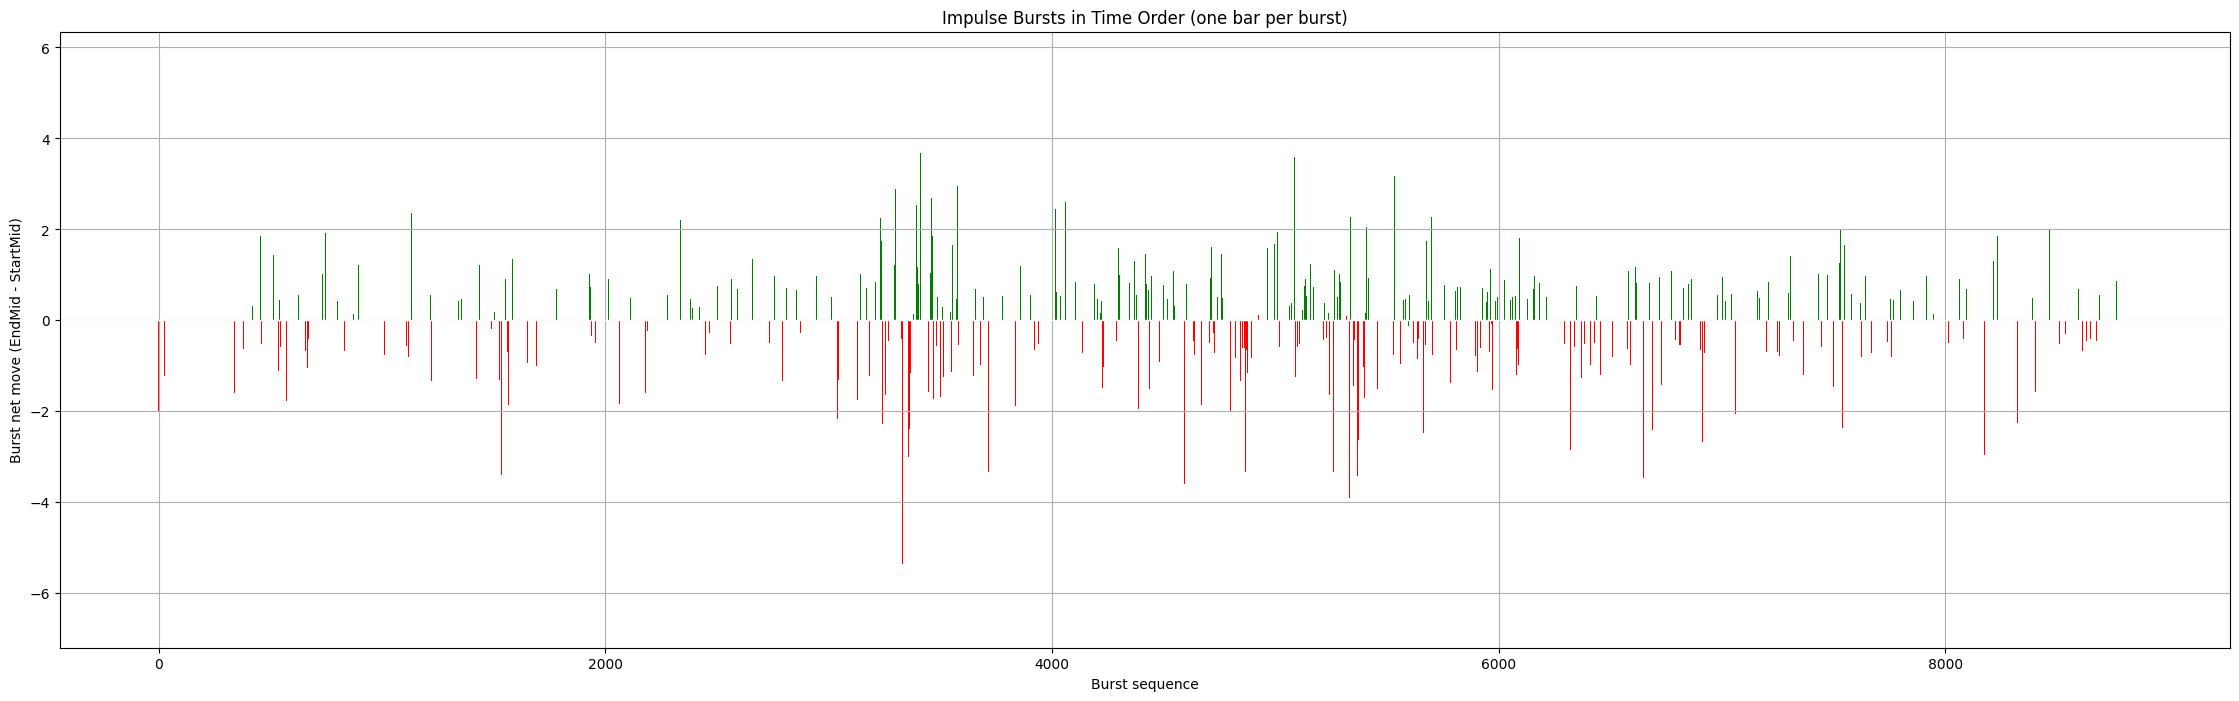

In [13]:
# ============================================================
# Step 7: visualize impulse bursts as bars
# one bar per burst, green=Up, red=Down
# ============================================================

if "BurstSummaryDf" not in globals():
    raise ValueError("BurstSummaryDf not found. Please run the burst-building cell first.")

BurstPlotDf = BurstSummaryDf.copy().sort_values("StartRow").reset_index(drop=True)
BurstPlotDf["BurstSeq"] = np.arange(len(BurstPlotDf), dtype=int)

# Signed move in actual price terms
BurstPlotDf["SignedMove"] = BurstPlotDf["EndMid"] - BurstPlotDf["StartMid"]

# Color by burst direction
BurstPlotDf["BarColor"] = np.where(
    BurstPlotDf["Direction"] == "Up",
    "green",
    "red"
)

print("Burst count:", len(BurstPlotDf))
print("Up bursts:", int((BurstPlotDf["Direction"] == "Up").sum()))
print("Down bursts:", int((BurstPlotDf["Direction"] == "Down").sum()))
print()
print("First 10 bursts:")
display(
    BurstPlotDf[
        ["BurstId", "Direction", "StartRow", "EndRow", "TickCount", "StartTime", "EndTime", "StartMid", "EndMid", "SignedMove", "IsCleanBurst"]
    ].head(10)
)

plt.figure(figsize=(28, 8))
plt.bar(
    BurstPlotDf["BurstSeq"],
    BurstPlotDf["SignedMove"],
    color=BurstPlotDf["BarColor"],
    width=1.0
)
plt.axhline(0, color="white", linewidth=1)
plt.title("Impulse Bursts in Time Order (one bar per burst)")
plt.xlabel("Burst sequence")
plt.ylabel("Burst net move (EndMid - StartMid)")
plt.show()

Run count: 116573

Direction counts:


,Direction,Count
0,Down,58287
1,Up,58286



Overall run statistics:


,Metric,Value
0,MedianTickCount,2.000
1,P95TickCount,5.000
2,MedianDurationSec,0.222
3,P95DurationSec,1.545
4,MedianAbsNetMove,0.010
5,P95AbsNetMove,0.660
6,MedianSumAbsMidDelta,0.190
7,P95SumAbsMidDelta,0.880
8,CleanRunRate,1.000



Run statistics by direction:


,Direction,RunCount,MedianTickCount,P95TickCount,MedianDurationSec,P95DurationSec,MedianAbsNetMove,P95AbsNetMove,CleanRate
0,Down,58287,2.0,5.0,0.223,1.577,0.01,0.66,1.0
1,Up,58286,2.0,5.0,0.222,1.500,0.01,0.66,1.0



First 20 runs:


,RunId,Direction,StartRow,EndRow,TickCount,FlatTickCount,StartTime,EndTime,OpenMid,HighMid,LowMid,CloseMid,NetMove,DirectionalNetMove,IsCleanRun
0,1,Down,1,1,1,0,2026-03-05 10:01:00.741000+11:00,2026-03-05 10:01:00.741000+11:00,5149.24,5149.24,5149.24,5149.24,0.00,-0.00,True
1,2,Up,2,3,2,0,2026-03-05 10:01:00.985000+11:00,2026-03-05 10:01:01.224000+11:00,5149.89,5150.61,5149.89,5150.61,0.72,0.72,True
2,3,Down,4,5,2,0,2026-03-05 10:01:01.454000+11:00,2026-03-05 10:01:01.752000+11:00,5150.09,5150.09,5147.24,5147.24,-2.85,2.85,True
3,4,Up,6,6,1,0,2026-03-05 10:01:01.977000+11:00,2026-03-05 10:01:01.977000+11:00,5148.01,5148.01,5148.01,5148.01,0.00,0.00,True
4,5,Down,7,7,1,0,2026-03-05 10:01:02.183000+11:00,2026-03-05 10:01:02.183000+11:00,5147.86,5147.86,5147.86,5147.86,0.00,-0.00,True
5,6,Up,8,9,2,1,2026-03-05 10:01:02.417000+11:00,2026-03-05 10:01:02.667000+11:00,5148.20,5148.20,5148.20,5148.20,0.00,0.00,True
6,7,Down,10,10,1,0,2026-03-05 10:01:02.904000+11:00,2026-03-05 10:01:02.904000+11:00,5147.82,5147.82,5147.82,5147.82,0.00,-0.00,True
7,8,Up,11,13,3,1,2026-03-05 10:01:03.173000+11:00,2026-03-05 10:01:03.666000+11:00,5148.43,5148.65,5148.43,5148.65,0.22,0.22,True
8,9,Down,14,14,1,0,2026-03-05 10:01:03.938000+11:00,2026-03-05 10:01:03.938000+11:00,5148.42,5148.42,5148.42,5148.42,0.00,-0.00,True
9,10,Up,15,17,3,0,2026-03-05 10:01:04.227000+11:00,2026-03-05 10:01:04.768000+11:00,5148.61,5149.27,5148.61,5149.27,0.66,0.66,True


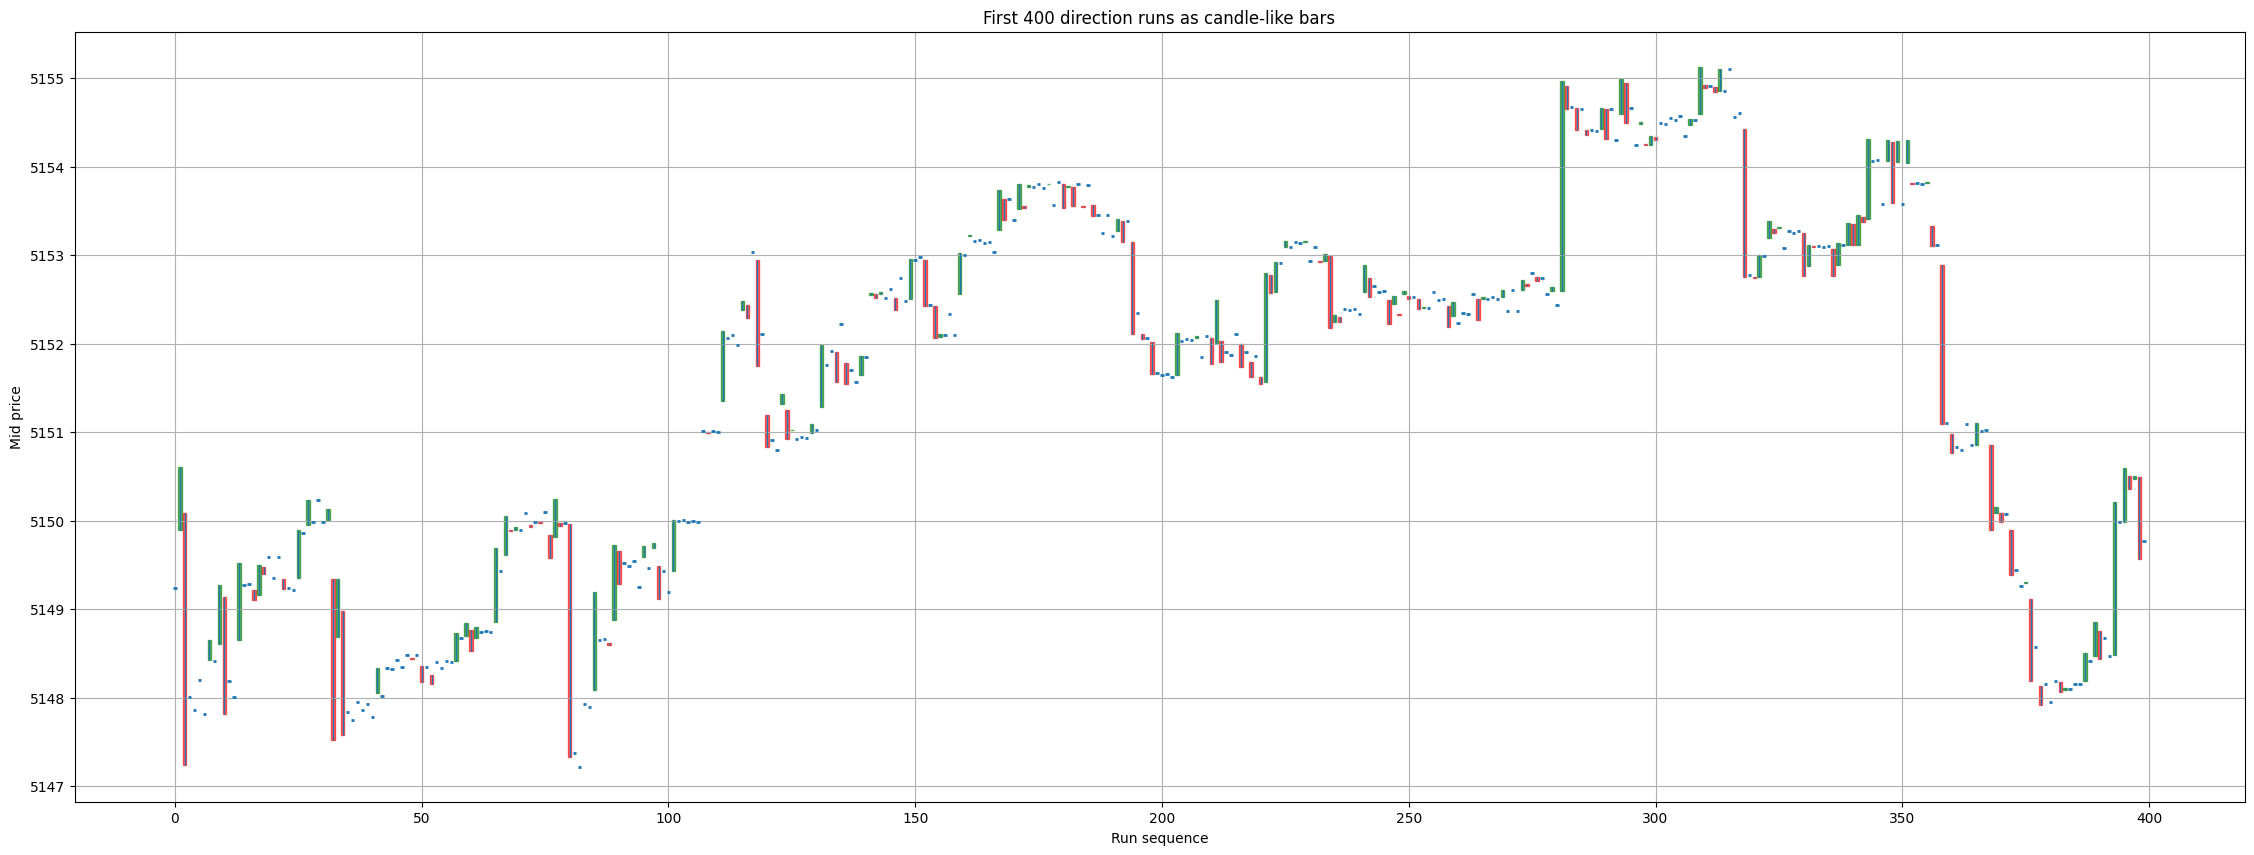

In [14]:
# ============================================================
# Step 7 (revised): build ALL same-direction runs from PaDf
# and visualize them as candle-like bars
# ============================================================

from matplotlib.patches import Rectangle

RunWorkDf = PaDf.copy()

# Non-flat direction only
RunWorkDf["DirNoFlat"] = RunWorkDf["Direction"].where(RunWorkDf["Direction"] != "Flat", np.nan)

# Last seen non-flat direction
RunWorkDf["EffectiveDirection"] = RunWorkDf["DirNoFlat"].ffill()

# A new run starts when a non-flat direction appears and it is different
# from the previous non-flat direction
RunWorkDf["StartsNewRun"] = (
    RunWorkDf["DirNoFlat"].notna() &
    (RunWorkDf["DirNoFlat"] != RunWorkDf["DirNoFlat"].ffill().shift(1))
)

RunWorkDf["RunId"] = RunWorkDf["StartsNewRun"].cumsum()

# Drop any leading rows before the first non-flat move
RunTickDf = RunWorkDf.loc[RunWorkDf["RunId"] > 0].copy()

RunSummaryDf = (
    RunTickDf.groupby("RunId")
    .agg(
        Direction=("EffectiveDirection", "first"),
        StartRow=("RowNumber", "first"),
        EndRow=("RowNumber", "last"),
        StartTickId=("TickId", "first"),
        EndTickId=("TickId", "last"),
        StartTime=("Time", "first"),
        EndTime=("Time", "last"),
        OpenMid=("Mid", "first"),
        HighMid=("Mid", "max"),
        LowMid=("Mid", "min"),
        CloseMid=("Mid", "last"),
        TickCount=("TickId", "size"),
        NonFlatTickCount=("Direction", lambda s: int((s != "Flat").sum())),
        FlatTickCount=("Direction", lambda s: int((s == "Flat").sum())),
        SumAbsMidDelta=("AbsMidDelta", "sum"),
        MaxAbsMidDelta=("AbsMidDelta", "max"),
        MeanSpread=("Spread", "mean"),
    )
    .reset_index()
)

RunSummaryDf["DurationSec"] = (
    RunSummaryDf["EndTime"] - RunSummaryDf["StartTime"]
).dt.total_seconds()

RunSummaryDf["NetMove"] = RunSummaryDf["CloseMid"] - RunSummaryDf["OpenMid"]
RunSummaryDf["AbsNetMove"] = RunSummaryDf["NetMove"].abs()
RunSummaryDf["RowSpan"] = RunSummaryDf["EndRow"] - RunSummaryDf["StartRow"] + 1

RunSummaryDf["DirectionalNetMove"] = np.where(
    RunSummaryDf["Direction"] == "Up",
    RunSummaryDf["NetMove"],
    -RunSummaryDf["NetMove"]
)

RunSummaryDf["IsCleanRun"] = RunSummaryDf["DirectionalNetMove"] >= 0
RunSummaryDf["RunSeq"] = np.arange(len(RunSummaryDf), dtype=int)

print("Run count:", len(RunSummaryDf))
print()
print("Direction counts:")
display(
    RunSummaryDf["Direction"]
    .value_counts()
    .rename_axis("Direction")
    .reset_index(name="Count")
)

print()
print("Overall run statistics:")
display(
    pd.DataFrame({
        "Metric": [
            "MedianTickCount",
            "P95TickCount",
            "MedianDurationSec",
            "P95DurationSec",
            "MedianAbsNetMove",
            "P95AbsNetMove",
            "MedianSumAbsMidDelta",
            "P95SumAbsMidDelta",
            "CleanRunRate",
        ],
        "Value": [
            RunSummaryDf["TickCount"].median(),
            RunSummaryDf["TickCount"].quantile(0.95),
            RunSummaryDf["DurationSec"].median(),
            RunSummaryDf["DurationSec"].quantile(0.95),
            RunSummaryDf["AbsNetMove"].median(),
            RunSummaryDf["AbsNetMove"].quantile(0.95),
            RunSummaryDf["SumAbsMidDelta"].median(),
            RunSummaryDf["SumAbsMidDelta"].quantile(0.95),
            RunSummaryDf["IsCleanRun"].mean(),
        ]
    })
)

print()
print("Run statistics by direction:")
display(
    RunSummaryDf.groupby("Direction").agg(
        RunCount=("RunId", "size"),
        MedianTickCount=("TickCount", "median"),
        P95TickCount=("TickCount", lambda s: s.quantile(0.95)),
        MedianDurationSec=("DurationSec", "median"),
        P95DurationSec=("DurationSec", lambda s: s.quantile(0.95)),
        MedianAbsNetMove=("AbsNetMove", "median"),
        P95AbsNetMove=("AbsNetMove", lambda s: s.quantile(0.95)),
        CleanRate=("IsCleanRun", "mean"),
    ).reset_index()
)

print()
print("First 20 runs:")
display(
    RunSummaryDf[
        [
            "RunId", "Direction", "StartRow", "EndRow",
            "TickCount", "FlatTickCount",
            "StartTime", "EndTime",
            "OpenMid", "HighMid", "LowMid", "CloseMid",
            "NetMove", "DirectionalNetMove", "IsCleanRun"
        ]
    ].head(20)
)

# ------------------------------------------------------------
# Candle-like visualization
# Plot first N runs so it stays readable
# ------------------------------------------------------------
PlotRunCount = 400
PlotDf = RunSummaryDf.head(PlotRunCount).copy()

fig, ax = plt.subplots(figsize=(28, 10))

for _, Row in PlotDf.iterrows():
    X = Row["RunSeq"]
    OpenPrice = Row["OpenMid"]
    HighPrice = Row["HighMid"]
    LowPrice = Row["LowMid"]
    ClosePrice = Row["CloseMid"]

    Color = "green" if Row["Direction"] == "Up" else "red"

    # wick
    ax.vlines(X, LowPrice, HighPrice, linewidth=1)

    # body
    BodyLow = min(OpenPrice, ClosePrice)
    BodyHigh = max(OpenPrice, ClosePrice)
    BodyHeight = BodyHigh - BodyLow

    if BodyHeight == 0:
        ax.hlines(OpenPrice, X - 0.35, X + 0.35, linewidth=2)
    else:
        Rect = Rectangle(
            (X - 0.35, BodyLow),
            0.7,
            BodyHeight,
            facecolor=Color,
            edgecolor=Color,
            alpha=0.6
        )
        ax.add_patch(Rect)

ax.set_title(f"First {PlotRunCount} direction runs as candle-like bars")
ax.set_xlabel("Run sequence")
ax.set_ylabel("Mid price")
plt.show()

Threshold used: 2.0
Coarse segment count: 1815

Segment class counts:


,SegmentClass,Count
0,Down,908
1,Up,907



Overall coarse-segment statistics:


,Metric,Value
0,MedianRunCount,42.0000
1,P95RunCount,206.6000
2,MedianTickCount,91.0000
3,P95TickCount,454.6000
4,MedianDurationSec,25.9220
5,P95DurationSec,158.3679
6,MedianAbsNetMove,3.6900
7,P95AbsNetMove,8.8830



Statistics by segment class:


,SegmentClass,SegmentCount,MedianRunCount,P95RunCount,MedianTickCount,P95TickCount,MedianDurationSec,P95DurationSec,MedianAbsNetMove,P95AbsNetMove
0,Down,908,42.0,206.0,93.0,455.3,25.99,164.1133,3.70,9.2355
1,Up,907,42.0,207.4,91.0,451.1,25.83,150.9074,3.69,8.8270



First 20 coarse segments:


,SegmentId,SegmentClass,StartRunSeq,EndRunSeq,RunCount,TickCount,StartTime,EndTime,OpenMid,HighMid,LowMid,CloseMid,NetMove,AbsNetMove,DurationSec
0,1,Down,0,2,3,5,2026-03-05 10:01:00.741000+11:00,2026-03-05 10:01:01.752000+11:00,5149.24,5150.61,5147.24,5147.24,-2.00,2.00,1.011
1,2,Up,2,29,28,48,2026-03-05 10:01:01.454000+11:00,2026-03-05 10:01:14.842000+11:00,5147.24,5150.23,5147.24,5150.23,2.99,2.99,13.388
2,3,Down,29,32,4,8,2026-03-05 10:01:14.842000+11:00,2026-03-05 10:01:16.503000+11:00,5150.23,5150.23,5147.52,5147.52,-2.71,2.71,1.661
3,4,Up,32,77,46,88,2026-03-05 10:01:15.817000+11:00,2026-03-05 10:01:49.166000+11:00,5147.52,5150.24,5147.52,5150.24,2.72,2.72,33.349
4,5,Down,77,82,6,14,2026-03-05 10:01:47.507000+11:00,2026-03-05 10:01:52.804000+11:00,5150.24,5150.24,5147.22,5147.22,-3.02,3.02,5.297
5,6,Up,82,117,36,69,2026-03-05 10:01:52.804000+11:00,2026-03-05 10:02:16.233000+11:00,5147.22,5153.04,5147.22,5153.04,5.82,5.82,23.429
6,7,Down,117,122,6,8,2026-03-05 10:02:16.233000+11:00,2026-03-05 10:02:17.811000+11:00,5153.04,5153.04,5150.80,5150.80,-2.24,2.24,1.578
7,8,Up,122,179,58,107,2026-03-05 10:02:17.811000+11:00,2026-03-05 10:02:52.110000+11:00,5150.80,5153.83,5150.80,5153.83,3.03,3.03,34.299
8,9,Down,179,220,42,91,2026-03-05 10:02:52.110000+11:00,2026-03-05 10:03:27.724000+11:00,5153.83,5153.83,5151.55,5151.55,-2.28,2.28,35.614
9,10,Up,220,309,90,174,2026-03-05 10:03:27+11:00,2026-03-05 10:04:45.969000+11:00,5151.55,5155.13,5151.55,5155.13,3.58,3.58,78.969


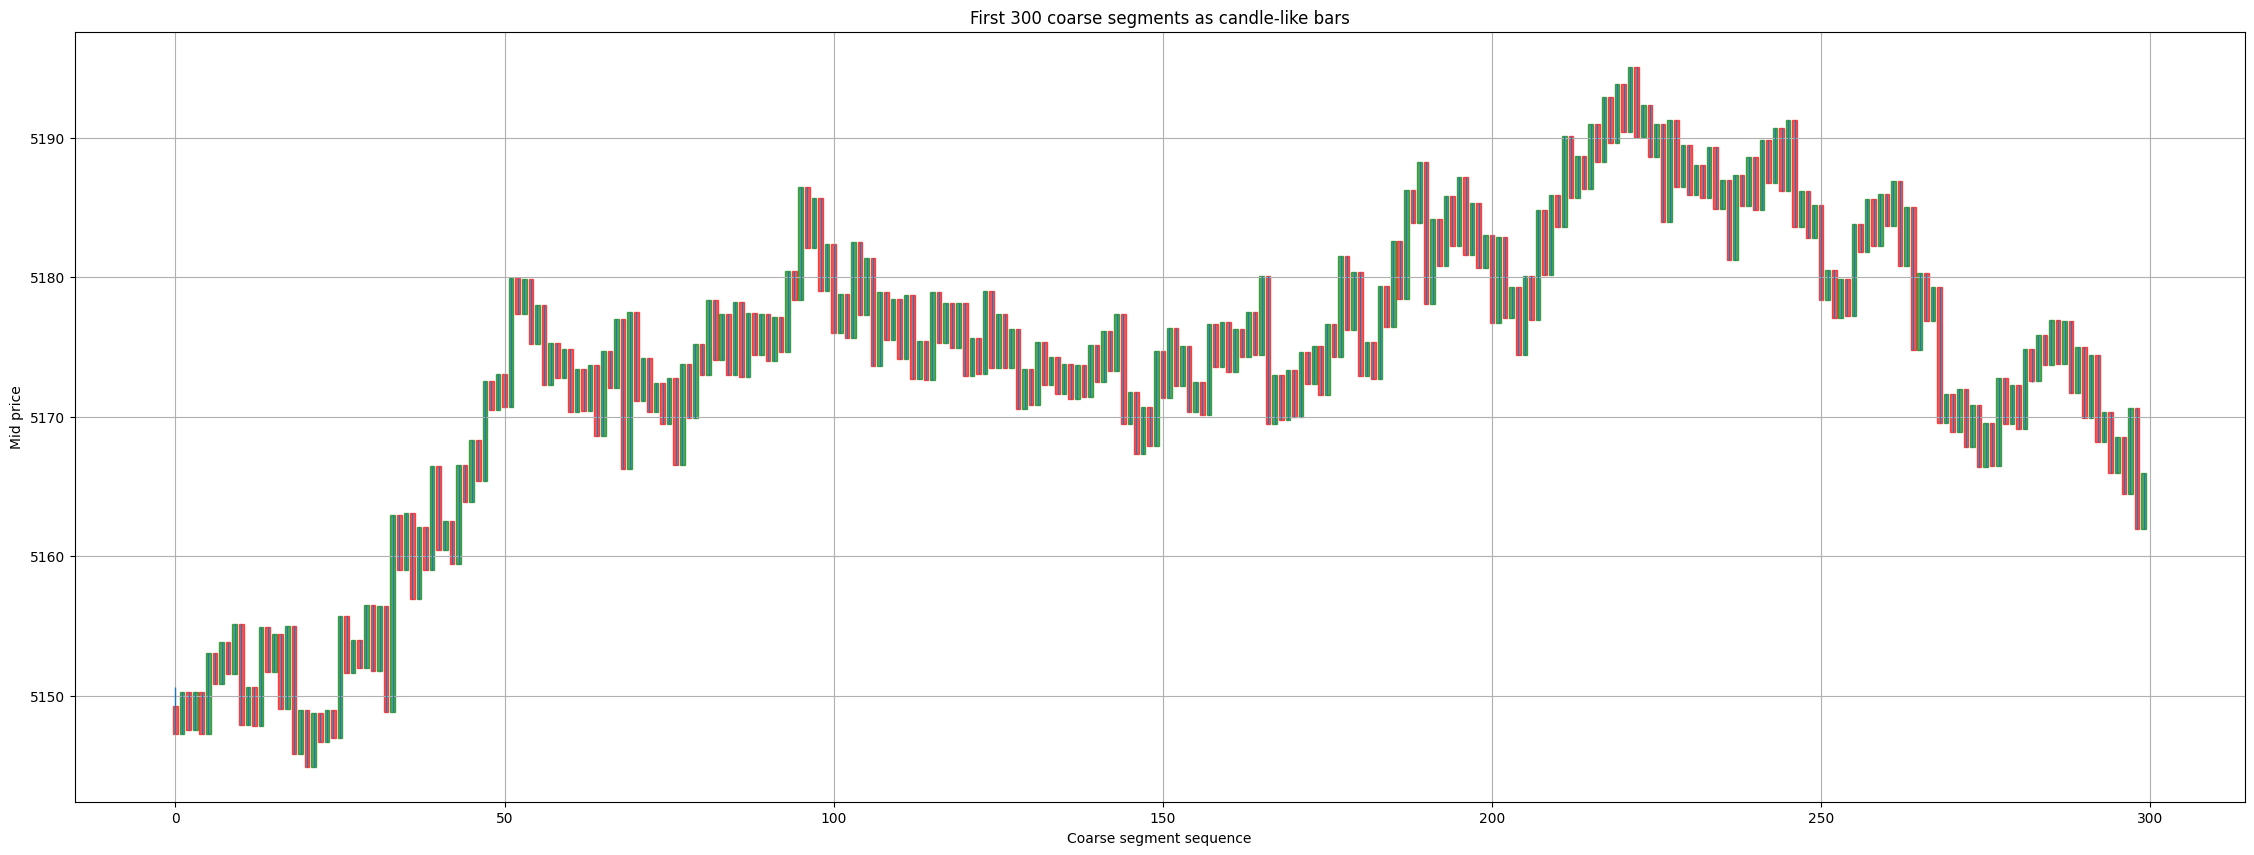

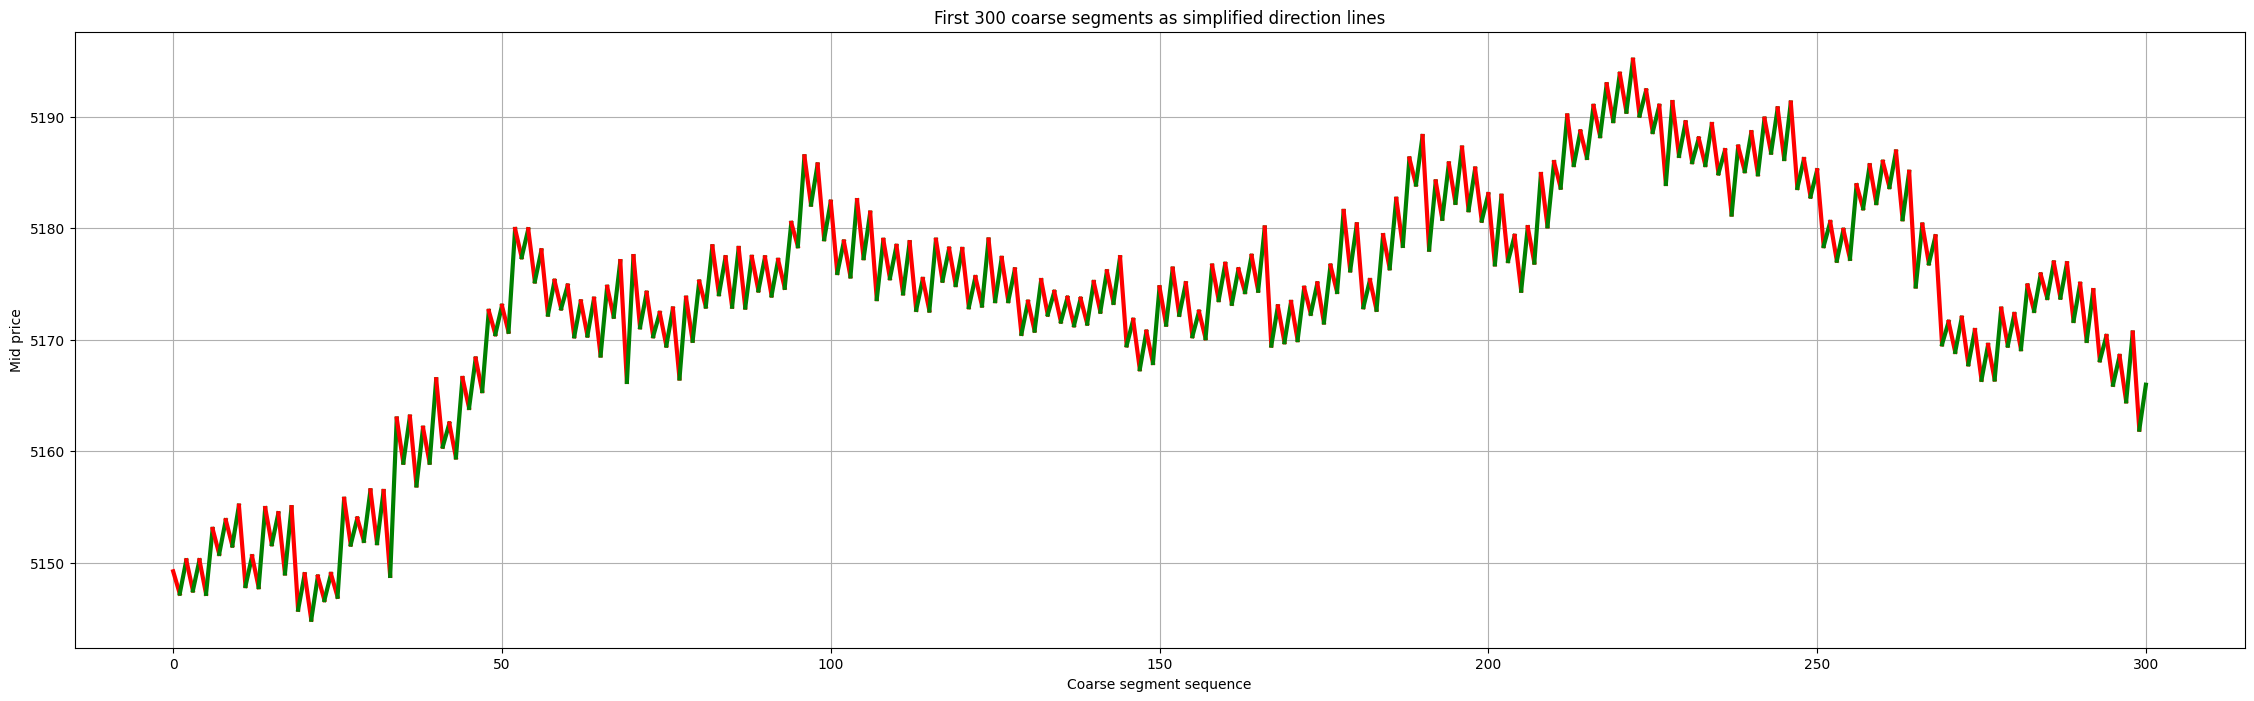

In [15]:
# ============================================================
# Step 8: simplify runs into coarse Up / Down / Horizontal segments
# using a 2-dollar reversal threshold on run closes
# ============================================================

Threshold = 2.0

BaseDf = RunSummaryDf.copy().sort_values("RunSeq").reset_index(drop=True)

if len(BaseDf) == 0:
    raise ValueError("RunSummaryDf is empty.")

SegmentRows = []

def AddSegment(StartIdx, EndIdx, StartPrice, EndPrice, SegmentClass):
    SliceDf = BaseDf.iloc[StartIdx:EndIdx + 1]

    HighValue = max(SliceDf["HighMid"].max(), StartPrice, EndPrice)
    LowValue = min(SliceDf["LowMid"].min(), StartPrice, EndPrice)

    SegmentRows.append({
        "SegmentId": len(SegmentRows) + 1,
        "SegmentClass": SegmentClass,
        "StartRunSeq": int(SliceDf["RunSeq"].iloc[0]),
        "EndRunSeq": int(SliceDf["RunSeq"].iloc[-1]),
        "StartRunId": int(SliceDf["RunId"].iloc[0]),
        "EndRunId": int(SliceDf["RunId"].iloc[-1]),
        "StartTime": SliceDf["StartTime"].iloc[0],
        "EndTime": SliceDf["EndTime"].iloc[-1],
        "OpenMid": float(StartPrice),
        "HighMid": float(HighValue),
        "LowMid": float(LowValue),
        "CloseMid": float(EndPrice),
        "RunCount": int(len(SliceDf)),
        "TickCount": int(SliceDf["TickCount"].sum()),
        "NetMove": float(EndPrice - StartPrice),
        "AbsNetMove": float(abs(EndPrice - StartPrice)),
        "DurationSec": float((SliceDf["EndTime"].iloc[-1] - SliceDf["StartTime"].iloc[0]).total_seconds()),
    })


# ------------------------------------------------------------
# Piecewise simplification logic
# ------------------------------------------------------------

StartIdx = 0
AnchorPrice = float(BaseDf.loc[0, "OpenMid"])

Trend = None
ExtremeIdx = 0
ExtremePrice = float(BaseDf.loc[0, "CloseMid"])

for i in range(len(BaseDf)):
    ClosePrice = float(BaseDf.loc[i, "CloseMid"])

    if Trend is None:
        if ClosePrice >= AnchorPrice + Threshold:
            Trend = "Up"
            ExtremeIdx = i
            ExtremePrice = ClosePrice
        elif ClosePrice <= AnchorPrice - Threshold:
            Trend = "Down"
            ExtremeIdx = i
            ExtremePrice = ClosePrice
        else:
            # still horizontal candidate
            pass

    elif Trend == "Up":
        if ClosePrice >= ExtremePrice:
            ExtremePrice = ClosePrice
            ExtremeIdx = i
        elif ClosePrice <= ExtremePrice - Threshold:
            AddSegment(
                StartIdx=StartIdx,
                EndIdx=ExtremeIdx,
                StartPrice=AnchorPrice,
                EndPrice=ExtremePrice,
                SegmentClass="Up"
            )

            StartIdx = ExtremeIdx
            AnchorPrice = ExtremePrice
            Trend = None
            ExtremeIdx = StartIdx
            ExtremePrice = AnchorPrice

            if ClosePrice <= AnchorPrice - Threshold:
                Trend = "Down"
                ExtremeIdx = i
                ExtremePrice = ClosePrice

    elif Trend == "Down":
        if ClosePrice <= ExtremePrice:
            ExtremePrice = ClosePrice
            ExtremeIdx = i
        elif ClosePrice >= ExtremePrice + Threshold:
            AddSegment(
                StartIdx=StartIdx,
                EndIdx=ExtremeIdx,
                StartPrice=AnchorPrice,
                EndPrice=ExtremePrice,
                SegmentClass="Down"
            )

            StartIdx = ExtremeIdx
            AnchorPrice = ExtremePrice
            Trend = None
            ExtremeIdx = StartIdx
            ExtremePrice = AnchorPrice

            if ClosePrice >= AnchorPrice + Threshold:
                Trend = "Up"
                ExtremeIdx = i
                ExtremePrice = ClosePrice


# ------------------------------------------------------------
# Final tail segment
# ------------------------------------------------------------

FinalEndIdx = len(BaseDf) - 1
FinalClosePrice = float(BaseDf.loc[FinalEndIdx, "CloseMid"])
FinalMove = FinalClosePrice - AnchorPrice

if FinalMove >= Threshold:
    FinalClass = "Up"
elif FinalMove <= -Threshold:
    FinalClass = "Down"
else:
    FinalClass = "Horizontal"

AddSegment(
    StartIdx=StartIdx,
    EndIdx=FinalEndIdx,
    StartPrice=AnchorPrice,
    EndPrice=FinalClosePrice,
    SegmentClass=FinalClass
)

CoarseSegmentDf = pd.DataFrame(SegmentRows)
CoarseSegmentDf["SegmentSeq"] = np.arange(len(CoarseSegmentDf), dtype=int)

print("Threshold used:", Threshold)
print("Coarse segment count:", len(CoarseSegmentDf))
print()

print("Segment class counts:")
display(
    CoarseSegmentDf["SegmentClass"]
    .value_counts()
    .rename_axis("SegmentClass")
    .reset_index(name="Count")
)

print()
print("Overall coarse-segment statistics:")
display(
    pd.DataFrame({
        "Metric": [
            "MedianRunCount",
            "P95RunCount",
            "MedianTickCount",
            "P95TickCount",
            "MedianDurationSec",
            "P95DurationSec",
            "MedianAbsNetMove",
            "P95AbsNetMove",
        ],
        "Value": [
            CoarseSegmentDf["RunCount"].median(),
            CoarseSegmentDf["RunCount"].quantile(0.95),
            CoarseSegmentDf["TickCount"].median(),
            CoarseSegmentDf["TickCount"].quantile(0.95),
            CoarseSegmentDf["DurationSec"].median(),
            CoarseSegmentDf["DurationSec"].quantile(0.95),
            CoarseSegmentDf["AbsNetMove"].median(),
            CoarseSegmentDf["AbsNetMove"].quantile(0.95),
        ]
    })
)

print()
print("Statistics by segment class:")
display(
    CoarseSegmentDf.groupby("SegmentClass").agg(
        SegmentCount=("SegmentId", "size"),
        MedianRunCount=("RunCount", "median"),
        P95RunCount=("RunCount", lambda s: s.quantile(0.95)),
        MedianTickCount=("TickCount", "median"),
        P95TickCount=("TickCount", lambda s: s.quantile(0.95)),
        MedianDurationSec=("DurationSec", "median"),
        P95DurationSec=("DurationSec", lambda s: s.quantile(0.95)),
        MedianAbsNetMove=("AbsNetMove", "median"),
        P95AbsNetMove=("AbsNetMove", lambda s: s.quantile(0.95)),
    ).reset_index()
)

print()
print("First 20 coarse segments:")
display(
    CoarseSegmentDf[
        [
            "SegmentId", "SegmentClass",
            "StartRunSeq", "EndRunSeq",
            "RunCount", "TickCount",
            "StartTime", "EndTime",
            "OpenMid", "HighMid", "LowMid", "CloseMid",
            "NetMove", "AbsNetMove", "DurationSec"
        ]
    ].head(20)
)

# ------------------------------------------------------------
# Visual 1: simplified candle-like bars
# ------------------------------------------------------------
from matplotlib.patches import Rectangle

PlotCount = min(300, len(CoarseSegmentDf))
PlotDf = CoarseSegmentDf.head(PlotCount).copy()

fig, ax = plt.subplots(figsize=(28, 10))

ColorMap = {
    "Up": "green",
    "Down": "red",
    "Horizontal": "blue",
}

for _, Row in PlotDf.iterrows():
    X = Row["SegmentSeq"]
    OpenPrice = Row["OpenMid"]
    HighPrice = Row["HighMid"]
    LowPrice = Row["LowMid"]
    ClosePrice = Row["CloseMid"]
    Color = ColorMap[Row["SegmentClass"]]

    ax.vlines(X, LowPrice, HighPrice, linewidth=1)

    BodyLow = min(OpenPrice, ClosePrice)
    BodyHigh = max(OpenPrice, ClosePrice)
    BodyHeight = BodyHigh - BodyLow

    if BodyHeight == 0:
        ax.hlines(OpenPrice, X - 0.35, X + 0.35, linewidth=3)
    else:
        Rect = Rectangle(
            (X - 0.35, BodyLow),
            0.7,
            BodyHeight,
            facecolor=Color,
            edgecolor=Color,
            alpha=0.65
        )
        ax.add_patch(Rect)

ax.set_title(f"First {PlotCount} coarse segments as candle-like bars")
ax.set_xlabel("Coarse segment sequence")
ax.set_ylabel("Mid price")
plt.show()

# ------------------------------------------------------------
# Visual 2: pure simplified direction lines
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(28, 8))

for _, Row in PlotDf.iterrows():
    X1 = Row["SegmentSeq"]
    X2 = Row["SegmentSeq"] + 1
    Y1 = Row["OpenMid"]
    Y2 = Row["CloseMid"]
    Color = ColorMap[Row["SegmentClass"]]

    ax.plot([X1, X2], [Y1, Y2], linewidth=3, color=Color)

ax.set_title(f"First {PlotCount} coarse segments as simplified direction lines")
ax.set_xlabel("Coarse segment sequence")
ax.set_ylabel("Mid price")
plt.show()

Parameters used:
TrendThreshold = 2.0
ReversalThreshold = 2.0
MinSpikeEfficiency = 0.35
HorizontalMaxEfficiency = 0.22
HorizontalMinRunCount = 8
HorizontalMinDurationSec = 4.0
HorizontalBreakoutBuffer = 0.5

3-class segment count: 1901

Segment class counts:


,SegmentClass,Count
0,Horizontal,1311
1,UpSpike,299
2,DownSpike,291



Overall statistics:


,Metric,Value
0,MedianRunCount,29.000000
1,P95RunCount,188.000000
2,MedianTickCount,62.000000
3,P95TickCount,407.000000
4,MedianDurationSec,17.237000
5,P95DurationSec,148.240000
6,MedianAbsNetMove,1.230000
7,P95AbsNetMove,6.450000
8,MedianEfficiency,0.108173
9,P95Efficiency,0.747573



Statistics by class:


,SegmentClass,SegmentCount,MedianRunCount,P95RunCount,MedianTickCount,P95TickCount,MedianDurationSec,P95DurationSec,MedianAbsNetMove,P95AbsNetMove,MedianEfficiency,P95Efficiency
0,DownSpike,291,18.0,110.0,39.0,235.5,10.119,70.6345,3.72,9.800,0.476067,0.956737
1,Horizontal,1311,33.0,222.0,71.0,497.0,20.288,183.4765,0.69,2.490,0.063970,0.222066
2,UpSpike,299,22.0,140.0,46.0,310.5,11.804,97.6013,3.66,8.964,0.426136,0.905487



First 25 segments:


,SegmentId,SegmentClass,StartRunSeq,EndRunSeq,RunCount,TickCount,StartTime,EndTime,OpenMid,HighMid,LowMid,CloseMid,NetMove,AbsNetMove,DurationSec,Efficiency
0,1,Horizontal,0,110,111,206,2026-03-05 10:01:00.741000+11:00,2026-03-05 10:02:12.444000+11:00,5149.24,5151.01,5147.22,5151.00,1.76,1.76,71.703,0.040073
1,2,Horizontal,111,119,9,19,2026-03-05 10:02:12.670000+11:00,2026-03-05 10:02:16.907000+11:00,5151.35,5153.04,5151.35,5152.11,0.76,0.76,4.237,0.170787
2,3,Horizontal,120,166,47,85,2026-03-05 10:02:17.132000+11:00,2026-03-05 10:02:43.462000+11:00,5151.19,5153.23,5150.80,5153.04,1.85,1.85,26.330,0.155071
3,4,Horizontal,167,193,27,53,2026-03-05 10:02:43.686000+11:00,2026-03-05 10:03:02.508000+11:00,5153.28,5153.83,5153.15,5153.39,0.11,0.11,18.822,0.017378
4,5,Horizontal,194,280,87,172,2026-03-05 10:03:02.919000+11:00,2026-03-05 10:04:22.452000+11:00,5153.15,5153.16,5151.55,5152.44,-0.71,0.71,79.533,0.039821
5,6,UpSpike,281,309,29,61,2026-03-05 10:04:22.672000+11:00,2026-03-05 10:04:45.969000+11:00,5152.60,5155.13,5152.60,5155.13,2.53,2.53,23.297,0.285876
6,7,Horizontal,318,357,40,89,2026-03-05 10:04:52.343000+11:00,2026-03-05 10:05:28.480000+11:00,5154.43,5154.43,5152.74,5153.12,-1.31,1.31,36.137,0.105560
7,8,DownSpike,358,378,21,47,2026-03-05 10:05:30.001000+11:00,2026-03-05 10:05:47.836000+11:00,5152.89,5152.89,5147.92,5147.92,-4.97,4.97,17.835,0.609069
8,9,UpSpike,393,395,3,11,2026-03-05 10:05:54.390000+11:00,2026-03-05 10:05:57.345000+11:00,5148.48,5150.59,5148.48,5150.59,2.11,2.11,2.955,0.817829
9,10,UpSpike,408,509,102,207,2026-03-05 10:06:04.695000+11:00,2026-03-05 10:07:09.621000+11:00,5149.11,5154.91,5147.82,5154.91,5.80,5.80,64.926,0.190102


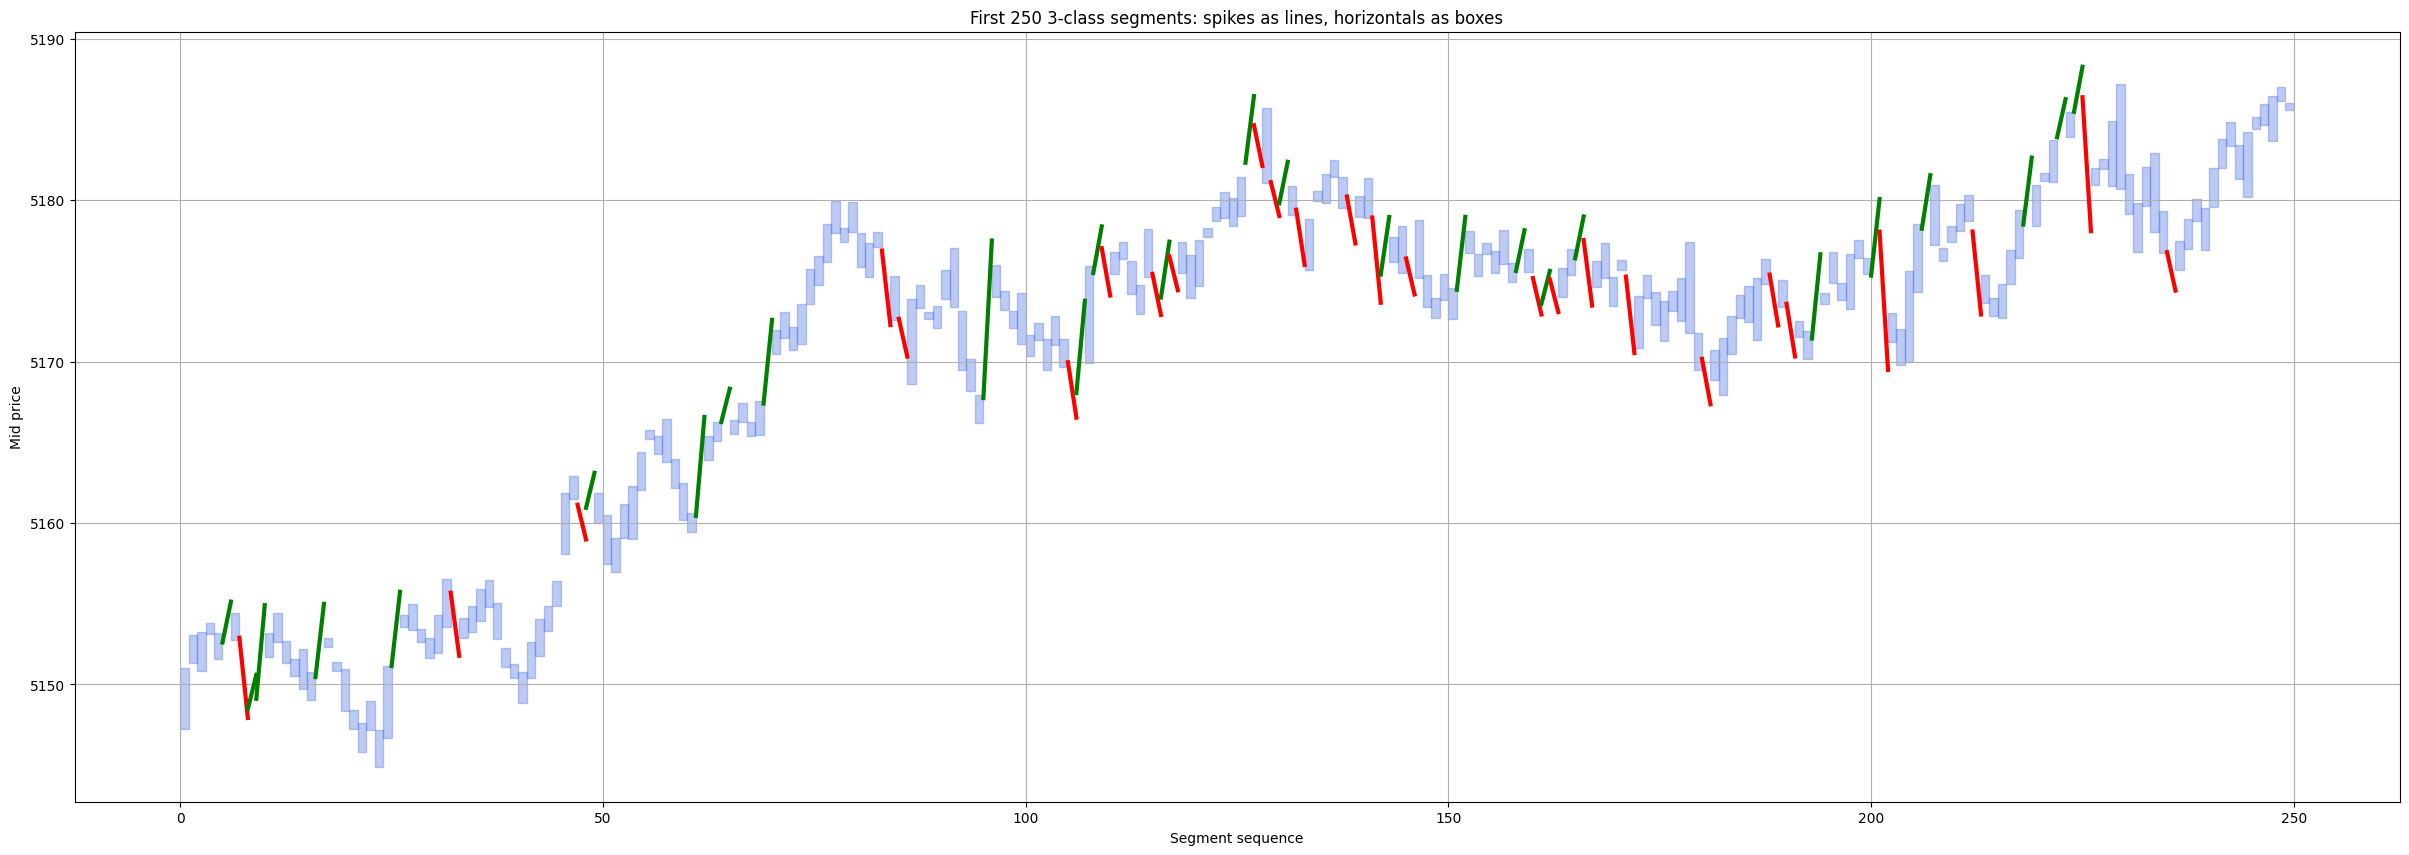

In [16]:
# ============================================================
# Step 9: build 3-class segments
# UpSpike / DownSpike / Horizontal
# Horizontal is kept as its own box, not absorbed into swings
# ============================================================

from matplotlib.patches import Rectangle

BaseDf = RunSummaryDf.copy().sort_values("RunSeq").reset_index(drop=True)

# -----------------------------
# Tunable parameters
# -----------------------------
TrendThreshold = 2.0                 # prove a spike direction
ReversalThreshold = 2.0              # end a spike when reversed enough
MinSpikeEfficiency = 0.35            # abs(net move) / sum(abs internal move)
HorizontalMaxEfficiency = 0.22       # if too inefficient, treat as box
HorizontalMinRunCount = 8            # minimum size before calling it a box
HorizontalMinDurationSec = 4.0       # minimum time before calling it a box
HorizontalBreakoutBuffer = 0.50      # breakout beyond box before new spike starts

# -----------------------------
# Helpers
# -----------------------------
SegmentRows = []

def FinalizeSegment(StartIdx, EndIdx, SegmentClass):
    SliceDf = BaseDf.iloc[StartIdx:EndIdx + 1].copy()

    OpenMid = float(SliceDf["OpenMid"].iloc[0])
    CloseMid = float(SliceDf["CloseMid"].iloc[-1])
    HighMid = float(SliceDf["HighMid"].max())
    LowMid = float(SliceDf["LowMid"].min())
    DurationSec = float((SliceDf["EndTime"].iloc[-1] - SliceDf["StartTime"].iloc[0]).total_seconds())
    SumAbsMove = float(SliceDf["SumAbsMidDelta"].sum())
    NetMove = float(CloseMid - OpenMid)
    Efficiency = abs(NetMove) / SumAbsMove if SumAbsMove > 0 else 0.0

    SegmentRows.append({
        "SegmentId": len(SegmentRows) + 1,
        "SegmentClass": SegmentClass,
        "StartRunSeq": int(SliceDf["RunSeq"].iloc[0]),
        "EndRunSeq": int(SliceDf["RunSeq"].iloc[-1]),
        "StartRunId": int(SliceDf["RunId"].iloc[0]),
        "EndRunId": int(SliceDf["RunId"].iloc[-1]),
        "StartTime": SliceDf["StartTime"].iloc[0],
        "EndTime": SliceDf["EndTime"].iloc[-1],
        "OpenMid": OpenMid,
        "HighMid": HighMid,
        "LowMid": LowMid,
        "CloseMid": CloseMid,
        "RunCount": int(len(SliceDf)),
        "TickCount": int(SliceDf["TickCount"].sum()),
        "DurationSec": DurationSec,
        "NetMove": NetMove,
        "AbsNetMove": abs(NetMove),
        "SumAbsMidDelta": SumAbsMove,
        "Efficiency": Efficiency,
    })


def SegmentStats(StartIdx, EndIdx):
    SliceDf = BaseDf.iloc[StartIdx:EndIdx + 1]
    OpenMid = float(SliceDf["OpenMid"].iloc[0])
    CloseMid = float(SliceDf["CloseMid"].iloc[-1])
    HighMid = float(SliceDf["HighMid"].max())
    LowMid = float(SliceDf["LowMid"].min())
    DurationSec = float((SliceDf["EndTime"].iloc[-1] - SliceDf["StartTime"].iloc[0]).total_seconds())
    SumAbsMove = float(SliceDf["SumAbsMidDelta"].sum())
    NetMove = float(CloseMid - OpenMid)
    Efficiency = abs(NetMove) / SumAbsMove if SumAbsMove > 0 else 0.0
    RunCount = int(len(SliceDf))
    return {
        "OpenMid": OpenMid,
        "CloseMid": CloseMid,
        "HighMid": HighMid,
        "LowMid": LowMid,
        "DurationSec": DurationSec,
        "SumAbsMove": SumAbsMove,
        "NetMove": NetMove,
        "Efficiency": Efficiency,
        "RunCount": RunCount,
    }


# -----------------------------
# Main state machine
# -----------------------------
i = 0
StartIdx = 0
State = "Undecided"
ExtremeIdx = 0
ExtremePrice = float(BaseDf.loc[0, "CloseMid"])

while i < len(BaseDf):
    Stats = SegmentStats(StartIdx, i)
    NetMove = Stats["NetMove"]
    Efficiency = Stats["Efficiency"]
    RunCount = Stats["RunCount"]
    DurationSec = Stats["DurationSec"]

    if State == "Undecided":
        # prove spike
        if NetMove >= TrendThreshold and Efficiency >= MinSpikeEfficiency:
            State = "UpSpike"
            ExtremeIdx = i
            ExtremePrice = float(BaseDf.loc[i, "CloseMid"])

        elif NetMove <= -TrendThreshold and Efficiency >= MinSpikeEfficiency:
            State = "DownSpike"
            ExtremeIdx = i
            ExtremePrice = float(BaseDf.loc[i, "CloseMid"])

        # prove horizontal / box
        elif (
            RunCount >= HorizontalMinRunCount and
            DurationSec >= HorizontalMinDurationSec and
            abs(NetMove) < TrendThreshold and
            Efficiency <= HorizontalMaxEfficiency
        ):
            State = "Horizontal"

        i += 1
        continue

    elif State == "UpSpike":
        CurrentClose = float(BaseDf.loc[i, "CloseMid"])

        if CurrentClose >= ExtremePrice:
            ExtremePrice = CurrentClose
            ExtremeIdx = i

        elif CurrentClose <= ExtremePrice - ReversalThreshold:
            FinalizeSegment(StartIdx, ExtremeIdx, "UpSpike")
            StartIdx = i
            State = "Undecided"
            ExtremeIdx = i
            ExtremePrice = float(BaseDf.loc[i, "CloseMid"])
            continue

        i += 1
        continue

    elif State == "DownSpike":
        CurrentClose = float(BaseDf.loc[i, "CloseMid"])

        if CurrentClose <= ExtremePrice:
            ExtremePrice = CurrentClose
            ExtremeIdx = i

        elif CurrentClose >= ExtremePrice + ReversalThreshold:
            FinalizeSegment(StartIdx, ExtremeIdx, "DownSpike")
            StartIdx = i
            State = "Undecided"
            ExtremeIdx = i
            ExtremePrice = float(BaseDf.loc[i, "CloseMid"])
            continue

        i += 1
        continue

    elif State == "Horizontal":
        # box breakout should start a new segment, not be absorbed
        if i > StartIdx:
            PriorStats = SegmentStats(StartIdx, i - 1)
            PriorHigh = PriorStats["HighMid"]
            PriorLow = PriorStats["LowMid"]
            CurrentClose = float(BaseDf.loc[i, "CloseMid"])

            BreaksUp = CurrentClose >= PriorHigh + HorizontalBreakoutBuffer
            BreaksDown = CurrentClose <= PriorLow - HorizontalBreakoutBuffer

            if BreaksUp or BreaksDown:
                FinalizeSegment(StartIdx, i - 1, "Horizontal")
                StartIdx = i
                State = "Undecided"
                ExtremeIdx = i
                ExtremePrice = float(BaseDf.loc[i, "CloseMid"])
                continue

        i += 1
        continue


# -----------------------------
# Final tail
# -----------------------------
if StartIdx <= len(BaseDf) - 1:
    TailStats = SegmentStats(StartIdx, len(BaseDf) - 1)
    TailNetMove = TailStats["NetMove"]
    TailEfficiency = TailStats["Efficiency"]

    if State == "UpSpike":
        TailClass = "UpSpike"
    elif State == "DownSpike":
        TailClass = "DownSpike"
    elif State == "Horizontal":
        TailClass = "Horizontal"
    else:
        # undecided tail
        if TailNetMove >= TrendThreshold and TailEfficiency >= MinSpikeEfficiency:
            TailClass = "UpSpike"
        elif TailNetMove <= -TrendThreshold and TailEfficiency >= MinSpikeEfficiency:
            TailClass = "DownSpike"
        else:
            TailClass = "Horizontal"

    FinalizeSegment(StartIdx, len(BaseDf) - 1, TailClass)

ThreeClassSegmentDf = pd.DataFrame(SegmentRows)
ThreeClassSegmentDf["SegmentSeq"] = np.arange(len(ThreeClassSegmentDf), dtype=int)

# -----------------------------
# Output
# -----------------------------
print("Parameters used:")
print("TrendThreshold =", TrendThreshold)
print("ReversalThreshold =", ReversalThreshold)
print("MinSpikeEfficiency =", MinSpikeEfficiency)
print("HorizontalMaxEfficiency =", HorizontalMaxEfficiency)
print("HorizontalMinRunCount =", HorizontalMinRunCount)
print("HorizontalMinDurationSec =", HorizontalMinDurationSec)
print("HorizontalBreakoutBuffer =", HorizontalBreakoutBuffer)
print()

print("3-class segment count:", len(ThreeClassSegmentDf))
print()

print("Segment class counts:")
display(
    ThreeClassSegmentDf["SegmentClass"]
    .value_counts()
    .rename_axis("SegmentClass")
    .reset_index(name="Count")
)

print()
print("Overall statistics:")
display(
    pd.DataFrame({
        "Metric": [
            "MedianRunCount",
            "P95RunCount",
            "MedianTickCount",
            "P95TickCount",
            "MedianDurationSec",
            "P95DurationSec",
            "MedianAbsNetMove",
            "P95AbsNetMove",
            "MedianEfficiency",
            "P95Efficiency",
        ],
        "Value": [
            ThreeClassSegmentDf["RunCount"].median(),
            ThreeClassSegmentDf["RunCount"].quantile(0.95),
            ThreeClassSegmentDf["TickCount"].median(),
            ThreeClassSegmentDf["TickCount"].quantile(0.95),
            ThreeClassSegmentDf["DurationSec"].median(),
            ThreeClassSegmentDf["DurationSec"].quantile(0.95),
            ThreeClassSegmentDf["AbsNetMove"].median(),
            ThreeClassSegmentDf["AbsNetMove"].quantile(0.95),
            ThreeClassSegmentDf["Efficiency"].median(),
            ThreeClassSegmentDf["Efficiency"].quantile(0.95),
        ]
    })
)

print()
print("Statistics by class:")
display(
    ThreeClassSegmentDf.groupby("SegmentClass").agg(
        SegmentCount=("SegmentId", "size"),
        MedianRunCount=("RunCount", "median"),
        P95RunCount=("RunCount", lambda s: s.quantile(0.95)),
        MedianTickCount=("TickCount", "median"),
        P95TickCount=("TickCount", lambda s: s.quantile(0.95)),
        MedianDurationSec=("DurationSec", "median"),
        P95DurationSec=("DurationSec", lambda s: s.quantile(0.95)),
        MedianAbsNetMove=("AbsNetMove", "median"),
        P95AbsNetMove=("AbsNetMove", lambda s: s.quantile(0.95)),
        MedianEfficiency=("Efficiency", "median"),
        P95Efficiency=("Efficiency", lambda s: s.quantile(0.95)),
    ).reset_index()
)

print()
print("First 25 segments:")
display(
    ThreeClassSegmentDf[
        [
            "SegmentId", "SegmentClass",
            "StartRunSeq", "EndRunSeq",
            "RunCount", "TickCount",
            "StartTime", "EndTime",
            "OpenMid", "HighMid", "LowMid", "CloseMid",
            "NetMove", "AbsNetMove", "DurationSec", "Efficiency"
        ]
    ].head(25)
)

# -----------------------------
# Visual: spikes as lines, horizontals as boxes
# -----------------------------
PlotCount = min(250, len(ThreeClassSegmentDf))
PlotDf = ThreeClassSegmentDf.head(PlotCount).copy()

fig, ax = plt.subplots(figsize=(30, 10))

for _, Row in PlotDf.iterrows():
    X1 = Row["SegmentSeq"]
    X2 = Row["SegmentSeq"] + 1

    if Row["SegmentClass"] == "UpSpike":
        ax.plot([X1, X2], [Row["OpenMid"], Row["CloseMid"]], linewidth=3, color="green")

    elif Row["SegmentClass"] == "DownSpike":
        ax.plot([X1, X2], [Row["OpenMid"], Row["CloseMid"]], linewidth=3, color="red")

    else:  # Horizontal
        Rect = Rectangle(
            (X1, Row["LowMid"]),
            1.0,
            Row["HighMid"] - Row["LowMid"] if Row["HighMid"] > Row["LowMid"] else 0.05,
            facecolor="royalblue",
            edgecolor="royalblue",
            alpha=0.35
        )
        ax.add_patch(Rect)

ax.set_title(f"First {PlotCount} 3-class segments: spikes as lines, horizontals as boxes")
ax.set_xlabel("Segment sequence")
ax.set_ylabel("Mid price")
plt.show()

In [17]:
AuditDf = ThreeClassSegmentDf.copy()

AuditDf["PassedUpMoveRule"] = (
    (AuditDf["NetMove"] >= 2.0) &
    (AuditDf["Efficiency"] >= 0.35)
)

AuditDf["PassedDownMoveRule"] = (
    (AuditDf["NetMove"] <= -2.0) &
    (AuditDf["Efficiency"] >= 0.35)
)

AuditDf["PassedHorizontalRule"] = (
    (AuditDf["RunCount"] >= 8) &
    (AuditDf["DurationSec"] >= 4.0) &
    (AuditDf["AbsNetMove"] < 2.0) &
    (AuditDf["Efficiency"] <= 0.22)
)

display(
    AuditDf[
        [
            "SegmentId",
            "SegmentClass",
            "RunCount",
            "TickCount",
            "DurationSec",
            "NetMove",
            "AbsNetMove",
            "SumAbsMidDelta",
            "Efficiency",
            "PassedUpMoveRule",
            "PassedDownMoveRule",
            "PassedHorizontalRule",
            "StartTime",
            "EndTime",
            "OpenMid",
            "HighMid",
            "LowMid",
            "CloseMid",
        ]
    ].head(40)
)

,SegmentId,SegmentClass,RunCount,TickCount,DurationSec,NetMove,AbsNetMove,SumAbsMidDelta,Efficiency,PassedUpMoveRule,PassedDownMoveRule,PassedHorizontalRule,StartTime,EndTime,OpenMid,HighMid,LowMid,CloseMid
0,1,Horizontal,111,206,71.703,1.76,1.76,43.92,0.040073,False,False,True,2026-03-05 10:01:00.741000+11:00,2026-03-05 10:02:12.444000+11:00,5149.24,5151.01,5147.22,5151.00
1,2,Horizontal,9,19,4.237,0.76,0.76,4.45,0.170787,False,False,True,2026-03-05 10:02:12.670000+11:00,2026-03-05 10:02:16.907000+11:00,5151.35,5153.04,5151.35,5152.11
2,3,Horizontal,47,85,26.330,1.85,1.85,11.93,0.155071,False,False,True,2026-03-05 10:02:17.132000+11:00,2026-03-05 10:02:43.462000+11:00,5151.19,5153.23,5150.80,5153.04
3,4,Horizontal,27,53,18.822,0.11,0.11,6.33,0.017378,False,False,True,2026-03-05 10:02:43.686000+11:00,2026-03-05 10:03:02.508000+11:00,5153.28,5153.83,5153.15,5153.39
4,5,Horizontal,87,172,79.533,-0.71,0.71,17.83,0.039821,False,False,True,2026-03-05 10:03:02.919000+11:00,2026-03-05 10:04:22.452000+11:00,5153.15,5153.16,5151.55,5152.44
5,6,UpSpike,29,61,23.297,2.53,2.53,8.85,0.285876,False,False,False,2026-03-05 10:04:22.672000+11:00,2026-03-05 10:04:45.969000+11:00,5152.60,5155.13,5152.60,5155.13
6,7,Horizontal,40,89,36.137,-1.31,1.31,12.41,0.105560,False,False,True,2026-03-05 10:04:52.343000+11:00,2026-03-05 10:05:28.480000+11:00,5154.43,5154.43,5152.74,5153.12
7,8,DownSpike,21,47,17.835,-4.97,4.97,8.16,0.609069,False,True,False,2026-03-05 10:05:30.001000+11:00,2026-03-05 10:05:47.836000+11:00,5152.89,5152.89,5147.92,5147.92
8,9,UpSpike,3,11,2.955,2.11,2.11,2.58,0.817829,True,False,False,2026-03-05 10:05:54.390000+11:00,2026-03-05 10:05:57.345000+11:00,5148.48,5150.59,5148.48,5150.59
9,10,UpSpike,102,207,64.926,5.80,5.80,30.51,0.190102,False,False,False,2026-03-05 10:06:04.695000+11:00,2026-03-05 10:07:09.621000+11:00,5149.11,5154.91,5147.82,5154.91


Final-only classification thresholds:
SpikeMoveThreshold       = 2.0
SpikeEfficiencyThreshold = 0.18

Final class counts:


,FinalClass,Count
0,Horizontal,1318
1,DownSpike,297
2,UpSpike,286



Statistics by final class:


,FinalClass,SegmentCount,MedianRunCount,P95RunCount,MedianTickCount,P95TickCount,MedianDurationSec,P95DurationSec,MedianAbsNetMove,P95AbsNetMove,MedianEfficiency,P95Efficiency
0,DownSpike,297,19.0,89.80,40.0,186.40,10.1350,55.04740,3.570,9.7820,0.474000,0.956164
1,Horizontal,1318,34.0,222.15,73.0,501.75,21.1435,186.20880,0.690,2.9615,0.064131,0.215060
2,UpSpike,286,19.5,97.00,44.0,206.25,11.2765,60.85375,3.425,8.7125,0.438507,0.908798



First 30 final-classified segments:


,SegmentId,FinalClass,RunCount,TickCount,DurationSec,NetMove,AbsNetMove,SumAbsMidDelta,Efficiency,StartTime,EndTime,OpenMid,HighMid,LowMid,CloseMid
0,1,Horizontal,111,206,71.703,1.76,1.76,43.92,0.040073,2026-03-05 10:01:00.741000+11:00,2026-03-05 10:02:12.444000+11:00,5149.24,5151.01,5147.22,5151.00
1,2,Horizontal,9,19,4.237,0.76,0.76,4.45,0.170787,2026-03-05 10:02:12.670000+11:00,2026-03-05 10:02:16.907000+11:00,5151.35,5153.04,5151.35,5152.11
2,3,Horizontal,47,85,26.330,1.85,1.85,11.93,0.155071,2026-03-05 10:02:17.132000+11:00,2026-03-05 10:02:43.462000+11:00,5151.19,5153.23,5150.80,5153.04
3,4,Horizontal,27,53,18.822,0.11,0.11,6.33,0.017378,2026-03-05 10:02:43.686000+11:00,2026-03-05 10:03:02.508000+11:00,5153.28,5153.83,5153.15,5153.39
4,5,Horizontal,87,172,79.533,-0.71,0.71,17.83,0.039821,2026-03-05 10:03:02.919000+11:00,2026-03-05 10:04:22.452000+11:00,5153.15,5153.16,5151.55,5152.44
5,6,UpSpike,29,61,23.297,2.53,2.53,8.85,0.285876,2026-03-05 10:04:22.672000+11:00,2026-03-05 10:04:45.969000+11:00,5152.60,5155.13,5152.60,5155.13
6,7,Horizontal,40,89,36.137,-1.31,1.31,12.41,0.105560,2026-03-05 10:04:52.343000+11:00,2026-03-05 10:05:28.480000+11:00,5154.43,5154.43,5152.74,5153.12
7,8,DownSpike,21,47,17.835,-4.97,4.97,8.16,0.609069,2026-03-05 10:05:30.001000+11:00,2026-03-05 10:05:47.836000+11:00,5152.89,5152.89,5147.92,5147.92
8,9,UpSpike,3,11,2.955,2.11,2.11,2.58,0.817829,2026-03-05 10:05:54.390000+11:00,2026-03-05 10:05:57.345000+11:00,5148.48,5150.59,5148.48,5150.59
9,10,UpSpike,102,207,64.926,5.80,5.80,30.51,0.190102,2026-03-05 10:06:04.695000+11:00,2026-03-05 10:07:09.621000+11:00,5149.11,5154.91,5147.82,5154.91


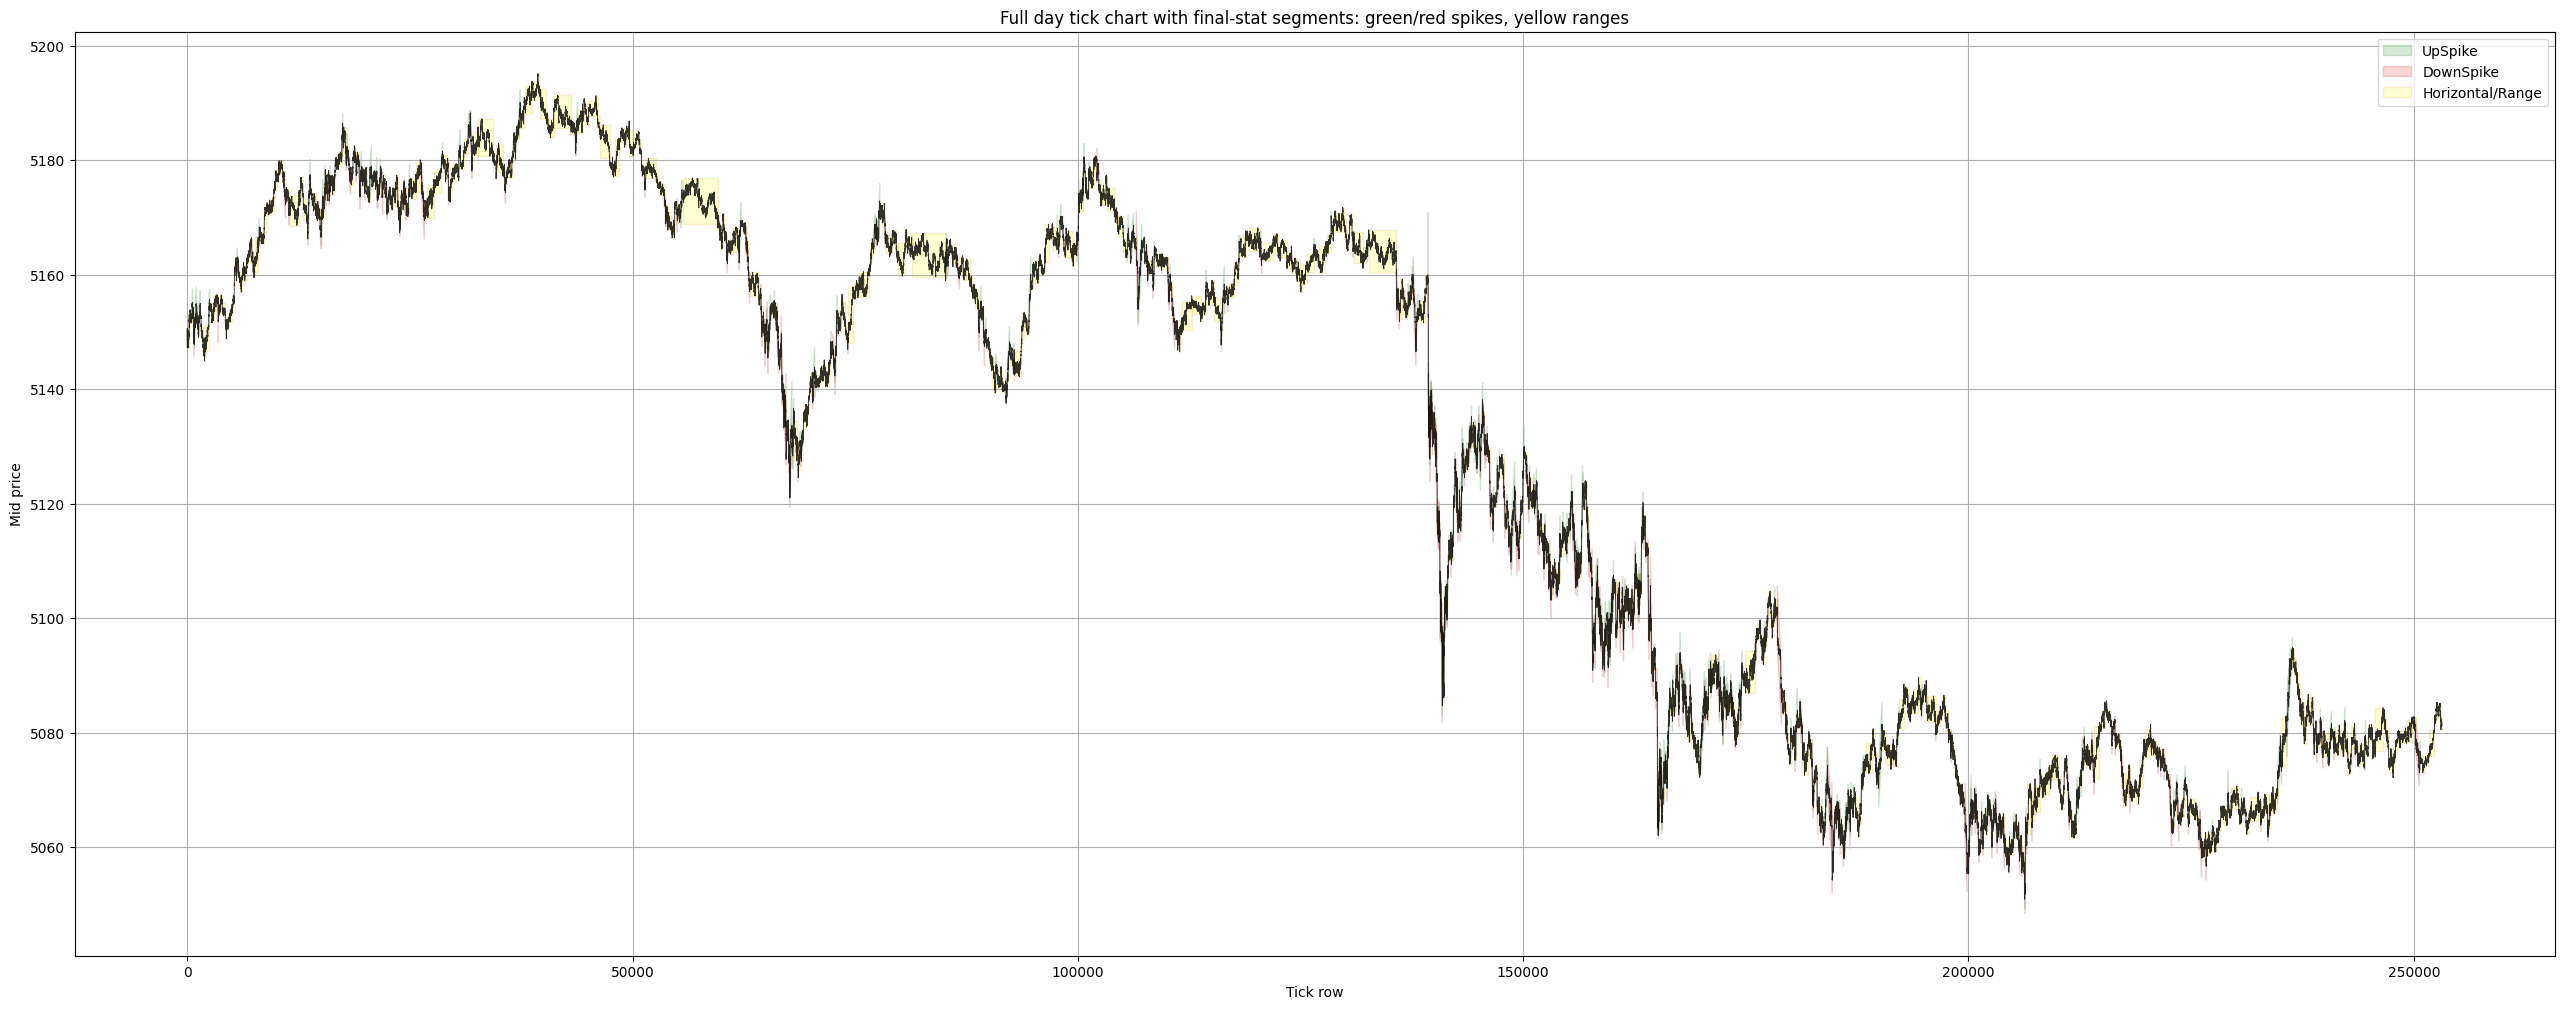

In [18]:
# ============================================================
# Step 10: final-stat reclassification + full tick chart overlay
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Patch

# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
if "ThreeClassSegmentDf" not in globals():
    raise ValueError("ThreeClassSegmentDf not found. Run the previous segment-building cell first.")

if "RunSummaryDf" not in globals():
    raise ValueError("RunSummaryDf not found.")

if "PaDf" not in globals():
    raise ValueError("PaDf not found.")

# ------------------------------------------------------------
# Visible, final-only classification rules
# ------------------------------------------------------------
SpikeMoveThreshold = 2.0
SpikeEfficiencyThreshold = 0.18

FinalSegmentDf = ThreeClassSegmentDf.copy().sort_values("SegmentId").reset_index(drop=True)

FinalSegmentDf["FinalClass"] = np.select(
    [
        (FinalSegmentDf["NetMove"] >= SpikeMoveThreshold) &
        (FinalSegmentDf["Efficiency"] >= SpikeEfficiencyThreshold),

        (FinalSegmentDf["NetMove"] <= -SpikeMoveThreshold) &
        (FinalSegmentDf["Efficiency"] >= SpikeEfficiencyThreshold),
    ],
    [
        "UpSpike",
        "DownSpike",
    ],
    default="Horizontal"
)

print("Final-only classification thresholds:")
print("SpikeMoveThreshold       =", SpikeMoveThreshold)
print("SpikeEfficiencyThreshold =", SpikeEfficiencyThreshold)
print()

print("Final class counts:")
display(
    FinalSegmentDf["FinalClass"]
    .value_counts()
    .rename_axis("FinalClass")
    .reset_index(name="Count")
)

print()
print("Statistics by final class:")
display(
    FinalSegmentDf.groupby("FinalClass").agg(
        SegmentCount=("SegmentId", "size"),
        MedianRunCount=("RunCount", "median"),
        P95RunCount=("RunCount", lambda s: s.quantile(0.95)),
        MedianTickCount=("TickCount", "median"),
        P95TickCount=("TickCount", lambda s: s.quantile(0.95)),
        MedianDurationSec=("DurationSec", "median"),
        P95DurationSec=("DurationSec", lambda s: s.quantile(0.95)),
        MedianAbsNetMove=("AbsNetMove", "median"),
        P95AbsNetMove=("AbsNetMove", lambda s: s.quantile(0.95)),
        MedianEfficiency=("Efficiency", "median"),
        P95Efficiency=("Efficiency", lambda s: s.quantile(0.95)),
    ).reset_index()
)

print()
print("First 30 final-classified segments:")
display(
    FinalSegmentDf[
        [
            "SegmentId", "FinalClass",
            "RunCount", "TickCount", "DurationSec",
            "NetMove", "AbsNetMove", "SumAbsMidDelta", "Efficiency",
            "StartTime", "EndTime",
            "OpenMid", "HighMid", "LowMid", "CloseMid",
        ]
    ].head(30)
)

# ------------------------------------------------------------
# Build run lookup from RunSummaryDf
# ------------------------------------------------------------
RunLookupDf = RunSummaryDf.copy().sort_values("RunSeq").reset_index(drop=True)

if "RunSeq" not in RunLookupDf.columns:
    RunLookupDf["RunSeq"] = np.arange(len(RunLookupDf), dtype=int)

# ------------------------------------------------------------
# Attach tick-row boundaries to each final segment
# ------------------------------------------------------------
StartRows = []
EndRows = []
TickHighs = []
TickLows = []

for _, SegRow in FinalSegmentDf.iterrows():
    StartRunSeq = int(SegRow["StartRunSeq"])
    EndRunSeq = int(SegRow["EndRunSeq"])

    RunSliceDf = RunLookupDf.loc[
        (RunLookupDf["RunSeq"] >= StartRunSeq) &
        (RunLookupDf["RunSeq"] <= EndRunSeq)
    ].copy()

    StartRow = int(RunSliceDf["StartRow"].min())
    EndRow = int(RunSliceDf["EndRow"].max())

    TickSliceDf = PaDf.iloc[StartRow:EndRow + 1]
    TickLow = float(TickSliceDf["Mid"].min())
    TickHigh = float(TickSliceDf["Mid"].max())

    StartRows.append(StartRow)
    EndRows.append(EndRow)
    TickHighs.append(TickHigh)
    TickLows.append(TickLow)

FinalSegmentDf["StartRow"] = StartRows
FinalSegmentDf["EndRow"] = EndRows
FinalSegmentDf["TickLow"] = TickLows
FinalSegmentDf["TickHigh"] = TickHighs

# ------------------------------------------------------------
# Plot all ticks + overlays
# ------------------------------------------------------------
FullX = PaDf["RowNumber"].values
FullY = PaDf["Mid"].values

fig, ax = plt.subplots(figsize=(32, 12))

# all ticks of the day
ax.plot(FullX, FullY, linewidth=0.6, color="black", alpha=0.8)

MedianSpread = float(PaDf["Spread"].median())
BasePad = max(0.05, MedianSpread * 0.5)

for _, SegRow in FinalSegmentDf.iterrows():
    X0 = int(SegRow["StartRow"])
    X1 = int(SegRow["EndRow"])
    if X1 <= X0:
        X1 = X0 + 1

    OpenPrice = float(SegRow["OpenMid"])
    ClosePrice = float(SegRow["CloseMid"])
    TickLow = float(SegRow["TickLow"])
    TickHigh = float(SegRow["TickHigh"])
    SegmentClass = SegRow["FinalClass"]

    TickSliceDf = PaDf.iloc[X0:X1 + 1]
    LocalX = TickSliceDf["RowNumber"].values.astype(float)
    LocalY = TickSliceDf["Mid"].values.astype(float)

    if SegmentClass == "Horizontal":
        Height = max(TickHigh - TickLow, 0.02)
        Rect = Rectangle(
            (X0, TickLow),
            X1 - X0,
            Height,
            facecolor="yellow",
            edgecolor="goldenrod",
            alpha=0.18,
            linewidth=1.0
        )
        ax.add_patch(Rect)

    else:
        # Slanted enclosing quadrilateral around the ticks of the spike
        if X1 == X0:
            Expected = np.full_like(LocalY, OpenPrice)
        else:
            Expected = OpenPrice + (ClosePrice - OpenPrice) * ((LocalX - X0) / (X1 - X0))

        Residual = LocalY - Expected
        UpperResid = float(np.max(Residual)) if len(Residual) else 0.0
        LowerResid = float(np.min(Residual)) if len(Residual) else 0.0

        Pad = max(BasePad, 0.08 * max(TickHigh - TickLow, BasePad))

        Y0Low = OpenPrice + LowerResid - Pad
        Y0High = OpenPrice + UpperResid + Pad
        Y1High = ClosePrice + UpperResid + Pad
        Y1Low = ClosePrice + LowerResid - Pad

        PolyPts = [
            (X0, Y0Low),
            (X0, Y0High),
            (X1, Y1High),
            (X1, Y1Low),
        ]

        FaceColor = "green" if SegmentClass == "UpSpike" else "red"
        EdgeColor = "darkgreen" if SegmentClass == "UpSpike" else "darkred"

        Poly = Polygon(
            PolyPts,
            closed=True,
            facecolor=FaceColor,
            edgecolor=EdgeColor,
            alpha=0.16,
            linewidth=1.0
        )
        ax.add_patch(Poly)

ax.set_title("Full day tick chart with final-stat segments: green/red spikes, yellow ranges")
ax.set_xlabel("Tick row")
ax.set_ylabel("Mid price")

LegendHandles = [
    Patch(facecolor="green", edgecolor="darkgreen", alpha=0.16, label="UpSpike"),
    Patch(facecolor="red", edgecolor="darkred", alpha=0.16, label="DownSpike"),
    Patch(facecolor="yellow", edgecolor="goldenrod", alpha=0.18, label="Horizontal/Range"),
]
ax.legend(handles=LegendHandles, loc="upper right")

plt.show()

Tick window: 0 to 5000
Ticks in window: 5001
Segments touching window: 43


,SegmentId,FinalClass,StartRow,EndRow,RunCount,TickCount,DurationSec,NetMove,Efficiency,OpenMid,HighMid,LowMid,CloseMid
0,1,Horizontal,1,206,111,206,71.703,1.76,0.040073,5149.24,5151.01,5147.22,5151.00
1,2,Horizontal,207,225,9,19,4.237,0.76,0.170787,5151.35,5153.04,5151.35,5152.11
2,3,Horizontal,226,310,47,85,26.330,1.85,0.155071,5151.19,5153.23,5150.80,5153.04
3,4,Horizontal,311,363,27,53,18.822,0.11,0.017378,5153.28,5153.83,5153.15,5153.39
4,5,Horizontal,364,535,87,172,79.533,-0.71,0.039821,5153.15,5153.16,5151.55,5152.44
5,6,UpSpike,536,596,29,61,23.297,2.53,0.285876,5152.60,5155.13,5152.60,5155.13
6,7,Horizontal,609,697,40,89,36.137,-1.31,0.105560,5154.43,5154.43,5152.74,5153.12
7,8,DownSpike,698,744,21,47,17.835,-4.97,0.609069,5152.89,5152.89,5147.92,5147.92
8,9,UpSpike,768,778,3,11,2.955,2.11,0.817829,5148.48,5150.59,5148.48,5150.59
9,10,UpSpike,802,1008,102,207,64.926,5.80,0.190102,5149.11,5154.91,5147.82,5154.91


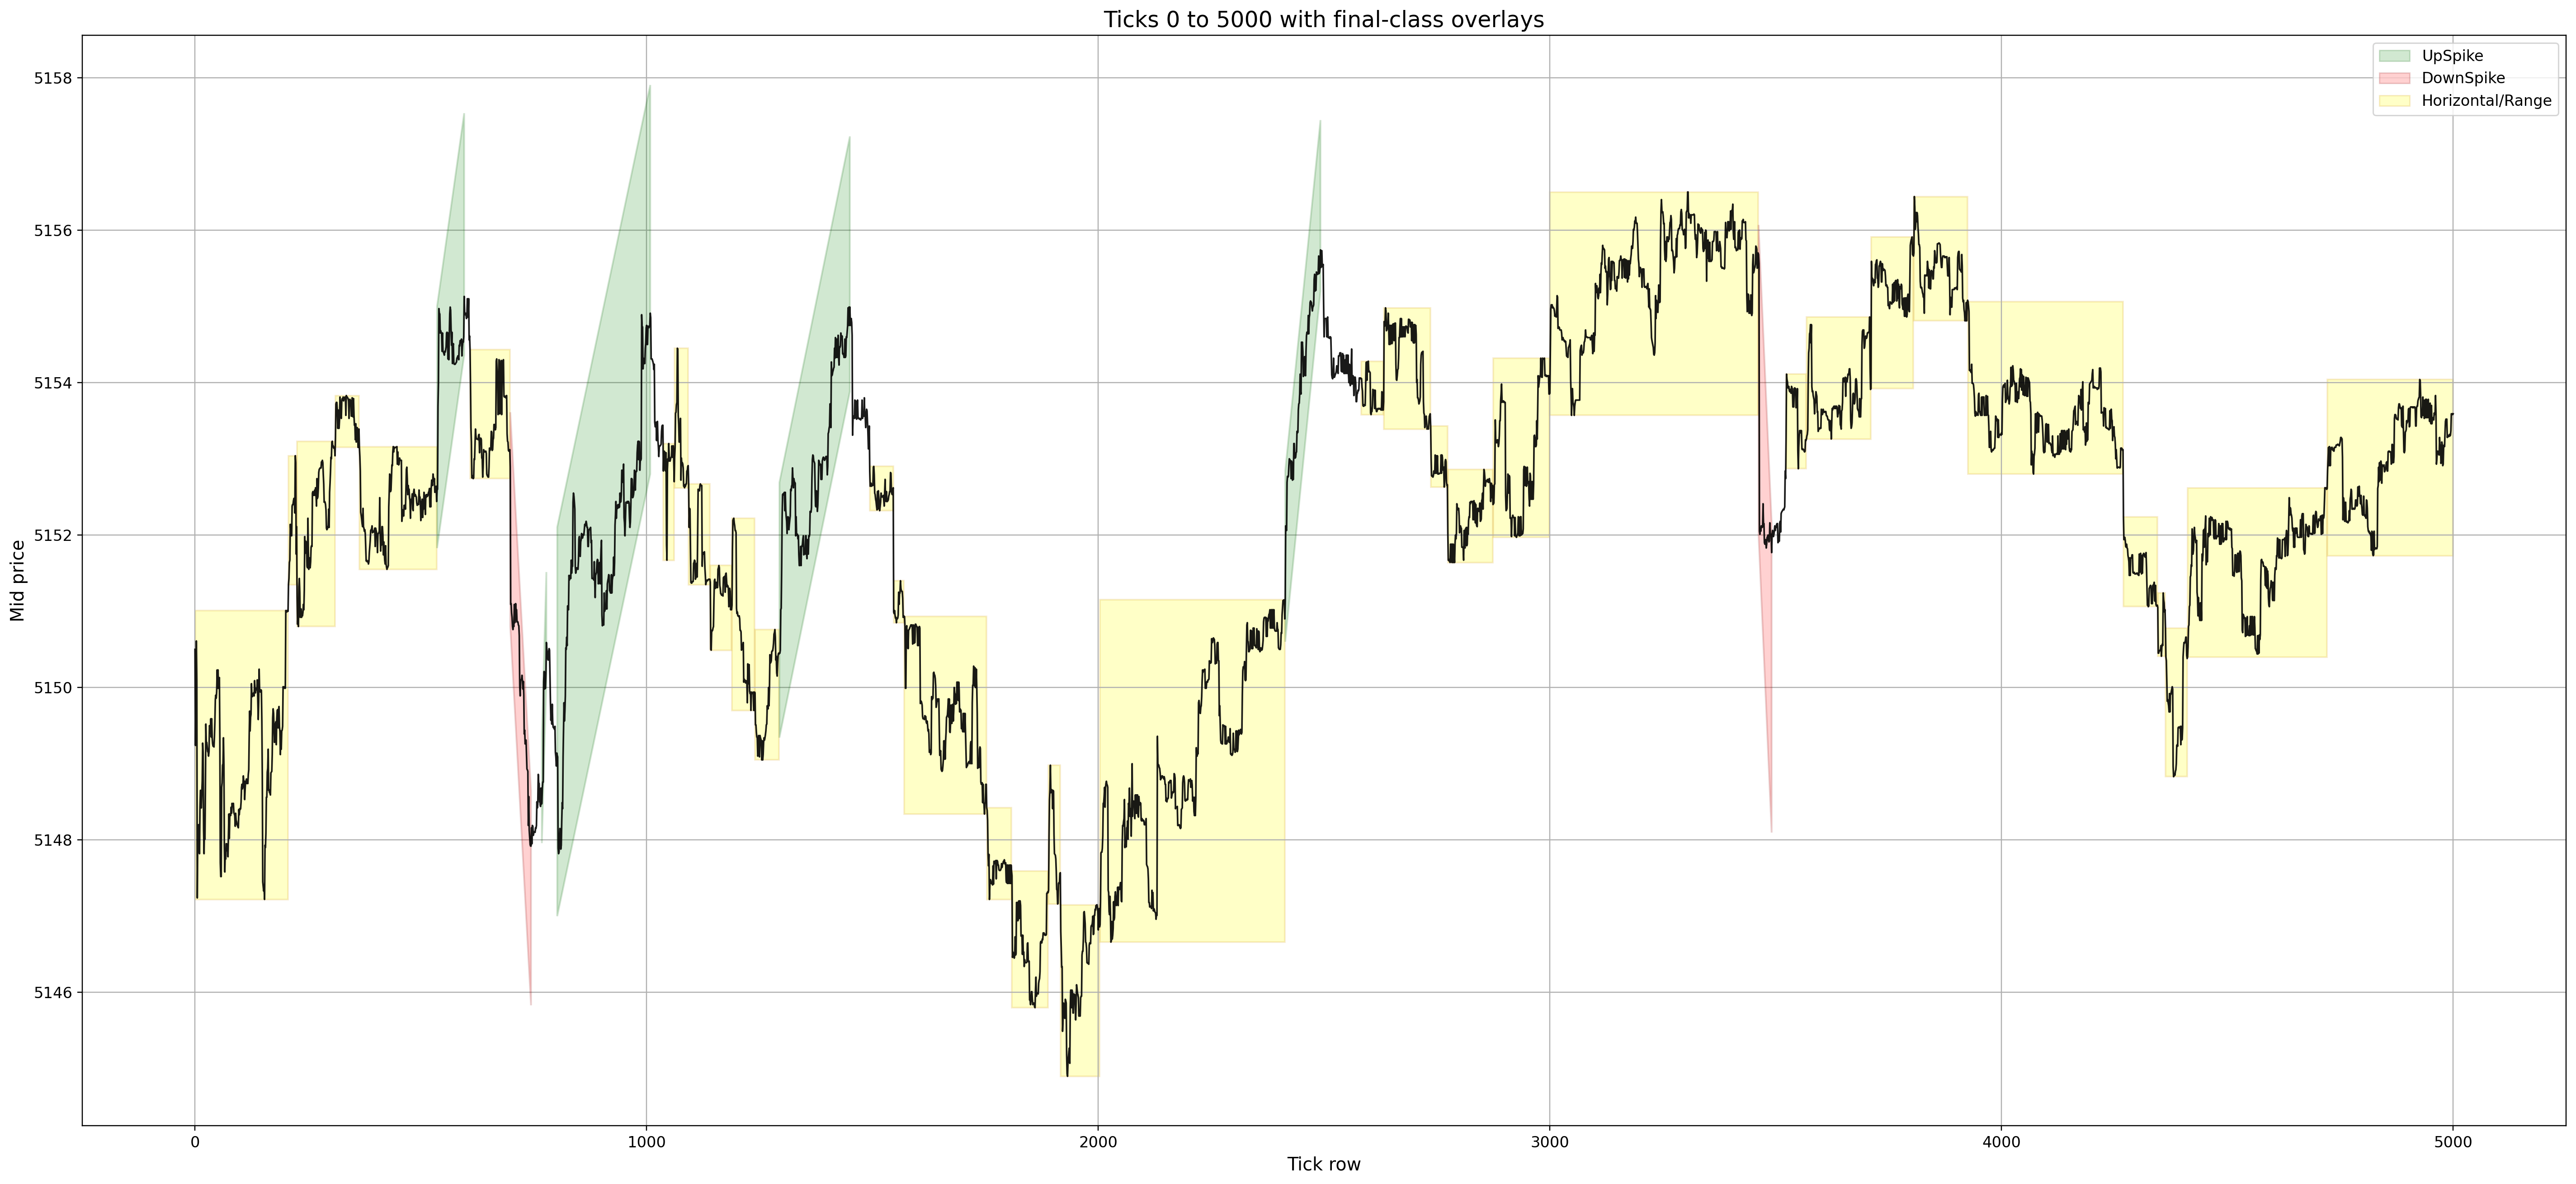

In [20]:
# ============================================================
# Step 11: zoomed high-DPI view of first 500 ticks
# with final-class overlays
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Patch

if "FinalSegmentDf" not in globals():
    raise ValueError("FinalSegmentDf not found. Run the final-only classification cell first.")

if "PaDf" not in globals():
    raise ValueError("PaDf not found.")

TickStart = 0
TickEnd = 5000

ZoomTickDf = PaDf.loc[
    (PaDf["RowNumber"] >= TickStart) &
    (PaDf["RowNumber"] <= TickEnd)
].copy()

ZoomSegmentDf = FinalSegmentDf.loc[
    (FinalSegmentDf["EndRow"] >= TickStart) &
    (FinalSegmentDf["StartRow"] <= TickEnd)
].copy().reset_index(drop=True)

print("Tick window:", TickStart, "to", TickEnd)
print("Ticks in window:", len(ZoomTickDf))
print("Segments touching window:", len(ZoomSegmentDf))

display(
    ZoomSegmentDf[
        [
            "SegmentId", "FinalClass",
            "StartRow", "EndRow",
            "RunCount", "TickCount",
            "DurationSec", "NetMove", "Efficiency",
            "OpenMid", "HighMid", "LowMid", "CloseMid"
        ]
    ]
)

fig, ax = plt.subplots(figsize=(26, 12), dpi=220)

# raw tick path
ax.plot(
    ZoomTickDf["RowNumber"],
    ZoomTickDf["Mid"],
    linewidth=1.2,
    color="black",
    alpha=0.9,
    zorder=3
)

MedianSpread = float(PaDf["Spread"].median())
BasePad = max(0.05, MedianSpread * 0.5)

for _, SegRow in ZoomSegmentDf.iterrows():
    X0 = max(int(SegRow["StartRow"]), TickStart)
    X1 = min(int(SegRow["EndRow"]), TickEnd)

    if X1 <= X0:
        continue

    SegmentClass = SegRow["FinalClass"]

    TickSliceDf = PaDf.loc[
        (PaDf["RowNumber"] >= X0) &
        (PaDf["RowNumber"] <= X1)
    ].copy()

    if len(TickSliceDf) == 0:
        continue

    LocalX = TickSliceDf["RowNumber"].values.astype(float)
    LocalY = TickSliceDf["Mid"].values.astype(float)

    OpenPrice = float(TickSliceDf["Mid"].iloc[0])
    ClosePrice = float(TickSliceDf["Mid"].iloc[-1])
    TickLow = float(TickSliceDf["Mid"].min())
    TickHigh = float(TickSliceDf["Mid"].max())

    if SegmentClass == "Horizontal":
        Rect = Rectangle(
            (X0, TickLow),
            max(X1 - X0, 1),
            max(TickHigh - TickLow, 0.02),
            facecolor="yellow",
            edgecolor="goldenrod",
            alpha=0.22,
            linewidth=1.2,
            zorder=1
        )
        ax.add_patch(Rect)

    else:
        if X1 == X0:
            Expected = np.full_like(LocalY, OpenPrice)
        else:
            Expected = OpenPrice + (ClosePrice - OpenPrice) * ((LocalX - X0) / (X1 - X0))

        Residual = LocalY - Expected
        UpperResid = float(np.max(Residual)) if len(Residual) else 0.0
        LowerResid = float(np.min(Residual)) if len(Residual) else 0.0

        Pad = max(BasePad, 0.08 * max(TickHigh - TickLow, BasePad))

        Y0Low = OpenPrice + LowerResid - Pad
        Y0High = OpenPrice + UpperResid + Pad
        Y1High = ClosePrice + UpperResid + Pad
        Y1Low = ClosePrice + LowerResid - Pad

        FaceColor = "green" if SegmentClass == "UpSpike" else "red"
        EdgeColor = "darkgreen" if SegmentClass == "UpSpike" else "darkred"

        Poly = Polygon(
            [(X0, Y0Low), (X0, Y0High), (X1, Y1High), (X1, Y1Low)],
            closed=True,
            facecolor=FaceColor,
            edgecolor=EdgeColor,
            alpha=0.18,
            linewidth=1.3,
            zorder=2
        )
        ax.add_patch(Poly)

ax.set_title(f"Ticks {TickStart} to {TickEnd} with final-class overlays", fontsize=16)
ax.set_xlabel("Tick row", fontsize=13)
ax.set_ylabel("Mid price", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

LegendHandles = [
    Patch(facecolor="green", edgecolor="darkgreen", alpha=0.18, label="UpSpike"),
    Patch(facecolor="red", edgecolor="darkred", alpha=0.18, label="DownSpike"),
    Patch(facecolor="yellow", edgecolor="goldenrod", alpha=0.22, label="Horizontal/Range"),
]
ax.legend(handles=LegendHandles, loc="upper right", fontsize=11)

plt.tight_layout()
plt.show()

Swing reversal threshold: 1.0
Confirmed swing count: 5376
Confirmed leg count: 5375

Swing counts by type:


,SwingLabel,Count
0,SwingHigh,2688
1,SwingLow,2688



Leg statistics:


,Metric,Value
0,MedianAbsNetMove,1.950000
1,P95AbsNetMove,5.113000
2,MedianTickCount,33.000000
3,P95TickCount,143.000000
4,MedianDurationSec,8.895000
5,P95DurationSec,51.922700
6,MedianEfficiency,0.488818
7,P95Efficiency,1.000000



First 20 swing points:


,SwingId,SwingLabel,RowNumber,TickId,Time,Price,IsTerminal
0,1,SwingHigh,0,35884041,2026-03-05 10:01:00.512000+11:00,5150.50,False
1,2,SwingLow,1,35884042,2026-03-05 10:01:00.741000+11:00,5149.24,False
2,3,SwingHigh,3,35884044,2026-03-05 10:01:01.224000+11:00,5150.61,False
3,4,SwingLow,5,35884046,2026-03-05 10:01:01.752000+11:00,5147.24,False
4,5,SwingHigh,17,35884058,2026-03-05 10:01:04.768000+11:00,5149.27,False
5,6,SwingLow,20,35884061,2026-03-05 10:01:05.446000+11:00,5147.82,False
6,7,SwingHigh,51,35884092,2026-03-05 10:01:14.842000+11:00,5150.23,False
7,8,SwingLow,58,35884099,2026-03-05 10:01:16.503000+11:00,5147.52,False
8,9,SwingHigh,63,35884104,2026-03-05 10:01:18.322000+11:00,5149.34,False
9,10,SwingLow,66,35884107,2026-03-05 10:01:19+11:00,5147.58,False



First 20 swing legs:


,LegId,LegDirection,StartSwingId,EndSwingId,StartRow,EndRow,StartTime,EndTime,OpenMid,HighMid,LowMid,CloseMid,NetMove,TickCount,DurationSec,Efficiency
0,1,DownLeg,1,2,0,1,2026-03-05 10:01:00.512000+11:00,2026-03-05 10:01:00.741000+11:00,5150.50,5150.50,5149.24,5149.24,-1.26,2,0.229,1.000000
1,2,UpLeg,2,3,1,3,2026-03-05 10:01:00.741000+11:00,2026-03-05 10:01:01.224000+11:00,5149.24,5150.61,5149.24,5150.61,1.37,3,0.483,1.000000
2,3,DownLeg,3,4,3,5,2026-03-05 10:01:01.224000+11:00,2026-03-05 10:01:01.752000+11:00,5150.61,5150.61,5147.24,5147.24,-3.37,3,0.528,1.000000
3,4,UpLeg,4,5,5,17,2026-03-05 10:01:01.752000+11:00,2026-03-05 10:01:04.768000+11:00,5147.24,5149.27,5147.24,5149.27,2.03,13,3.016,0.571831
4,5,DownLeg,5,6,17,20,2026-03-05 10:01:04.768000+11:00,2026-03-05 10:01:05.446000+11:00,5149.27,5149.27,5147.82,5147.82,-1.45,4,0.678,1.000000
5,6,UpLeg,6,7,20,51,2026-03-05 10:01:05.446000+11:00,2026-03-05 10:01:14.842000+11:00,5147.82,5150.23,5147.82,5150.23,2.41,32,9.396,0.428064
6,7,DownLeg,7,8,51,58,2026-03-05 10:01:14.842000+11:00,2026-03-05 10:01:16.503000+11:00,5150.23,5150.23,5147.52,5147.52,-2.71,8,1.661,0.906355
7,8,UpLeg,8,9,58,63,2026-03-05 10:01:16.503000+11:00,2026-03-05 10:01:18.322000+11:00,5147.52,5149.34,5147.52,5149.34,1.82,6,1.819,1.000000
8,9,DownLeg,9,10,63,66,2026-03-05 10:01:18.322000+11:00,2026-03-05 10:01:19+11:00,5149.34,5149.34,5147.58,5147.58,-1.76,4,0.678,1.000000
9,10,UpLeg,10,11,66,142,2026-03-05 10:01:19+11:00,2026-03-05 10:01:49.166000+11:00,5147.58,5150.24,5147.58,5150.24,2.66,77,30.166,0.309302


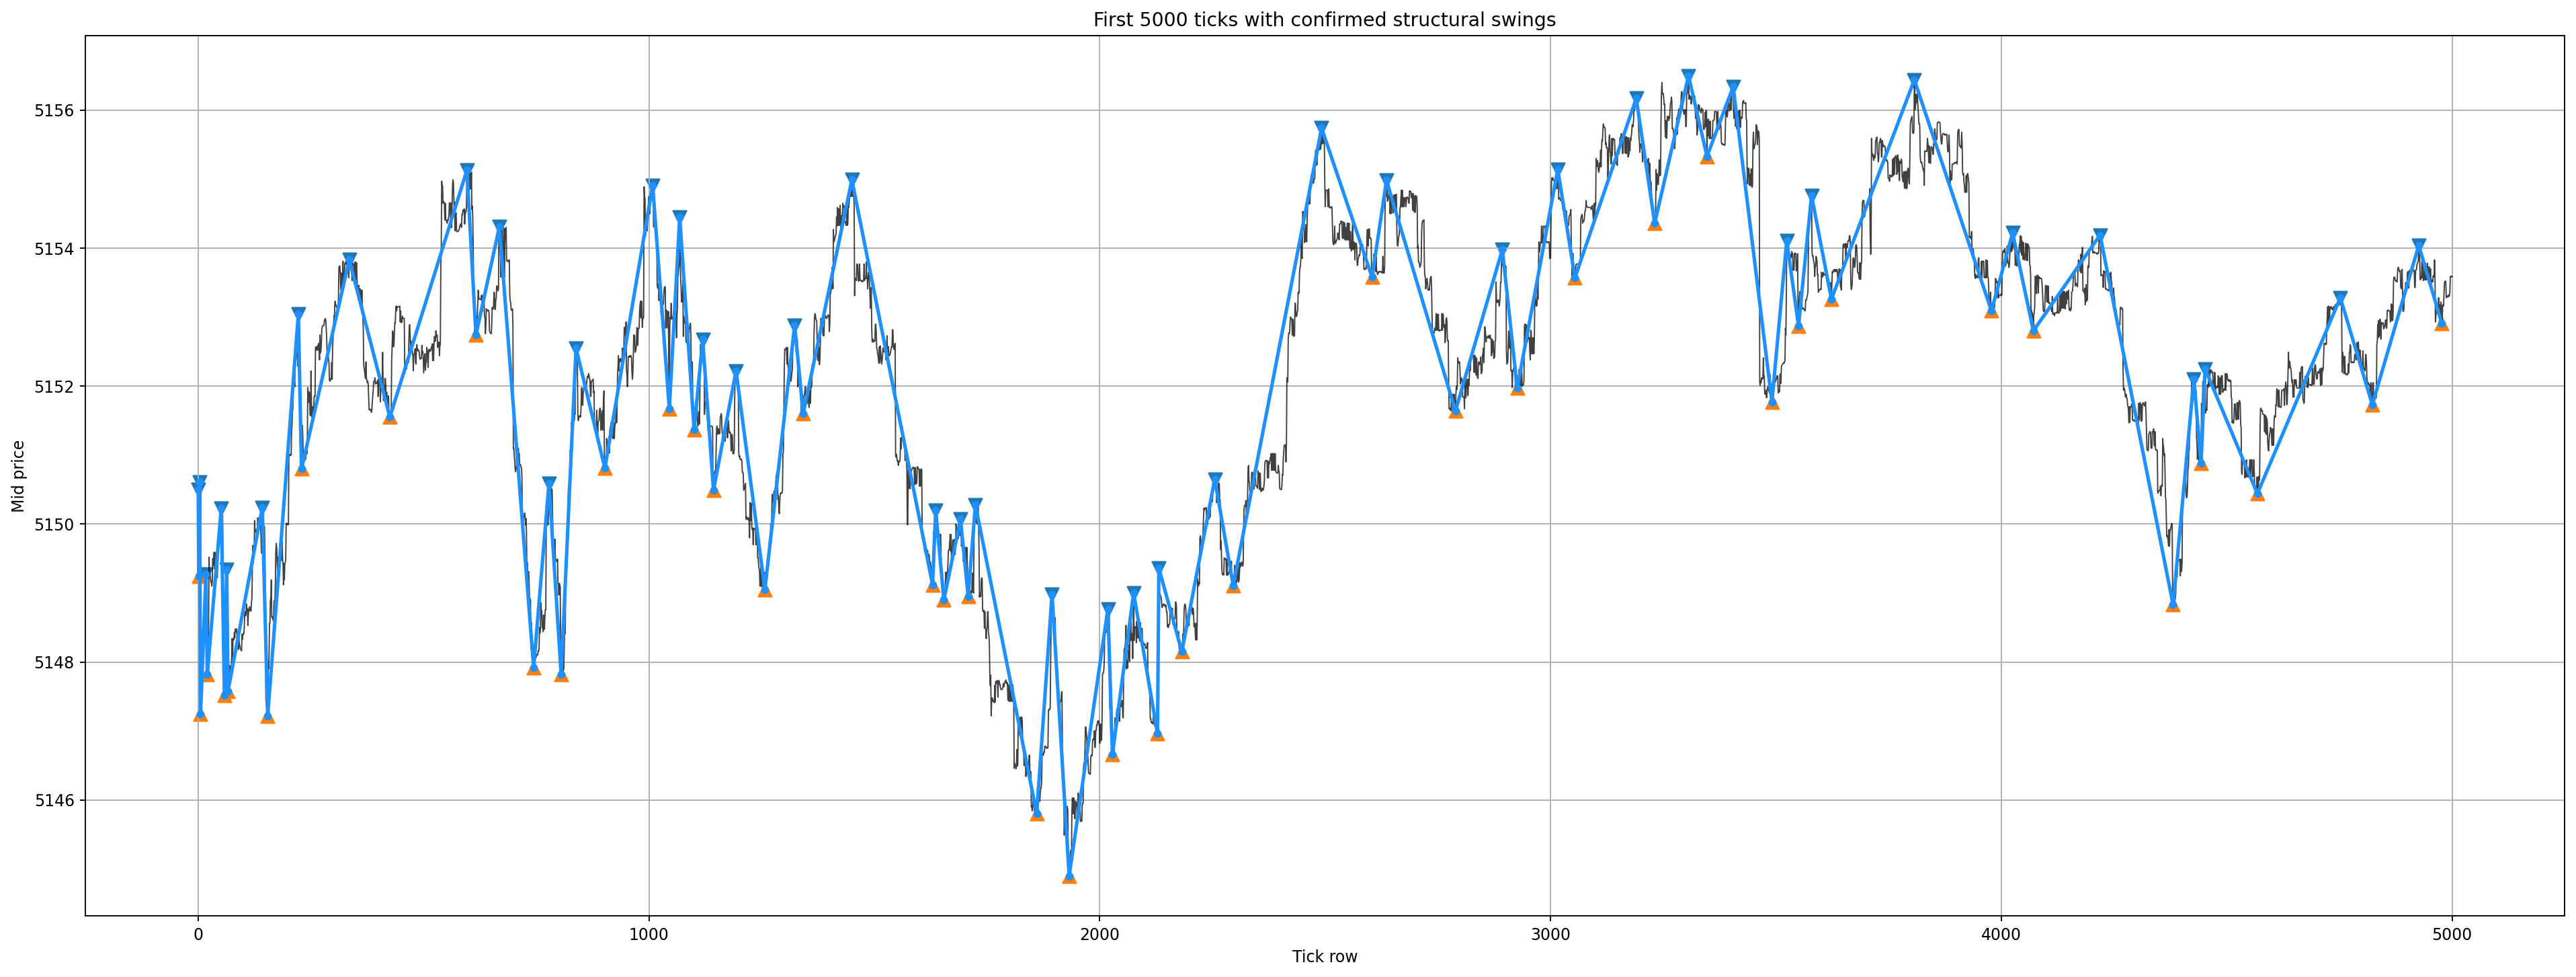

In [21]:
# ============================================================
# Step 1: confirmed structural swings + swing legs
# price-action backbone from raw ticks
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "PaDf" not in globals():
    raise ValueError("PaDf not found.")

SwingReversal = 1.0
PriceCol = "Mid"

PriceDf = PaDf[["RowNumber", "TickId", "Time", "Mid"]].copy().reset_index(drop=True)
Prices = PriceDf[PriceCol].to_numpy()

if len(PriceDf) < 3:
    raise ValueError("Not enough ticks to build swings.")

# ------------------------------------------------------------
# 1) Find the first meaningful directional move
# ------------------------------------------------------------
LowIdx = 0
HighIdx = 0
LowPrice = float(Prices[0])
HighPrice = float(Prices[0])

Direction = None
ExtremeIdx = None
ExtremePrice = None
StartScanIdx = None

SwingRows = []

for i in range(1, len(Prices)):
    Price = float(Prices[i])

    if Price <= LowPrice:
        LowPrice = Price
        LowIdx = i

    if Price >= HighPrice:
        HighPrice = Price
        HighIdx = i

    if HighPrice - LowPrice >= SwingReversal:
        if LowIdx < HighIdx:
            # first confirmed structural point is a Low
            SwingRows.append({
                "SwingType": "Low",
                "RowNumber": int(PriceDf.loc[LowIdx, "RowNumber"]),
                "TickId": int(PriceDf.loc[LowIdx, "TickId"]),
                "Time": PriceDf.loc[LowIdx, "Time"],
                "Price": float(PriceDf.loc[LowIdx, "Mid"]),
                "IsTerminal": False,
            })
            Direction = "Up"
            ExtremeIdx = HighIdx
            ExtremePrice = HighPrice
        else:
            # first confirmed structural point is a High
            SwingRows.append({
                "SwingType": "High",
                "RowNumber": int(PriceDf.loc[HighIdx, "RowNumber"]),
                "TickId": int(PriceDf.loc[HighIdx, "TickId"]),
                "Time": PriceDf.loc[HighIdx, "Time"],
                "Price": float(PriceDf.loc[HighIdx, "Mid"]),
                "IsTerminal": False,
            })
            Direction = "Down"
            ExtremeIdx = LowIdx
            ExtremePrice = LowPrice

        StartScanIdx = i + 1
        break

if Direction is None:
    raise ValueError(
        f"No directional move of at least {SwingReversal:.2f} was found in this dataset."
    )

# ------------------------------------------------------------
# 2) Walk forward and confirm swings on reversal
# ------------------------------------------------------------
for i in range(StartScanIdx, len(Prices)):
    Price = float(Prices[i])

    if Direction == "Up":
        if Price >= ExtremePrice:
            ExtremePrice = Price
            ExtremeIdx = i
        elif ExtremePrice - Price >= SwingReversal:
            SwingRows.append({
                "SwingType": "High",
                "RowNumber": int(PriceDf.loc[ExtremeIdx, "RowNumber"]),
                "TickId": int(PriceDf.loc[ExtremeIdx, "TickId"]),
                "Time": PriceDf.loc[ExtremeIdx, "Time"],
                "Price": float(PriceDf.loc[ExtremeIdx, "Mid"]),
                "IsTerminal": False,
            })
            Direction = "Down"
            ExtremeIdx = i
            ExtremePrice = Price

    elif Direction == "Down":
        if Price <= ExtremePrice:
            ExtremePrice = Price
            ExtremeIdx = i
        elif Price - ExtremePrice >= SwingReversal:
            SwingRows.append({
                "SwingType": "Low",
                "RowNumber": int(PriceDf.loc[ExtremeIdx, "RowNumber"]),
                "TickId": int(PriceDf.loc[ExtremeIdx, "TickId"]),
                "Time": PriceDf.loc[ExtremeIdx, "Time"],
                "Price": float(PriceDf.loc[ExtremeIdx, "Mid"]),
                "IsTerminal": False,
            })
            Direction = "Up"
            ExtremeIdx = i
            ExtremePrice = Price

# ------------------------------------------------------------
# 3) Append the last visible extreme as terminal swing
# ------------------------------------------------------------
TerminalSwingType = "High" if Direction == "Up" else "Low"

TerminalRow = {
    "SwingType": TerminalSwingType,
    "RowNumber": int(PriceDf.loc[ExtremeIdx, "RowNumber"]),
    "TickId": int(PriceDf.loc[ExtremeIdx, "TickId"]),
    "Time": PriceDf.loc[ExtremeIdx, "Time"],
    "Price": float(PriceDf.loc[ExtremeIdx, "Mid"]),
    "IsTerminal": True,
}

if len(SwingRows) == 0 or (
    SwingRows[-1]["RowNumber"] != TerminalRow["RowNumber"] or
    SwingRows[-1]["SwingType"] != TerminalRow["SwingType"]
):
    SwingRows.append(TerminalRow)
else:
    SwingRows[-1]["IsTerminal"] = True

SwingPointDf = pd.DataFrame(SwingRows).sort_values("RowNumber").reset_index(drop=True)
SwingPointDf["SwingId"] = np.arange(1, len(SwingPointDf) + 1, dtype=int)
SwingPointDf["SwingLabel"] = np.where(
    SwingPointDf["SwingType"] == "High",
    "SwingHigh",
    "SwingLow"
)

# ------------------------------------------------------------
# 4) Build legs between adjacent swings
# ------------------------------------------------------------
LegRows = []

for j in range(len(SwingPointDf) - 1):
    A = SwingPointDf.iloc[j]
    B = SwingPointDf.iloc[j + 1]

    StartRow = int(A["RowNumber"])
    EndRow = int(B["RowNumber"])

    TickSliceDf = PaDf.loc[
        (PaDf["RowNumber"] >= StartRow) &
        (PaDf["RowNumber"] <= EndRow)
    ].copy()

    if len(TickSliceDf) < 2:
        continue

    OpenMid = float(TickSliceDf["Mid"].iloc[0])
    CloseMid = float(TickSliceDf["Mid"].iloc[-1])
    HighMid = float(TickSliceDf["Mid"].max())
    LowMid = float(TickSliceDf["Mid"].min())

    NetMove = CloseMid - OpenMid
    AbsNetMove = abs(NetMove)

    SumAbsMidDelta = float(TickSliceDf["Mid"].diff().abs().fillna(0).sum())
    Efficiency = AbsNetMove / SumAbsMidDelta if SumAbsMidDelta > 0 else np.nan

    DurationSec = float((B["Time"] - A["Time"]).total_seconds())
    MovePerSecond = NetMove / DurationSec if DurationSec > 0 else np.nan

    LegRows.append({
        "LegId": j + 1,
        "StartSwingId": int(A["SwingId"]),
        "EndSwingId": int(B["SwingId"]),
        "LegDirection": "UpLeg" if NetMove > 0 else "DownLeg",
        "StartRow": StartRow,
        "EndRow": EndRow,
        "StartTickId": int(A["TickId"]),
        "EndTickId": int(B["TickId"]),
        "StartTime": A["Time"],
        "EndTime": B["Time"],
        "OpenMid": OpenMid,
        "HighMid": HighMid,
        "LowMid": LowMid,
        "CloseMid": CloseMid,
        "NetMove": NetMove,
        "AbsNetMove": AbsNetMove,
        "TickCount": int(len(TickSliceDf)),
        "DurationSec": DurationSec,
        "MovePerSecond": MovePerSecond,
        "SumAbsMidDelta": SumAbsMidDelta,
        "Efficiency": Efficiency,
    })

SwingLegDf = pd.DataFrame(LegRows)

# ------------------------------------------------------------
# 5) Output
# ------------------------------------------------------------
print("Swing reversal threshold:", SwingReversal)
print("Confirmed swing count:", len(SwingPointDf))
print("Confirmed leg count:", len(SwingLegDf))
print()

print("Swing counts by type:")
display(
    SwingPointDf["SwingLabel"]
    .value_counts()
    .rename_axis("SwingLabel")
    .reset_index(name="Count")
)

print()
print("Leg statistics:")
display(
    pd.DataFrame({
        "Metric": [
            "MedianAbsNetMove",
            "P95AbsNetMove",
            "MedianTickCount",
            "P95TickCount",
            "MedianDurationSec",
            "P95DurationSec",
            "MedianEfficiency",
            "P95Efficiency",
        ],
        "Value": [
            SwingLegDf["AbsNetMove"].median(),
            SwingLegDf["AbsNetMove"].quantile(0.95),
            SwingLegDf["TickCount"].median(),
            SwingLegDf["TickCount"].quantile(0.95),
            SwingLegDf["DurationSec"].median(),
            SwingLegDf["DurationSec"].quantile(0.95),
            SwingLegDf["Efficiency"].median(),
            SwingLegDf["Efficiency"].quantile(0.95),
        ]
    })
)

print()
print("First 20 swing points:")
display(
    SwingPointDf[
        ["SwingId", "SwingLabel", "RowNumber", "TickId", "Time", "Price", "IsTerminal"]
    ].head(20)
)

print()
print("First 20 swing legs:")
display(
    SwingLegDf[
        [
            "LegId", "LegDirection", "StartSwingId", "EndSwingId",
            "StartRow", "EndRow",
            "StartTime", "EndTime",
            "OpenMid", "HighMid", "LowMid", "CloseMid",
            "NetMove", "TickCount", "DurationSec", "Efficiency"
        ]
    ].head(20)
)

# ------------------------------------------------------------
# 6) Visual inspection: first window
# ------------------------------------------------------------
ZoomStart = 0
ZoomEnd = min(5000, int(PaDf["RowNumber"].max()))

ZoomTickDf = PaDf.loc[
    (PaDf["RowNumber"] >= ZoomStart) &
    (PaDf["RowNumber"] <= ZoomEnd)
].copy()

ZoomSwingDf = SwingPointDf.loc[
    (SwingPointDf["RowNumber"] >= ZoomStart) &
    (SwingPointDf["RowNumber"] <= ZoomEnd)
].copy()

plt.figure(figsize=(28, 10), dpi=170)
plt.plot(ZoomTickDf["RowNumber"], ZoomTickDf["Mid"], linewidth=0.8, color="black", alpha=0.75)

if len(ZoomSwingDf) > 0:
    plt.plot(
        ZoomSwingDf["RowNumber"],
        ZoomSwingDf["Price"],
        linewidth=2.2,
        color="dodgerblue",
        marker="o",
        markersize=4
    )

    HighDf = ZoomSwingDf.loc[ZoomSwingDf["SwingType"] == "High"]
    LowDf = ZoomSwingDf.loc[ZoomSwingDf["SwingType"] == "Low"]

    plt.scatter(HighDf["RowNumber"], HighDf["Price"], marker="v", s=70)
    plt.scatter(LowDf["RowNumber"], LowDf["Price"], marker="^", s=70)

plt.title(f"First {ZoomEnd} ticks with confirmed structural swings")
plt.xlabel("Tick row")
plt.ylabel("Mid price")
plt.show()

In [22]:
# ============================================================
# Step 2: multi-scale mathematical swing net
# purely numeric structural scan across 12 reversal sizes
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

if "PaDf" not in globals():
    raise ValueError("PaDf not found.")

PriceDf = (
    PaDf[["RowNumber", "TickId", "Time", "Mid"]]
    .copy()
    .sort_values("RowNumber")
    .reset_index(drop=True)
)

PriceDf["Time"] = pd.to_datetime(PriceDf["Time"])
PriceDf["Pos"] = np.arange(len(PriceDf), dtype=int)

if len(PriceDf) < 10:
    raise ValueError("Not enough rows in PaDf.")

# ------------------------------------------------------------
# 12 structural lenses: from noise-scale to large swing-scale
# ------------------------------------------------------------
SwingScaleList = np.array(
    [0.10, 0.15, 0.22, 0.33, 0.50, 0.75, 1.00, 1.50, 2.25, 3.50, 5.00, 10.00],
    dtype=float
)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def ComputeTrendR2(MidArray: np.ndarray) -> float:
    if len(MidArray) < 3:
        return np.nan

    X = np.arange(len(MidArray), dtype=float)
    Y = MidArray.astype(float)

    YMean = Y.mean()
    SsTot = np.sum((Y - YMean) ** 2)
    if SsTot <= 0:
        return 1.0

    Slope, Intercept = np.polyfit(X, Y, 1)
    YHat = Slope * X + Intercept
    SsRes = np.sum((Y - YHat) ** 2)

    R2 = 1.0 - (SsRes / SsTot)
    return float(np.clip(R2, 0.0, 1.0))


def BuildConfirmedSwingsAndLegs(PriceDf: pd.DataFrame, SwingReversal: float):
    Prices = PriceDf["Mid"].to_numpy(dtype=float)
    Count = len(Prices)

    if Count < 3:
        return pd.DataFrame(), pd.DataFrame()

    LowPos = 0
    HighPos = 0
    LowPrice = float(Prices[0])
    HighPrice = float(Prices[0])

    Direction = None
    ExtremePos = None
    ExtremePrice = None
    StartScanPos = None

    SwingRows = []

    # --------------------------------------------------------
    # 1) find first meaningful directional move
    # --------------------------------------------------------
    for i in range(1, Count):
        Price = float(Prices[i])

        if Price <= LowPrice:
            LowPrice = Price
            LowPos = i

        if Price >= HighPrice:
            HighPrice = Price
            HighPos = i

        if HighPrice - LowPrice >= SwingReversal:
            if LowPos < HighPos:
                FirstPos = LowPos
                Direction = "Up"
                ExtremePos = HighPos
                ExtremePrice = HighPrice
                SwingType = "Low"
            else:
                FirstPos = HighPos
                Direction = "Down"
                ExtremePos = LowPos
                ExtremePrice = LowPrice
                SwingType = "High"

            SwingRows.append({
                "SwingReversal": SwingReversal,
                "Pos": int(FirstPos),
                "RowNumber": int(PriceDf.loc[FirstPos, "RowNumber"]),
                "TickId": int(PriceDf.loc[FirstPos, "TickId"]),
                "Time": PriceDf.loc[FirstPos, "Time"],
                "Price": float(PriceDf.loc[FirstPos, "Mid"]),
                "SwingType": SwingType,
                "IsTerminal": False,
            })

            StartScanPos = i + 1
            break

    if Direction is None:
        return pd.DataFrame(), pd.DataFrame()

    # --------------------------------------------------------
    # 2) walk forward and confirm swings on reversal
    # --------------------------------------------------------
    for i in range(StartScanPos, Count):
        Price = float(Prices[i])

        if Direction == "Up":
            if Price >= ExtremePrice:
                ExtremePrice = Price
                ExtremePos = i
            elif ExtremePrice - Price >= SwingReversal:
                SwingRows.append({
                    "SwingReversal": SwingReversal,
                    "Pos": int(ExtremePos),
                    "RowNumber": int(PriceDf.loc[ExtremePos, "RowNumber"]),
                    "TickId": int(PriceDf.loc[ExtremePos, "TickId"]),
                    "Time": PriceDf.loc[ExtremePos, "Time"],
                    "Price": float(PriceDf.loc[ExtremePos, "Mid"]),
                    "SwingType": "High",
                    "IsTerminal": False,
                })
                Direction = "Down"
                ExtremePos = i
                ExtremePrice = Price

        else:  # Direction == "Down"
            if Price <= ExtremePrice:
                ExtremePrice = Price
                ExtremePos = i
            elif Price - ExtremePrice >= SwingReversal:
                SwingRows.append({
                    "SwingReversal": SwingReversal,
                    "Pos": int(ExtremePos),
                    "RowNumber": int(PriceDf.loc[ExtremePos, "RowNumber"]),
                    "TickId": int(PriceDf.loc[ExtremePos, "TickId"]),
                    "Time": PriceDf.loc[ExtremePos, "Time"],
                    "Price": float(PriceDf.loc[ExtremePos, "Mid"]),
                    "SwingType": "Low",
                    "IsTerminal": False,
                })
                Direction = "Up"
                ExtremePos = i
                ExtremePrice = Price

    # --------------------------------------------------------
    # 3) append last visible extreme as terminal swing
    # --------------------------------------------------------
    TerminalType = "High" if Direction == "Up" else "Low"

    TerminalRow = {
        "SwingReversal": SwingReversal,
        "Pos": int(ExtremePos),
        "RowNumber": int(PriceDf.loc[ExtremePos, "RowNumber"]),
        "TickId": int(PriceDf.loc[ExtremePos, "TickId"]),
        "Time": PriceDf.loc[ExtremePos, "Time"],
        "Price": float(PriceDf.loc[ExtremePos, "Mid"]),
        "SwingType": TerminalType,
        "IsTerminal": True,
    }

    if len(SwingRows) == 0:
        SwingRows.append(TerminalRow)
    else:
        LastRow = SwingRows[-1]
        if (LastRow["Pos"] != TerminalRow["Pos"]) or (LastRow["SwingType"] != TerminalRow["SwingType"]):
            SwingRows.append(TerminalRow)
        else:
            SwingRows[-1]["IsTerminal"] = True

    SwingPointDf = pd.DataFrame(SwingRows).sort_values("Pos").reset_index(drop=True)
    SwingPointDf["SwingId"] = np.arange(1, len(SwingPointDf) + 1, dtype=int)
    SwingPointDf["SwingLabel"] = np.where(
        SwingPointDf["SwingType"] == "High",
        "SwingHigh",
        "SwingLow"
    )

    # --------------------------------------------------------
    # 4) build legs between adjacent swings
    # --------------------------------------------------------
    LegRows = []

    for j in range(len(SwingPointDf) - 1):
        A = SwingPointDf.iloc[j]
        B = SwingPointDf.iloc[j + 1]

        StartPos = int(A["Pos"])
        EndPos = int(B["Pos"])

        TickSliceDf = PriceDf.iloc[StartPos:EndPos + 1].copy()
        if len(TickSliceDf) < 2:
            continue

        MidArray = TickSliceDf["Mid"].to_numpy(dtype=float)
        DeltaArray = np.diff(MidArray)
        AbsDeltaArray = np.abs(DeltaArray)

        OpenMid = float(MidArray[0])
        CloseMid = float(MidArray[-1])
        HighMid = float(np.max(MidArray))
        LowMid = float(np.min(MidArray))

        NetMove = CloseMid - OpenMid
        AbsNetMove = abs(NetMove)
        SumAbsMidDelta = float(np.sum(AbsDeltaArray))
        TickCount = int(len(TickSliceDf))
        DurationSec = float((B["Time"] - A["Time"]).total_seconds())

        if NetMove > 0:
            LegDirection = "UpLeg"
            AlignedAbsDelta = float(np.sum(DeltaArray[DeltaArray > 0]))
            AdverseMove = float(max(OpenMid - LowMid, 0.0))
        elif NetMove < 0:
            LegDirection = "DownLeg"
            AlignedAbsDelta = float(np.sum(-DeltaArray[DeltaArray < 0]))
            AdverseMove = float(max(HighMid - OpenMid, 0.0))
        else:
            LegDirection = "FlatLeg"
            AlignedAbsDelta = 0.0
            AdverseMove = float(HighMid - LowMid)

        Efficiency = AbsNetMove / SumAbsMidDelta if SumAbsMidDelta > 0 else np.nan
        DirectionalDeltaShare = AlignedAbsDelta / SumAbsMidDelta if SumAbsMidDelta > 0 else np.nan
        Churn = SumAbsMidDelta - AbsNetMove
        ChurnPerDollar = Churn / max(AbsNetMove, 0.01)
        AbsMovePerSecond = AbsNetMove / DurationSec if DurationSec > 0 else np.nan
        AdverseEfficiency = AbsNetMove / max(AdverseMove, 0.01)
        ThresholdExpansion = AbsNetMove / SwingReversal
        TrendR2 = ComputeTrendR2(MidArray)

        LegRows.append({
            "SwingReversal": SwingReversal,
            "LegId": j + 1,
            "StartSwingId": int(A["SwingId"]),
            "EndSwingId": int(B["SwingId"]),
            "LegDirection": LegDirection,
            "StartPos": StartPos,
            "EndPos": EndPos,
            "StartRowNumber": int(A["RowNumber"]),
            "EndRowNumber": int(B["RowNumber"]),
            "StartTickId": int(A["TickId"]),
            "EndTickId": int(B["TickId"]),
            "StartTime": A["Time"],
            "EndTime": B["Time"],
            "OpenMid": OpenMid,
            "HighMid": HighMid,
            "LowMid": LowMid,
            "CloseMid": CloseMid,
            "NetMove": NetMove,
            "AbsNetMove": AbsNetMove,
            "TickCount": TickCount,
            "DurationSec": DurationSec,
            "AbsMovePerSecond": AbsMovePerSecond,
            "SumAbsMidDelta": SumAbsMidDelta,
            "Churn": Churn,
            "ChurnPerDollar": ChurnPerDollar,
            "Efficiency": Efficiency,
            "DirectionalDeltaShare": DirectionalDeltaShare,
            "AdverseMove": AdverseMove,
            "AdverseEfficiency": AdverseEfficiency,
            "ThresholdExpansion": ThresholdExpansion,
            "TrendR2": TrendR2,
            "IsTerminalEnd": bool(B["IsTerminal"]),
        })

    SwingLegDf = pd.DataFrame(LegRows)
    return SwingPointDf, SwingLegDf


def PercentileRank(Series: pd.Series) -> pd.Series:
    CleanSeries = Series.astype(float).replace([np.inf, -np.inf], np.nan)
    if CleanSeries.notna().sum() == 0:
        return pd.Series(np.zeros(len(CleanSeries)), index=CleanSeries.index)
    FillValue = CleanSeries.min() - 1.0
    return CleanSeries.fillna(FillValue).rank(pct=True, method="average")


# ------------------------------------------------------------
# build all scales
# ------------------------------------------------------------
AllSwingPointList = []
AllSwingLegList = []

for SwingReversal in SwingScaleList:
    SwingPointDf, SwingLegDf = BuildConfirmedSwingsAndLegs(PriceDf, SwingReversal)

    if len(SwingPointDf) > 0:
        AllSwingPointList.append(SwingPointDf)

    if len(SwingLegDf) > 0:
        AllSwingLegList.append(SwingLegDf)

if len(AllSwingLegList) == 0:
    raise ValueError("No swing legs were produced for any swing scale.")

AllSwingPointDf = pd.concat(AllSwingPointList, ignore_index=True) if len(AllSwingPointList) > 0 else pd.DataFrame()
AllSwingLegDf = pd.concat(AllSwingLegList, ignore_index=True)

# ------------------------------------------------------------
# clean / clip scoring columns
# ------------------------------------------------------------
AllSwingLegDf["TrendR2"] = AllSwingLegDf["TrendR2"].clip(lower=0.0, upper=1.0)
AllSwingLegDf["AdverseEfficiency"] = (
    AllSwingLegDf["AdverseEfficiency"]
    .replace([np.inf, -np.inf], np.nan)
    .clip(lower=0.0, upper=100.0)
)
AllSwingLegDf["ThresholdExpansion"] = AllSwingLegDf["ThresholdExpansion"].clip(lower=0.0, upper=100.0)
AllSwingLegDf["Efficiency"] = AllSwingLegDf["Efficiency"].clip(lower=0.0, upper=1.0)
AllSwingLegDf["DirectionalDeltaShare"] = AllSwingLegDf["DirectionalDeltaShare"].clip(lower=0.0, upper=1.0)

# ------------------------------------------------------------
# global mathematical directional score
# not based on labels, only on path properties
# ------------------------------------------------------------
AllSwingLegDf["EffPct"] = PercentileRank(AllSwingLegDf["Efficiency"])
AllSwingLegDf["DirSharePct"] = PercentileRank(AllSwingLegDf["DirectionalDeltaShare"])
AllSwingLegDf["TrendR2Pct"] = PercentileRank(AllSwingLegDf["TrendR2"])
AllSwingLegDf["AdversePct"] = PercentileRank(AllSwingLegDf["AdverseEfficiency"])
AllSwingLegDf["ExpansionPct"] = PercentileRank(AllSwingLegDf["ThresholdExpansion"])

AllSwingLegDf["DirectionalQualityScore"] = (
    0.25 * AllSwingLegDf["EffPct"] +
    0.20 * AllSwingLegDf["DirSharePct"] +
    0.20 * AllSwingLegDf["TrendR2Pct"] +
    0.15 * AllSwingLegDf["AdversePct"] +
    0.20 * AllSwingLegDf["ExpansionPct"]
)

AllSwingLegDf["LegClass"] = np.select(
    [
        AllSwingLegDf["DirectionalQualityScore"] >= 0.85,
        AllSwingLegDf["DirectionalQualityScore"] <= 0.35,
    ],
    [
        "DirectionalElite",
        "NoiseDominant",
    ],
    default="Mixed"
)

# ------------------------------------------------------------
# scale summary
# ------------------------------------------------------------
ScaleSummaryDf = (
    AllSwingLegDf
    .groupby("SwingReversal", as_index=False)
    .agg(
        LegCount=("LegId", "count"),
        MedianAbsNetMove=("AbsNetMove", "median"),
        P95AbsNetMove=("AbsNetMove", lambda s: s.quantile(0.95)),
        MedianTickCount=("TickCount", "median"),
        P95TickCount=("TickCount", lambda s: s.quantile(0.95)),
        MedianDurationSec=("DurationSec", "median"),
        P95DurationSec=("DurationSec", lambda s: s.quantile(0.95)),
        MedianEfficiency=("Efficiency", "median"),
        MedianDirectionalDeltaShare=("DirectionalDeltaShare", "median"),
        MedianTrendR2=("TrendR2", "median"),
        MedianAdverseEfficiency=("AdverseEfficiency", "median"),
        MedianThresholdExpansion=("ThresholdExpansion", "median"),
        MeanDirectionalQualityScore=("DirectionalQualityScore", "mean"),
        P95DirectionalQualityScore=("DirectionalQualityScore", lambda s: s.quantile(0.95)),
        DirectionalEliteShare=("LegClass", lambda s: (s == "DirectionalElite").mean()),
        NoiseDominantShare=("LegClass", lambda s: (s == "NoiseDominant").mean()),
    )
    .sort_values("SwingReversal")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# best directional legs across all scales
# repeated appearances across scales are allowed for now
# ------------------------------------------------------------
TopDirectionalLegDf = (
    AllSwingLegDf
    .sort_values(
        ["DirectionalQualityScore", "ThresholdExpansion", "AbsNetMove", "TrendR2"],
        ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)

TopDirectionalLegDf = TopDirectionalLegDf[
    [
        "SwingReversal",
        "LegId",
        "LegDirection",
        "StartRowNumber",
        "EndRowNumber",
        "StartTickId",
        "EndTickId",
        "StartTime",
        "EndTime",
        "OpenMid",
        "CloseMid",
        "AbsNetMove",
        "TickCount",
        "DurationSec",
        "Efficiency",
        "DirectionalDeltaShare",
        "TrendR2",
        "AdverseEfficiency",
        "ThresholdExpansion",
        "DirectionalQualityScore",
        "LegClass",
    ]
]

# ------------------------------------------------------------
# outputs
# ------------------------------------------------------------
print("Rows in PriceDf:", len(PriceDf))
print("Swing scales used:", SwingScaleList.tolist())
print("Total swing points:", len(AllSwingPointDf))
print("Total swing legs:", len(AllSwingLegDf))
print()

print("Scale summary:")
display(ScaleSummaryDf)

print()
print("Top 30 directional legs across all scales:")
display(TopDirectionalLegDf.head(30))

print()
print("Leg class counts:")
display(
    AllSwingLegDf["LegClass"]
    .value_counts()
    .rename_axis("LegClass")
    .reset_index(name="Count")
)

Rows in PriceDf: 253144
Swing scales used: [0.1, 0.15, 0.22, 0.33, 0.5, 0.75, 1.0, 1.5, 2.25, 3.5, 5.0, 10.0]
Total swing points: 202731
Total swing legs: 202719

Scale summary:


,SwingReversal,LegCount,MedianAbsNetMove,P95AbsNetMove,MedianTickCount,P95TickCount,MedianDurationSec,P95DurationSec,MedianEfficiency,MedianDirectionalDeltaShare,MedianTrendR2,MedianAdverseEfficiency,MedianThresholdExpansion,MeanDirectionalQualityScore,P95DirectionalQualityScore,DirectionalEliteShare,NoiseDominantShare
0,0.10,59599,0.320,1.3600,4.0,13.00,0.9020,4.26010,1.000000,1.000000,0.844959,32.0,3.200000,0.554474,0.787199,0.006007,0.058994
1,0.15,50379,0.370,1.5200,4.0,16.00,1.0760,5.02400,1.000000,1.000000,0.832801,37.0,2.466667,0.523403,0.766535,0.002104,0.098275
2,0.22,40555,0.440,1.7400,5.0,19.00,1.3570,6.16230,1.000000,1.000000,0.819398,44.0,2.000000,0.488457,0.739907,0.000616,0.155862
3,0.33,20457,0.790,2.5200,10.0,36.00,2.5450,12.90500,0.800766,0.900383,0.810570,79.0,2.393939,0.461973,0.717119,0.000196,0.256245
4,0.50,12937,1.100,3.2600,15.0,58.00,3.8330,21.01360,0.680365,0.840183,0.802246,100.0,2.200000,0.432783,0.682227,0.000000,0.306949
5,0.75,7805,1.530,4.2700,23.0,96.00,6.3140,34.46440,0.564356,0.782178,0.794602,100.0,2.040000,0.402051,0.641974,0.000000,0.382447
6,1.00,5375,1.950,5.1130,33.0,143.00,8.8950,51.92270,0.488818,0.744409,0.791826,100.0,1.950000,0.382060,0.612755,0.000000,0.437209
7,1.50,2904,2.850,7.0785,57.0,266.00,16.3855,96.49475,0.387372,0.693686,0.788193,100.0,1.900000,0.352258,0.533074,0.000000,0.525138
8,2.25,1519,4.090,10.0520,107.0,526.20,29.6180,192.77640,0.290529,0.645264,0.782937,100.0,1.817778,0.332329,0.486254,0.000000,0.598420
9,3.50,714,6.175,14.3140,234.0,1163.45,63.7470,404.85215,0.206831,0.603415,0.774702,100.0,1.764286,0.312617,0.453015,0.000000,0.669468



Top 30 directional legs across all scales:


,SwingReversal,LegId,LegDirection,StartRowNumber,EndRowNumber,StartTickId,EndTickId,StartTime,EndTime,OpenMid,CloseMid,AbsNetMove,TickCount,DurationSec,Efficiency,DirectionalDeltaShare,TrendR2,AdverseEfficiency,ThresholdExpansion,DirectionalQualityScore,LegClass
0,0.10,36664,UpLeg,157072,157074,36041113,36041115,2026-03-06 01:36:29.721000+11:00,2026-03-06 01:36:30.214000+11:00,5121.41,5123.82,2.41,3,0.493,1.0,1.0,0.999857,100.0,24.100000,0.865644,DirectionalElite
1,0.10,39064,UpLeg,165141,165143,36049182,36049184,2026-03-06 02:09:00.246000+11:00,2026-03-06 02:09:00.714000+11:00,5063.26,5067.45,4.19,3,0.468,1.0,1.0,0.997407,100.0,41.900000,0.865032,DirectionalElite
2,0.10,39206,UpLeg,165536,165538,36049577,36049579,2026-03-06 02:10:34.132000+11:00,2026-03-06 02:10:34.604000+11:00,5070.68,5073.47,2.79,3,0.472,1.0,1.0,0.998115,100.0,27.900000,0.864968,DirectionalElite
3,0.15,33686,UpLeg,165141,165143,36049182,36049184,2026-03-06 02:09:00.246000+11:00,2026-03-06 02:09:00.714000+11:00,5063.26,5067.45,4.19,3,0.468,1.0,1.0,0.997407,100.0,27.933333,0.864705,DirectionalElite
4,0.15,31694,UpLeg,157072,157074,36041113,36041115,2026-03-06 01:36:29.721000+11:00,2026-03-06 01:36:30.214000+11:00,5121.41,5123.82,2.41,3,0.493,1.0,1.0,0.999857,100.0,16.066667,0.863592,DirectionalElite
5,0.10,32405,DownLeg,140790,140792,36024831,36024833,2026-03-06 00:22:45.700000+11:00,2026-03-06 00:22:46.210000+11:00,5103.25,5101.35,1.90,3,0.510,1.0,1.0,0.997642,100.0,19.000000,0.863569,DirectionalElite
6,0.10,48402,UpLeg,202131,202133,36086172,36086174,2026-03-06 04:46:21.663000+11:00,2026-03-06 04:46:22.155000+11:00,5065.97,5067.55,1.58,3,0.492,1.0,1.0,0.999947,100.0,15.800000,0.863559,DirectionalElite
7,0.22,27716,UpLeg,165141,165143,36049182,36049184,2026-03-06 02:09:00.246000+11:00,2026-03-06 02:09:00.714000+11:00,5063.26,5067.45,4.19,3,0.468,1.0,1.0,0.997407,100.0,19.045455,0.863529,DirectionalElite
8,0.10,12886,UpLeg,55072,55075,35939113,35939116,2026-03-05 15:58:24.260000+11:00,2026-03-05 15:58:24.992000+11:00,5169.71,5171.69,1.98,4,0.732,1.0,1.0,0.996683,100.0,19.800000,0.863436,DirectionalElite
9,0.10,6036,UpLeg,25008,25010,35909049,35909051,2026-03-05 12:47:50.092000+11:00,2026-03-05 12:47:50.554000+11:00,5174.16,5175.74,1.58,3,0.462,1.0,1.0,0.999146,100.0,15.800000,0.862928,DirectionalElite



Leg class counts:


,LegClass,Count
0,Mixed,169638
1,NoiseDominant,32588
2,DirectionalElite,493
